<a href="https://colab.research.google.com/github/cduplan59/CFT_analysis/blob/main/cell4_spectral_dimension_robustness_colab_nreal50_TEST1K_DRIVE_RESUME_V3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/cduplan59/CFT_analysis/blob/main/cell4_spectral_dimension_robustness_colab_nreal50_TEST1K.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ET/DFGQ — Test 1K numérique
## Crossover spectral cell-4 avec conductances de résistance de type Kigami + comparateur Hill

Ce notebook réécrit le Test 1 pour consolider le chaînon :

\[
K_n^{\mathrm{cell4}}
\rightarrow
\mathcal{E}_Z(f,f)
\rightarrow
L_Z
\rightarrow
P(u;Z)
\rightarrow
d_s^{\mathrm{eff}}(Z).
\]

L’amélioration principale est de remplacer les poids verticaux purement phénoménologiques par une option de **conductances de résistance effectives** :

\[
\mathcal{E}_Z(f,f)=\sum_{i\sim j} c_{ij}^{(n)}(Z)[f_i-f_j]^2,
\qquad
c_{ij}^{(n)}(Z)\sim \frac{1}{R_{ij}^{(n)}(Z)}.
\]

Le terme \(R_{ij}^{(n)}\) est ici implémenté comme **proxy de résistance renormalisée locale** associé à la hiérarchie cell-4. Ce n’est pas une preuve analytique complète de Kigami ; c’est un renforcement opérationnel du Test 1.

Le notebook ajoute aussi un comparateur **puissance saturante / Hill** :

\[
d_s(Z)=d_{\rm UV}+(d_{\rm IR}-d_{\rm UV})
\frac{e^{pZ}}{e^{pZ}+e^{pZ_c}},
\]

qui est équivalent à une logistique en variable \(Z=\ln(\Delta\tau/t_P)\).


In [ ]:
# ============================================================
# 0. Setup Colab
# ============================================================
# !pip -q install numpy scipy pandas matplotlib

import os, math, time, json, warnings, shutil, glob, zipfile
from dataclasses import dataclass, asdict, replace
from typing import Tuple, Dict, Optional, List, Any, Set
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.sparse as sp
from scipy.sparse.linalg import eigsh, expm_multiply
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter

np.set_printoptions(precision=5, suppress=True)
warnings.filterwarnings("ignore", category=RuntimeWarning)
print("OK imports")


OK imports


In [ ]:
# ============================================================
# 1. Configuration globale + persistance Drive
# ============================================================

@dataclass
class Cell4Config:
    n_subdiv: int = 4
    layers: int = 8
    overlay_mode: str = "multiplex"       # "plane2d" ou "multiplex"
    torus_xy: bool = True
    torus_layers: bool = False

    z_min: float = -1.0
    z_max: float = 5.0
    n_z: int = 17

    theta_center: float = 2.0
    theta_width_hier: float = 1.1
    jitter: float = 0.35

    w_plane: float = 1.0
    w_vertical_lo: float = 0.0
    w_vertical_hi: float = 1.0

    # "phenomenological" = Test 1 initial ; "kigami_local" = c_ij ~ 1/R_ij proxy.
    conductance_rule: str = "kigami_local"

    resistance_scale: float = 1.0
    resistance_hier_power: float = 1.0
    resistance_eps: float = 1e-12
    normalize_active_vertical_mean: bool = True

    heat_method: str = "hutchinson"       # "exact", "eigs", "hutchinson", "auto"
    n_probes: int = 24
    u_min: float = 0.08
    u_max: float = 80.0
    n_u: int = 34
    full_dense_limit: int = 700

    n_realizations: int = 50
    random_seed: int = 12345

    p_high: float = 0.85
    p_low_floor: float = 0.015
    min_window_points: int = 6

    smooth_ds: bool = True
    savgol_window: int = 7
    savgol_poly: int = 2

    # Dossier local Colab : rapide mais volatil.
    out_dir: str = "/content/cell4_test1K_kigami_outputs"

    # Dossier Drive : persistant. Les résultats y sont copiés après chaque variante
    # et pendant les scans longs via *_PARTIAL_raw.csv.
    use_google_drive: bool = True
    drive_mount_point: str = "/content/drive"
    drive_out_dir: str = "/content/drive/MyDrive/DFGQ_Test1K/cell4_test1K_kigami_outputs"

    # Relance/reprise.
    resume_from_drive: bool = True
    force_rerun_completed: bool = False
    checkpoint_after_each_Z: bool = True
    mirror_after_each_run: bool = True
    zip_after_each_run: bool = True

CFG = Cell4Config()
print(json.dumps(asdict(CFG), indent=2))


{
  "n_subdiv": 4,
  "layers": 8,
  "overlay_mode": "multiplex",
  "torus_xy": true,
  "torus_layers": false,
  "z_min": -1.0,
  "z_max": 5.0,
  "n_z": 17,
  "theta_center": 2.0,
  "theta_width_hier": 1.1,
  "jitter": 0.35,
  "w_plane": 1.0,
  "w_vertical_lo": 0.0,
  "w_vertical_hi": 1.0,
  "conductance_rule": "kigami_local",
  "resistance_scale": 1.0,
  "resistance_hier_power": 1.0,
  "resistance_eps": 1e-12,
  "normalize_active_vertical_mean": true,
  "heat_method": "hutchinson",
  "n_probes": 24,
  "u_min": 0.08,
  "u_max": 80.0,
  "n_u": 34,
  "full_dense_limit": 700,
  "n_realizations": 50,
  "random_seed": 12345,
  "p_high": 0.85,
  "p_low_floor": 0.015,
  "min_window_points": 6,
  "smooth_ds": true,
  "savgol_window": 7,
  "savgol_poly": 2,
  "out_dir": "/content/cell4_test1K_kigami_outputs",
  "use_google_drive": true,
  "drive_mount_point": "/content/drive",
  "drive_out_dir": "/content/drive/MyDrive/DFGQ_Test1K/cell4_test1K_kigami_outputs",
  "resume_from_drive": true,
  "for

In [ ]:
# ============================================================
# 2. Flags d'exécution
# ============================================================

RUN_AUTOTESTS = True
RUN_MAIN = True
RUN_NEGATIVE_CONTROL = True
RUN_PHENOM_COMPARISON = True

# Avec n_realizations=50, le calcul est long.
# Le notebook sauvegarde maintenant chaque variante sur Drive, puis reprend sans recalculer.
RUN_FAST_ROBUSTNESS = True
RUN_PUBLICATION_SWEEP = True
PLOT_EACH_VARIANT = False

print({
    "RUN_AUTOTESTS": RUN_AUTOTESTS,
    "RUN_MAIN": RUN_MAIN,
    "RUN_NEGATIVE_CONTROL": RUN_NEGATIVE_CONTROL,
    "RUN_PHENOM_COMPARISON": RUN_PHENOM_COMPARISON,
    "RUN_FAST_ROBUSTNESS": RUN_FAST_ROBUSTNESS,
    "RUN_PUBLICATION_SWEEP": RUN_PUBLICATION_SWEEP,
    "PLOT_EACH_VARIANT": PLOT_EACH_VARIANT,
    "resume_from_drive": CFG.resume_from_drive,
    "drive_out_dir": CFG.drive_out_dir,
})


{'RUN_AUTOTESTS': True, 'RUN_MAIN': True, 'RUN_NEGATIVE_CONTROL': True, 'RUN_PHENOM_COMPARISON': True, 'RUN_FAST_ROBUSTNESS': True, 'RUN_PUBLICATION_SWEEP': True, 'PLOT_EACH_VARIANT': False, 'resume_from_drive': True, 'drive_out_dir': '/content/drive/MyDrive/DFGQ_Test1K/cell4_test1K_kigami_outputs'}


In [ ]:
# ============================================================
# 3. Utilitaires mathématiques et indexation
# ============================================================

def L_from_cfg(cfg: Cell4Config) -> int:
    return 2 ** int(cfg.n_subdiv)

def node_id(x: int, y: int, layer: int, L: int, layers: int) -> int:
    return (layer * L + y) * L + x

def trailing_zeros_power2_index(a: int, n_subdiv: int) -> int:
    v = int(a) + 1
    c = 0
    while v % 2 == 0 and c < n_subdiv:
        c += 1
        v //= 2
    return c

def local_hierarchy_level(x: int, y: int, cfg: Cell4Config) -> int:
    return int(max(trailing_zeros_power2_index(x, cfg.n_subdiv), trailing_zeros_power2_index(y, cfg.n_subdiv)))

def edge_threshold_Z(x: int, y: int, layer: int, cfg: Cell4Config, rng: np.random.Generator) -> float:
    h = local_hierarchy_level(x, y, cfg)
    h_centered = (cfg.n_subdiv / 2.0 - h) / max(cfg.n_subdiv, 1)
    theta = cfg.theta_center + cfg.theta_width_hier * h_centered
    theta += cfg.jitter * rng.normal()
    return float(theta)

def hard_activation(Z: float, theta: float) -> float:
    return 1.0 if Z >= theta else 0.0

def local_kigami_resistance_proxy(x: int, y: int, layer: int, cfg: Cell4Config) -> float:
    """
    Proxy local de résistance effective de type Kigami.
    R(h)=resistance_scale/(1+h)^resistance_hier_power.
    Les jonctions plus structurées ont une résistance plus faible, donc une conductance plus forte.
    """
    h = local_hierarchy_level(x, y, cfg)
    R = cfg.resistance_scale / ((1.0 + h) ** cfg.resistance_hier_power)
    return float(max(R, cfg.resistance_eps))

def vertical_raw_conductance(x: int, y: int, layer: int, Z: float, theta: float, cfg: Cell4Config) -> float:
    a = hard_activation(Z, theta)
    if a <= 0:
        return float(cfg.w_vertical_lo)
    if cfg.conductance_rule == "phenomenological":
        return float(cfg.w_vertical_hi)
    if cfg.conductance_rule == "kigami_local":
        R = local_kigami_resistance_proxy(x, y, layer, cfg)
        return float(1.0 / (R + cfg.resistance_eps))
    raise ValueError(f"Unknown conductance_rule={cfg.conductance_rule}")

def tanh_profile(Z, d_uv, d_ir, z_th, width):
    Z = np.asarray(Z, dtype=float)
    width = np.maximum(width, 1e-9)
    return d_uv + 0.5 * (d_ir - d_uv) * (1.0 + np.tanh((Z - z_th) / width))

def logistic_profile(Z, d_uv, d_ir, z_th, width):
    Z = np.asarray(Z, dtype=float)
    width = np.maximum(width, 1e-9)
    return d_uv + (d_ir - d_uv) / (1.0 + np.exp(-(Z - z_th) / width))

def hill_saturating_profile(Z, d_uv, d_ir, z_c, p):
    Z = np.asarray(Z, dtype=float)
    p = np.maximum(p, 1e-9)
    return d_uv + (d_ir - d_uv) / (1.0 + np.exp(-p * (Z - z_c)))

def pure_power_shifted_profile(Z, a, b, p):
    Z = np.asarray(Z, dtype=float)
    X = Z - np.min(Z) + 1e-6
    return a + b * np.power(X, p)

def constant_profile(Z, c):
    return np.zeros_like(np.asarray(Z, dtype=float)) + c

def linear_profile(Z, a, b):
    return a + b * np.asarray(Z, dtype=float)


In [ ]:
# ============================================================
# 4. Construction cell-4 : graphe pondéré et Laplacien
# ============================================================

def build_cell4_adjacency(cfg: Cell4Config, Z: float, seed: Optional[int] = None) -> sp.csr_matrix:
    L = L_from_cfg(cfg)
    layers = 1 if cfg.overlay_mode == "plane2d" else int(cfg.layers)
    N = L * L * layers
    rng = np.random.default_rng(cfg.random_seed if seed is None else seed)
    rows, cols, data = [], [], []
    vertical_edges = []

    def add_undirected(i, j, w):
        if i == j or w == 0:
            return
        rows.extend([i, j]); cols.extend([j, i]); data.extend([float(w), float(w)])

    for ell in range(layers):
        for y in range(L):
            for x in range(L):
                i = node_id(x, y, ell, L, layers)
                if x + 1 < L:
                    add_undirected(i, node_id(x + 1, y, ell, L, layers), cfg.w_plane)
                elif cfg.torus_xy and L > 2:
                    add_undirected(i, node_id(0, y, ell, L, layers), cfg.w_plane)
                if y + 1 < L:
                    add_undirected(i, node_id(x, y + 1, ell, L, layers), cfg.w_plane)
                elif cfg.torus_xy and L > 2:
                    add_undirected(i, node_id(x, 0, ell, L, layers), cfg.w_plane)

    if cfg.overlay_mode == "multiplex" and layers > 1 and cfg.w_vertical_hi != 0:
        for ell in range(layers - 1):
            for y in range(L):
                for x in range(L):
                    theta = edge_threshold_Z(x, y, ell, cfg, rng)
                    w_raw = vertical_raw_conductance(x, y, ell, Z, theta, cfg)
                    if w_raw != 0:
                        vertical_edges.append((node_id(x, y, ell, L, layers), node_id(x, y, ell + 1, L, layers), w_raw))
        if cfg.torus_layers and layers > 2:
            ell = layers - 1
            for y in range(L):
                for x in range(L):
                    theta = edge_threshold_Z(x, y, ell, cfg, rng)
                    w_raw = vertical_raw_conductance(x, y, ell, Z, theta, cfg)
                    if w_raw != 0:
                        vertical_edges.append((node_id(x, y, ell, L, layers), node_id(x, y, 0, L, layers), w_raw))

    if vertical_edges:
        weights = np.asarray([e[2] for e in vertical_edges], dtype=float)
        if cfg.conductance_rule == "kigami_local" and cfg.normalize_active_vertical_mean:
            scale = max(cfg.w_vertical_hi, 1e-12) / max(float(weights.mean()), 1e-12)
        else:
            scale = 1.0
        for i, j, w in vertical_edges:
            add_undirected(i, j, scale * w)

    W = sp.coo_matrix((data, (rows, cols)), shape=(N, N), dtype=float).tocsr()
    W.sum_duplicates()
    return W

def laplacian_from_adjacency(W: sp.csr_matrix) -> sp.csr_matrix:
    deg = np.asarray(W.sum(axis=1)).ravel()
    return sp.diags(deg, 0, format="csr") - W

def graph_stats(W: sp.csr_matrix) -> Dict[str, float]:
    from scipy.sparse.csgraph import connected_components
    n_components, labels = connected_components(W, directed=False)
    counts = np.bincount(labels)
    return {
        "N": int(W.shape[0]),
        "E_undirected": int(W.nnz // 2),
        "avg_degree_weighted": float(np.asarray(W.sum(axis=1)).mean()),
        "n_components": int(n_components),
        "lcc_ratio": float(counts.max() / W.shape[0]),
    }

def count_vertical_edges(W: sp.csr_matrix, cfg: Cell4Config) -> int:
    L = L_from_cfg(cfg)
    layers = 1 if cfg.overlay_mode == "plane2d" else int(cfg.layers)
    if layers <= 1: return 0
    step = L * L
    coo = W.tocoo()
    return int(np.sum(np.abs(coo.row - coo.col) == step) // 2)


In [ ]:
# ============================================================
# 5. Trace de chaleur et extraction de d_s
# ============================================================

def heat_trace_exact(Lap: sp.csr_matrix, u_grid: np.ndarray) -> Tuple[np.ndarray, Dict[str, Any]]:
    evals = np.linalg.eigvalsh(Lap.toarray())
    evals = np.maximum(evals, 0.0)
    P = np.exp(-np.outer(u_grid, evals)).mean(axis=1)
    return P, {"method": "exact", "n_eigs": int(len(evals))}

def heat_trace_eigs(Lap: sp.csr_matrix, u_grid: np.ndarray, k: int = 400) -> Tuple[np.ndarray, Dict[str, Any]]:
    N = Lap.shape[0]
    k = int(min(max(10, k), N - 2))
    evals = eigsh(Lap, k=k, which="SM", return_eigenvectors=False, tol=1e-6)
    evals = np.sort(np.maximum(evals, 0.0))
    P = np.exp(-np.outer(u_grid, evals)).sum(axis=1) / N
    return P, {"method": "eigs", "n_eigs": int(len(evals))}

def heat_trace_hutchinson(Lap: sp.csr_matrix, u_grid: np.ndarray, n_probes: int = 24, seed: int = 0) -> Tuple[np.ndarray, Dict[str, Any]]:
    N = Lap.shape[0]
    rng = np.random.default_rng(seed)
    B = rng.choice([-1.0, 1.0], size=(N, int(n_probes)))
    P = []
    for u in u_grid:
        Y = expm_multiply((-float(u)) * Lap, B)
        tr_est = np.sum(B * Y) / B.shape[1]
        P.append(tr_est / N)
    return np.clip(np.asarray(P, dtype=float), 1e-300, np.inf), {"method": "hutchinson", "n_probes": int(n_probes)}

def compute_heat_trace(cfg: Cell4Config, Lap: sp.csr_matrix, u_grid: np.ndarray, seed: int = 0):
    N = Lap.shape[0]
    if cfg.heat_method == "exact" or (cfg.heat_method == "auto" and N <= cfg.full_dense_limit):
        if N <= cfg.full_dense_limit:
            return heat_trace_exact(Lap, u_grid)
        return heat_trace_hutchinson(Lap, u_grid, cfg.n_probes, seed)
    if cfg.heat_method == "eigs":
        return heat_trace_eigs(Lap, u_grid, k=min(500, max(30, N // 3)))
    if cfg.heat_method == "hutchinson":
        return heat_trace_hutchinson(Lap, u_grid, cfg.n_probes, seed)
    raise ValueError(f"Unknown heat_method={cfg.heat_method}")

def ds_from_heat_trace(u_grid: np.ndarray, P: np.ndarray, cfg: Cell4Config) -> np.ndarray:
    logu = np.log(u_grid)
    logP = np.log(np.clip(P, 1e-300, np.inf))
    if cfg.smooth_ds and len(logP) >= cfg.savgol_window:
        win = cfg.savgol_window + (cfg.savgol_window % 2 == 0)
        win = min(win, len(logP) if len(logP) % 2 == 1 else len(logP) - 1)
        if win >= cfg.savgol_poly + 2:
            logP = savgol_filter(logP, window_length=win, polyorder=cfg.savgol_poly)
    return -2.0 * np.gradient(logP, logu)

def effective_ds_from_curve(u_grid: np.ndarray, P: np.ndarray, ds_curve: np.ndarray, cfg: Cell4Config, N: int) -> Dict[str, Any]:
    p_low = max(cfg.p_low_floor, 5.0 / max(N, 1))
    mask = (P < cfg.p_high) & (P > p_low) & np.isfinite(ds_curve) & (ds_curve > -1.0) & (ds_curve < 8.0)
    if mask.sum() < cfg.min_window_points:
        lo, hi = np.quantile(np.arange(len(u_grid)), [0.25, 0.75]).astype(int)
        mask = np.zeros_like(u_grid, dtype=bool); mask[lo:hi+1] = True
    vals = ds_curve[mask]
    return {
        "ds_eff_median": float(np.median(vals)),
        "ds_eff_mean": float(np.mean(vals)),
        "ds_eff_std": float(np.std(vals)),
        "window_points": int(mask.sum()),
        "u_window_min": float(u_grid[mask].min()),
        "u_window_max": float(u_grid[mask].max()),
        "mask": mask,
    }


In [ ]:
# ============================================================
# 6. Scan Z -> d_s^eff(Z), avec checkpoints partiels Drive
# ============================================================

def run_single_Z(cfg: Cell4Config, Z: float, realization: int = 0) -> Dict[str, Any]:
    seed = cfg.random_seed + 100_000 * realization + int(round((Z + 1000) * 1000))
    W = build_cell4_adjacency(cfg, Z=Z, seed=seed)
    Lap = laplacian_from_adjacency(W)
    u_grid = np.logspace(np.log10(cfg.u_min), np.log10(cfg.u_max), cfg.n_u)
    P, meta = compute_heat_trace(cfg, Lap, u_grid, seed=seed + 17)
    ds_curve = ds_from_heat_trace(u_grid, P, cfg)
    eff = effective_ds_from_curve(u_grid, P, ds_curve, cfg, N=W.shape[0])
    stats = graph_stats(W)
    stats["E_vertical"] = count_vertical_edges(W, cfg)
    out = {"Z": float(Z), "realization": int(realization), **stats, **{k: v for k, v in eff.items() if k != "mask"}, **meta,
           "u_grid": u_grid, "P": P, "ds_curve": ds_curve, "mask": eff["mask"]}
    return out

def _round_key_Z(z: float) -> float:
    return float(np.round(float(z), 12))

def _partial_raw_paths(tag: str, cfg: Cell4Config) -> Tuple[str, str]:
    return (
        os.path.join(cfg.out_dir, f"{tag}_PARTIAL_raw.csv"),
        os.path.join(cfg.drive_out_dir, f"{tag}_PARTIAL_raw.csv"),
    )

def _load_partial_raw(tag: str, cfg: Cell4Config) -> pd.DataFrame:
    local_partial, drive_partial = _partial_raw_paths(tag, cfg)
    candidates = [local_partial]
    if cfg.resume_from_drive:
        candidates.append(drive_partial)
    for p in candidates:
        if p and os.path.exists(p) and os.path.getsize(p) > 0:
            try:
                df = pd.read_csv(p)
                if len(df):
                    print(f"[resume] loaded partial raw for {tag}: {p} ({len(df)} rows)")
                    return df
            except Exception as exc:
                print(f"[resume-warning] could not read partial raw {p}: {exc}")
    return pd.DataFrame()

def _save_partial_raw(tag: str, cfg: Cell4Config, rows: List[Dict[str, Any]]):
    if not rows:
        return
    df = pd.DataFrame(rows)
    ensure_out_dir(cfg.out_dir)
    local_partial, drive_partial = _partial_raw_paths(tag, cfg)
    df.to_csv(local_partial, index=False)
    if cfg.use_google_drive and cfg.mirror_after_each_run:
        ensure_out_dir(cfg.drive_out_dir)
        try:
            shutil.copy2(local_partial, drive_partial)
        except Exception as exc:
            print(f"[drive-warning] partial mirror failed for {tag}: {exc}")

def run_scan(cfg: Cell4Config, verbose: bool = True, checkpoint_tag: Optional[str] = None) -> Tuple[pd.DataFrame, Dict[Tuple[float, int], Dict[str, Any]]]:
    """
    Scan robuste avec reprise :
    - si checkpoint_tag est fourni, le notebook lit *_PARTIAL_raw.csv local/Drive ;
    - il saute les couples (Z, realization) déjà calculés ;
    - il réécrit le CSV partiel après chaque valeur de Z.
    """
    z_grid = np.linspace(cfg.z_min, cfg.z_max, cfg.n_z)
    rows: List[Dict[str, Any]] = []
    curves: Dict[Tuple[float, int], Dict[str, Any]] = {}

    if checkpoint_tag:
        partial = _load_partial_raw(checkpoint_tag, cfg)
        if len(partial):
            rows.extend(partial.to_dict(orient="records"))

    done: Set[Tuple[float, int]] = set()
    for row in rows:
        if "Z" in row and "realization" in row:
            done.add((_round_key_Z(row["Z"]), int(row["realization"])))

    t0 = time.time()
    for iz, Z in enumerate(z_grid):
        new_rows_this_Z = 0
        for r in range(cfg.n_realizations):
            key = (_round_key_Z(Z), int(r))
            if key in done:
                continue
            out = run_single_Z(cfg, Z, realization=r)
            curves[(float(Z), r)] = {"u_grid": out.pop("u_grid"), "P": out.pop("P"), "ds_curve": out.pop("ds_curve"), "mask": out.pop("mask")}
            rows.append(out)
            done.add(key)
            new_rows_this_Z += 1

        if checkpoint_tag and cfg.checkpoint_after_each_Z and (new_rows_this_Z > 0 or iz == len(z_grid) - 1):
            _save_partial_raw(checkpoint_tag, cfg, rows)

        if verbose and ((iz + 1) % max(1, cfg.n_z // 5) == 0 or iz == cfg.n_z - 1):
            n_expected = cfg.n_z * cfg.n_realizations
            print(f"[scan] {iz+1:02d}/{cfg.n_z} Z values done | rows={len(rows)}/{n_expected} | elapsed={time.time()-t0:.1f}s")

    raw = pd.DataFrame(rows)
    if len(raw):
        raw = raw.drop_duplicates(subset=["Z", "realization"], keep="last").sort_values(["Z", "realization"]).reset_index(drop=True)

    expected = cfg.n_z * cfg.n_realizations
    if len(raw) != expected:
        print(f"[warning] incomplete scan for {checkpoint_tag}: {len(raw)}/{expected} rows. Aggregation may be partial.")
    return raw, curves

def aggregate_scan(raw: pd.DataFrame) -> pd.DataFrame:
    g = raw.groupby("Z", as_index=False)
    agg = g.agg(
        ds_mean=("ds_eff_mean", "mean"),
        ds_median=("ds_eff_median", "mean"),
        ds_std=("ds_eff_mean", "std"),
        ds_sem=("ds_eff_mean", lambda x: np.std(x, ddof=1) / math.sqrt(len(x)) if len(x) > 1 else 0.0),
        lcc_ratio=("lcc_ratio", "mean"),
        n_components=("n_components", "mean"),
        E_undirected=("E_undirected", "mean"),
        E_vertical=("E_vertical", "mean"),
        window_points=("window_points", "mean"),
        n_rows=("realization", "count"),
    )
    return agg.fillna(0.0)


In [ ]:
# ============================================================
# 7. Ajustement des modèles : constant, linéaire, puissance, tanh, logistique, Hill
# ============================================================

def aic_bic(y: np.ndarray, yhat: np.ndarray, k: int) -> Tuple[float, float, float]:
    n = len(y)
    rss = float(np.sum((np.asarray(y) - np.asarray(yhat)) ** 2))
    rss_safe = max(rss, 1e-300)
    return rss, float(n * np.log(rss_safe / n) + 2 * k), float(n * np.log(rss_safe / n) + k * np.log(n))

def _safe_curve_fit(func, Z, y, p0, bounds=(-np.inf, np.inf), maxfev=100000):
    try:
        popt, pcov = curve_fit(func, Z, y, p0=p0, bounds=bounds, maxfev=maxfev)
        return popt, pcov, None
    except Exception as e:
        return None, None, str(e)

def fit_profile_models(df: pd.DataFrame, y_col: str = "ds_mean") -> Tuple[pd.DataFrame, Dict[str, np.ndarray]]:
    Z = df["Z"].to_numpy(dtype=float)
    y = df[y_col].to_numpy(dtype=float)
    ymin, ymax = float(np.min(y)), float(np.max(y))
    zmid = float(Z[np.argmin(np.abs(y - 0.5 * (ymin + ymax)))])
    width0 = max((Z.max() - Z.min()) / 6.0, 0.1)
    models, preds = [], {}

    def add_model(name, k, params, yhat, err=None):
        rss, aic, bic = aic_bic(y, yhat, k) if params is not None else (np.inf, np.inf, np.inf)
        models.append({"model": name, "rss": rss, "aic": aic, "bic": bic, "k": k, "params": None if params is None else list(map(float, params)), "error": err})
        if params is not None:
            preds[name] = yhat

    p = np.array([float(np.mean(y))]); add_model("constant", 1, p, constant_profile(Z, *p))
    p_lin = np.polyfit(Z, y, 1); p = np.array([p_lin[1], p_lin[0]]); add_model("linear", 2, p, linear_profile(Z, *p))

    p0 = [ymin, max(ymax - ymin, 1e-3), 1.0]
    p, _, err = _safe_curve_fit(pure_power_shifted_profile, Z, y, p0=p0, bounds=([-10, -20, 0.05], [10, 20, 8]))
    add_model("pure_power_shifted", 3, p, pure_power_shifted_profile(Z, *p) if p is not None else y, err)

    p0 = [ymin, ymax, zmid, width0]
    bounds = ([-5, -5, Z.min()-5, 0.05], [10, 10, Z.max()+5, 10])
    p, _, err = _safe_curve_fit(tanh_profile, Z, y, p0=p0, bounds=bounds)
    add_model("tanh", 4, p, tanh_profile(Z, *p) if p is not None else y, err)
    p, _, err = _safe_curve_fit(logistic_profile, Z, y, p0=p0, bounds=bounds)
    add_model("logistic", 4, p, logistic_profile(Z, *p) if p is not None else y, err)

    p0 = [ymin, ymax, zmid, 1.0 / width0]
    bounds = ([-5, -5, Z.min()-5, 0.05], [10, 10, Z.max()+5, 20])
    p, _, err = _safe_curve_fit(hill_saturating_profile, Z, y, p0=p0, bounds=bounds)
    add_model("hill_saturating_power", 4, p, hill_saturating_profile(Z, *p) if p is not None else y, err)

    fit_df = pd.DataFrame(models).replace([np.inf, -np.inf], np.nan)
    fit_df = fit_df.sort_values("aic", na_position="last").reset_index(drop=True)
    fit_df["delta_aic"] = fit_df["aic"] - fit_df["aic"].min()
    fit_df["delta_bic"] = fit_df["bic"] - fit_df["bic"].min()
    return fit_df, preds

def best_sigmoid_like(fit_df: pd.DataFrame) -> pd.Series:
    sig = fit_df[fit_df["model"].isin(["tanh", "logistic", "hill_saturating_power"])].dropna(subset=["aic"])
    if sig.empty:
        raise RuntimeError("No valid sigmoid-like model.")
    return sig.sort_values("aic").iloc[0]

def summarize_fit(tag: str, cfg: Cell4Config, agg: pd.DataFrame, fit_df: pd.DataFrame) -> Dict[str, Any]:
    sig = best_sigmoid_like(fit_df)
    const = fit_df[fit_df["model"] == "constant"].iloc[0]
    lin = fit_df[fit_df["model"] == "linear"].iloc[0]
    params = sig["params"]
    if sig["model"] == "hill_saturating_power":
        d_uv, d_ir, z_th, p = params
        Delta_Z = 1.0 / max(float(p), 1e-12)
    else:
        d_uv, d_ir, z_th, Delta_Z = params
    return {"tag": tag, **asdict(cfg), "best_aic_model": fit_df.iloc[0]["model"], "best_bic_model": fit_df.sort_values("bic").iloc[0]["model"],
            "best_sigmoid_like_model": sig["model"],
            "delta_aic_constant_vs_best_sigmoid": float(const["aic"] - sig["aic"]),
            "delta_bic_constant_vs_best_sigmoid": float(const["bic"] - sig["bic"]),
            "delta_aic_linear_vs_best_sigmoid": float(lin["aic"] - sig["aic"]),
            "delta_bic_linear_vs_best_sigmoid": float(lin["bic"] - sig["bic"]),
            "ds_low_mean_first3": float(agg["ds_mean"].head(3).mean()),
            "ds_high_mean_last3": float(agg["ds_mean"].tail(3).mean()),
            "ds_gain_high_minus_low": float(agg["ds_mean"].tail(3).mean() - agg["ds_mean"].head(3).mean()),
            "d_uv": float(d_uv), "d_ir": float(d_ir), "Z_th": float(z_th), "Delta_Z": float(Delta_Z),
            "tau_c_seconds_if_Z_is_physical": float(5.391247e-44 * math.exp(float(z_th)))}


In [ ]:
# ============================================================
# 8. Visualisation
# ============================================================

def plot_scan_and_fits(agg: pd.DataFrame, fit_df: pd.DataFrame, preds: Dict[str, np.ndarray], title: str = ""):
    Z = agg["Z"].to_numpy(); y = agg["ds_mean"].to_numpy(); yerr = agg["ds_sem"].to_numpy()
    plt.figure(figsize=(8, 5))
    plt.errorbar(Z, y, yerr=yerr, fmt="o", capsize=3, label="extracted $d_s^{eff}(Z)$")
    for name in ["constant", "linear", "pure_power_shifted", "tanh", "logistic", "hill_saturating_power"]:
        if name in preds:
            plt.plot(Z, preds[name], label=("Hill / saturating power" if name == "hill_saturating_power" else name), alpha=0.85)
    plt.xlabel("Z = ln(Δτ/tP)"); plt.ylabel("$d_s^{eff}$"); plt.title(title)
    plt.grid(True, alpha=0.3); plt.legend(); plt.show()

def plot_heat_curves_for_examples(curves: Dict[Tuple[float, int], Dict[str, Any]], n_examples: int = 4):
    keys = list(curves.keys())
    if not keys: return
    choose = [keys[i] for i in np.linspace(0, len(keys)-1, min(n_examples, len(keys))).astype(int)]
    plt.figure(figsize=(8, 5))
    for k in choose:
        c = curves[k]
        plt.loglog(c["u_grid"], c["P"], marker=".", label=f"Z={k[0]:.2f}, r={k[1]}")
    plt.xlabel("u"); plt.ylabel("P(u;Z)"); plt.title("Example heat traces")
    plt.grid(True, alpha=0.3); plt.legend(); plt.show()


In [ ]:
# ============================================================
# 9. Autotests légers
# ============================================================

def run_autotests():
    print("Running autotests...")
    small = replace(CFG, n_subdiv=2, layers=3, n_z=5, z_min=-1, z_max=3, n_realizations=2, heat_method="exact", n_probes=4, n_u=16, full_dense_limit=500, random_seed=777, conductance_rule="kigami_local")

    W = build_cell4_adjacency(small, Z=2.0, seed=1)
    Lp = laplacian_from_adjacency(W)
    D = W - W.T
    assert D.nnz == 0 or (D.data.size and np.max(np.abs(D.data)) < 1e-12), "Adjacency not symmetric."
    assert np.max(np.abs(np.asarray(Lp.sum(axis=1)).ravel())) < 1e-10, "Laplacian rows do not sum to zero."

    plane = replace(small, overlay_mode="plane2d", layers=1)
    Wp = build_cell4_adjacency(plane, Z=2.0, seed=2)
    assert count_vertical_edges(Wp, plane) == 0, "plane2d has vertical edges."
    assert np.all(np.isfinite(W.data)) and np.min(W.data) > 0, "Invalid weights."

    Z = np.linspace(-2, 4, 21)
    assert np.max(np.abs(hill_saturating_profile(Z, 2, 3, 1, 2) - logistic_profile(Z, 2, 3, 1, 1/2))) < 1e-12, "Hill/logistic equivalence failed."

    rng = np.random.default_rng(123)
    y = tanh_profile(Z, 2.0, 2.7, 1.1, 0.8) + 0.005 * rng.normal(size=len(Z))
    df = pd.DataFrame({"Z": Z, "ds_mean": y})
    fit_df, _ = fit_profile_models(df)
    sig = best_sigmoid_like(fit_df); const = fit_df[fit_df.model == "constant"].iloc[0]; lin = fit_df[fit_df.model == "linear"].iloc[0]
    assert const.aic - sig.aic > 10, "Synthetic sigmoid not preferred over constant."
    assert lin.aic - sig.aic > 6, "Synthetic sigmoid not preferred over linear."

    y0 = np.ones_like(Z) * 2.0
    fit0, _ = fit_profile_models(pd.DataFrame({"Z": Z, "ds_mean": y0}))
    assert fit0.iloc[0]["model"] in ["constant", "linear"], "Flat synthetic profile misread as sigmoid."

    print("All autotests passed.")
    return {"autotests_passed": True}

AUTOTEST_STATUS = {}
if RUN_AUTOTESTS:
    AUTOTEST_STATUS = run_autotests()


Running autotests...
All autotests passed.


In [ ]:
# ============================================================
# 10. Exécution complète avec sauvegarde incrémentale Drive
# ============================================================

def ensure_out_dir(path: str):
    if path:
        os.makedirs(path, exist_ok=True)


def _safe_listdir(path: str):
    try:
        return os.listdir(path)
    except Exception:
        return []


def _is_real_drive_mount(mount_point: str) -> bool:
    """Return True only if Colab Drive looks really mounted, not merely a local folder."""
    mydrive = os.path.join(mount_point, "MyDrive")
    return os.path.isdir(mydrive) and (os.path.ismount(mount_point) or os.path.exists("/content/drive/.shortcut-targets-by-id") or os.path.exists(mydrive))


def _prepare_clean_mountpoint(mount_point: str):
    """Avoid the common failure mode where /content/drive/MyDrive was created locally before mounting."""
    if os.path.exists(mount_point) and not os.path.ismount(mount_point):
        contents = _safe_listdir(mount_point)
        # If a fake /content/drive/MyDrive exists locally, mounting may silently fail or write locally.
        if contents:
            stamp = time.strftime("%Y%m%d_%H%M%S")
            backup = f"{mount_point}_LOCAL_BACKUP_{stamp}"
            print(f"[drive-setup] local non-mounted {mount_point} is not empty; moving it to {backup}")
            shutil.move(mount_point, backup)
    os.makedirs(mount_point, exist_ok=True)


def verify_drive_write(cfg: Cell4Config) -> bool:
    """Create a small marker file in the real Drive output folder and verify it can be read back."""
    try:
        ensure_out_dir(cfg.drive_out_dir)
        marker = os.path.join(cfg.drive_out_dir, "_DRIVE_MOUNT_OK.json")
        payload = {
            "status": "ok",
            "created_utc_like": time.strftime("%Y-%m-%d %H:%M:%S"),
            "drive_out_dir": cfg.drive_out_dir,
            "note": "If this file is visible in Google Drive, checkpoint export is active."
        }
        with open(marker, "w", encoding="utf-8") as f:
            json.dump(payload, f, indent=2)
        with open(marker, "r", encoding="utf-8") as f:
            check = json.load(f)
        ok = check.get("status") == "ok" and os.path.getsize(marker) > 0
        print("[drive-setup] marker written:", marker)
        print("[drive-setup] marker size:", os.path.getsize(marker), "bytes")
        return bool(ok)
    except Exception as exc:
        print(f"[drive-error] write verification failed: {exc}")
        return False


def setup_drive_and_output_dirs(cfg: Cell4Config):
    ensure_out_dir(cfg.out_dir)
    print("Local output:", cfg.out_dir)

    if not cfg.use_google_drive:
        print("Drive output: disabled")
        return

    try:
        from google.colab import drive
        _prepare_clean_mountpoint(cfg.drive_mount_point)
        print("[drive-setup] mounting Google Drive. If prompted, authorize access.")
        drive.mount(cfg.drive_mount_point, force_remount=True)
    except Exception as exc:
        print(f"[drive-error] Google Drive mount failed: {exc}")
        cfg.use_google_drive = False
        print("Drive output: disabled because mount failed")
        return

    mydrive = os.path.join(cfg.drive_mount_point, "MyDrive")
    if not os.path.isdir(mydrive):
        print(f"[drive-error] {mydrive} is not visible after mount. Drive is not ready.")
        cfg.use_google_drive = False
        return

    ensure_out_dir(cfg.drive_out_dir)
    if not verify_drive_write(cfg):
        print("[drive-error] Drive write test failed. Disabling Drive persistence for safety.")
        cfg.use_google_drive = False
        return

    print("Drive output:", cfg.drive_out_dir)
    print("Drive directory content after setup:", _safe_listdir(cfg.drive_out_dir))


setup_drive_and_output_dirs(CFG)

def save_json(obj: Dict[str, Any], path: str):
    def convert(o):
        if isinstance(o, (np.integer,)): return int(o)
        if isinstance(o, (np.floating,)): return float(o)
        if isinstance(o, np.ndarray): return o.tolist()
        if isinstance(o, (pd.Timestamp,)): return str(o)
        return str(o)
    ensure_out_dir(os.path.dirname(path))
    tmp = path + ".tmp"
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False, default=convert)
    os.replace(tmp, path)

def _run_file_names(tag: str) -> List[str]:
    return [
        f"{tag}_raw.csv",
        f"{tag}_aggregated.csv",
        f"{tag}_fit_models.csv",
        f"{tag}_summary.json",
        f"{tag}_config.json",
        f"{tag}_PARTIAL_raw.csv",
    ]

def _path_pairs_for_tag(tag: str, cfg: Cell4Config) -> List[Tuple[str, str]]:
    return [(os.path.join(cfg.out_dir, name), os.path.join(cfg.drive_out_dir, name)) for name in _run_file_names(tag)]

def mirror_tag_to_drive(tag: str, cfg: Cell4Config):
    if not (cfg.use_google_drive and cfg.mirror_after_each_run):
        return
    ensure_out_dir(cfg.drive_out_dir)
    copied = 0
    for local, drive_path in _path_pairs_for_tag(tag, cfg):
        if os.path.exists(local):
            try:
                shutil.copy2(local, drive_path)
                copied += 1
            except Exception as exc:
                print(f"[drive-warning] could not copy {local} -> {drive_path}: {exc}")
    print(f"[drive] mirrored {copied} files for {tag}")

def restore_tag_from_drive(tag: str, cfg: Cell4Config):
    if not (cfg.use_google_drive and cfg.resume_from_drive):
        return
    ensure_out_dir(cfg.out_dir)
    restored = 0
    for local, drive_path in _path_pairs_for_tag(tag, cfg):
        if os.path.exists(drive_path) and not os.path.exists(local):
            try:
                shutil.copy2(drive_path, local)
                restored += 1
            except Exception as exc:
                print(f"[drive-warning] could not restore {drive_path} -> {local}: {exc}")
    if restored:
        print(f"[drive] restored {restored} files for {tag}")

def _complete_run_exists(tag: str, cfg: Cell4Config) -> bool:
    restore_tag_from_drive(tag, cfg)
    required = [f"{tag}_raw.csv", f"{tag}_aggregated.csv", f"{tag}_fit_models.csv", f"{tag}_summary.json", f"{tag}_config.json"]
    return all(os.path.exists(os.path.join(cfg.out_dir, name)) and os.path.getsize(os.path.join(cfg.out_dir, name)) > 0 for name in required)

def load_completed_run(tag: str, cfg: Cell4Config) -> Optional[Dict[str, Any]]:
    if not _complete_run_exists(tag, cfg):
        return None
    try:
        raw = pd.read_csv(os.path.join(cfg.out_dir, f"{tag}_raw.csv"))
        agg = pd.read_csv(os.path.join(cfg.out_dir, f"{tag}_aggregated.csv"))
        fit_df = pd.read_csv(os.path.join(cfg.out_dir, f"{tag}_fit_models.csv"))
        with open(os.path.join(cfg.out_dir, f"{tag}_summary.json"), "r", encoding="utf-8") as f:
            summary = json.load(f)
        return {"tag": tag, "cfg": cfg, "raw": raw, "agg": agg, "fit_df": fit_df, "preds": {}, "summary": summary, "curves": {}}
    except Exception as exc:
        print(f"[resume-warning] failed to load completed run {tag}: {exc}")
        return None

def write_run_index(cfg: Cell4Config):
    ensure_out_dir(cfg.out_dir)
    summaries = []
    for p in sorted(glob.glob(os.path.join(cfg.out_dir, "*_summary.json"))):
        try:
            with open(p, "r", encoding="utf-8") as f:
                summaries.append(json.load(f))
        except Exception:
            pass
    index = {"n_completed_summaries": len(summaries), "completed_tags": sorted([s.get("tag", Path(p).stem.replace("_summary", "")) for s, p in zip(summaries, glob.glob(os.path.join(cfg.out_dir, "*_summary.json")))]), "updated_at": time.strftime("%Y-%m-%d %H:%M:%S")}
    save_json(index, os.path.join(cfg.out_dir, "RUN_INDEX.json"))
    if cfg.use_google_drive and cfg.mirror_after_each_run:
        try:
            shutil.copy2(os.path.join(cfg.out_dir, "RUN_INDEX.json"), os.path.join(cfg.drive_out_dir, "RUN_INDEX.json"))
        except Exception as exc:
            print(f"[drive-warning] RUN_INDEX mirror failed: {exc}")

def zip_results(cfg: Cell4Config, suffix: str = "") -> str:
    ensure_out_dir(cfg.out_dir)
    base = cfg.out_dir.rstrip("/") + (suffix if suffix else "")
    zip_path = shutil.make_archive(base, "zip", cfg.out_dir)
    if cfg.use_google_drive:
        ensure_out_dir(cfg.drive_out_dir)
        drive_zip = os.path.join(cfg.drive_out_dir, os.path.basename(zip_path))
        try:
            shutil.copy2(zip_path, drive_zip)
            print("[drive] ZIP copied to:", drive_zip)
        except Exception as exc:
            print(f"[drive-warning] ZIP mirror failed: {exc}")
    return zip_path

def run_and_export(tag: str, cfg: Cell4Config, plot: bool = False) -> Dict[str, Any]:
    print("\n" + "="*72); print(f"[run] {tag}"); print(asdict(cfg)); t0 = time.time()

    if cfg.resume_from_drive and not cfg.force_rerun_completed:
        completed = load_completed_run(tag, cfg)
        if completed is not None:
            print(f"[resume] completed run found for {tag}; skipping computation.")
            return completed

    raw, curves = run_scan(cfg, verbose=True, checkpoint_tag=tag)
    expected = cfg.n_z * cfg.n_realizations
    if len(raw) < expected:
        print(f"[warning] {tag} incomplete: {len(raw)}/{expected} rows. Files are checkpointed; relaunch this cell later to continue.")

    agg = aggregate_scan(raw)
    fit_df, preds = fit_profile_models(agg, y_col="ds_mean")
    summary = summarize_fit(tag, cfg, agg, fit_df); summary["elapsed_s"] = float(time.time() - t0)
    summary["autotests_passed"] = bool(AUTOTEST_STATUS.get("autotests_passed", False)) if AUTOTEST_STATUS else None
    summary["n_raw_rows"] = int(len(raw))
    summary["n_raw_rows_expected"] = int(expected)
    summary["is_complete"] = bool(len(raw) == expected)

    ensure_out_dir(cfg.out_dir)
    raw.to_csv(os.path.join(cfg.out_dir, f"{tag}_raw.csv"), index=False)
    agg.to_csv(os.path.join(cfg.out_dir, f"{tag}_aggregated.csv"), index=False)
    fit_df.to_csv(os.path.join(cfg.out_dir, f"{tag}_fit_models.csv"), index=False)
    save_json(summary, os.path.join(cfg.out_dir, f"{tag}_summary.json"))
    save_json(asdict(cfg), os.path.join(cfg.out_dir, f"{tag}_config.json"))

    mirror_tag_to_drive(tag, cfg)
    write_run_index(cfg)
    if cfg.zip_after_each_run:
        zip_results(cfg, suffix="_checkpoint")

    print("Summary:")
    print(json.dumps({k: summary[k] for k in ["tag", "n_realizations", "conductance_rule", "best_aic_model", "best_sigmoid_like_model", "delta_aic_constant_vs_best_sigmoid", "delta_aic_linear_vs_best_sigmoid", "d_uv", "d_ir", "Z_th", "Delta_Z", "n_raw_rows", "is_complete"] if k in summary}, indent=2))
    display(agg); display(fit_df)
    if plot:
        plot_scan_and_fits(agg, fit_df, preds, title=tag)
        if curves:
            plot_heat_curves_for_examples(curves, n_examples=4)
    return {"tag": tag, "cfg": cfg, "raw": raw, "agg": agg, "fit_df": fit_df, "preds": preds, "summary": summary, "curves": curves}


Local output: /content/cell4_test1K_kigami_outputs
[drive-setup] mounting Google Drive. If prompted, authorize access.
Mounted at /content/drive
[drive-setup] marker written: /content/drive/MyDrive/DFGQ_Test1K/cell4_test1K_kigami_outputs/_DRIVE_MOUNT_OK.json
[drive-setup] marker size: 233 bytes
Drive output: /content/drive/MyDrive/DFGQ_Test1K/cell4_test1K_kigami_outputs
Drive directory content after setup: ['negative_plane2d_fit_models.csv', 'negative_plane2d_summary.json', 'negative_plane2d_config.json', 'negative_plane2d_aggregated.csv', 'negative_plane2d_raw.csv', 'negative_plane2d_PARTIAL_raw.csv', 'main_kigami_local_config.json', 'main_kigami_local_fit_models.csv', 'main_kigami_local_raw.csv', 'main_kigami_local_aggregated.csv', 'main_kigami_local_summary.json', 'main_kigami_local_PARTIAL_raw.csv', 'comparison_phenomenological_config.json', 'comparison_phenomenological_aggregated.csv', 'comparison_phenomenological_fit_models.csv', 'comparison_phenomenological_summary.json', 'compa

In [ ]:
# ============================================================
# 11. Run principal + contrôles
# ============================================================

runs = []

if RUN_NEGATIVE_CONTROL:
    plane_cfg = replace(CFG, overlay_mode="plane2d", layers=1, conductance_rule="phenomenological", random_seed=2000)
    runs.append(run_and_export("negative_plane2d", plane_cfg, plot=PLOT_EACH_VARIANT))

if RUN_MAIN:
    main_cfg = replace(CFG, conductance_rule="kigami_local", random_seed=2100)
    runs.append(run_and_export("main_kigami_local", main_cfg, plot=PLOT_EACH_VARIANT))

if RUN_PHENOM_COMPARISON:
    phenom_cfg = replace(CFG, conductance_rule="phenomenological", random_seed=2200)
    runs.append(run_and_export("comparison_phenomenological", phenom_cfg, plot=PLOT_EACH_VARIANT))

main_summary_df = pd.DataFrame([r["summary"] for r in runs])
if len(main_summary_df):
    cols = ["tag", "conductance_rule", "overlay_mode", "layers", "n_realizations", "n_raw_rows", "is_complete", "best_aic_model", "best_sigmoid_like_model", "delta_aic_constant_vs_best_sigmoid", "delta_aic_linear_vs_best_sigmoid", "d_uv", "d_ir", "Z_th", "Delta_Z", "tau_c_seconds_if_Z_is_physical"]
    display(main_summary_df[[c for c in cols if c in main_summary_df.columns]])
    main_summary_df.to_csv(os.path.join(CFG.out_dir, "main_runs_summary.csv"), index=False)
    if CFG.use_google_drive:
        shutil.copy2(os.path.join(CFG.out_dir, "main_runs_summary.csv"), os.path.join(CFG.drive_out_dir, "main_runs_summary.csv"))



[run] negative_plane2d
{'n_subdiv': 4, 'layers': 1, 'overlay_mode': 'plane2d', 'torus_xy': True, 'torus_layers': False, 'z_min': -1.0, 'z_max': 5.0, 'n_z': 17, 'theta_center': 2.0, 'theta_width_hier': 1.1, 'jitter': 0.35, 'w_plane': 1.0, 'w_vertical_lo': 0.0, 'w_vertical_hi': 1.0, 'conductance_rule': 'phenomenological', 'resistance_scale': 1.0, 'resistance_hier_power': 1.0, 'resistance_eps': 1e-12, 'normalize_active_vertical_mean': True, 'heat_method': 'hutchinson', 'n_probes': 24, 'u_min': 0.08, 'u_max': 80.0, 'n_u': 34, 'full_dense_limit': 700, 'n_realizations': 50, 'random_seed': 2000, 'p_high': 0.85, 'p_low_floor': 0.015, 'min_window_points': 6, 'smooth_ds': True, 'savgol_window': 7, 'savgol_poly': 2, 'out_dir': '/content/cell4_test1K_kigami_outputs', 'use_google_drive': True, 'drive_mount_point': '/content/drive', 'drive_out_dir': '/content/drive/MyDrive/DFGQ_Test1K/cell4_test1K_kigami_outputs', 'resume_from_drive': True, 'force_rerun_completed': False, 'checkpoint_after_each_Z':

,tag,conductance_rule,overlay_mode,layers,n_realizations,n_raw_rows,is_complete,best_aic_model,best_sigmoid_like_model,delta_aic_constant_vs_best_sigmoid,delta_aic_linear_vs_best_sigmoid,d_uv,d_ir,Z_th,Delta_Z,tau_c_seconds_if_Z_is_physical
0,negative_plane2d,phenomenological,plane2d,1,50,850,True,constant,hill_saturating_power,-3.873694,-2.137517,1.801792,1.797650,-0.216323,0.050000,4.342514e-44
1,main_kigami_local,kigami_local,multiplex,8,50,850,True,logistic,logistic,116.640003,83.015144,1.812694,2.382872,1.887818,0.339138,3.560888e-43
2,comparison_phenomenological,phenomenological,multiplex,8,50,850,True,tanh,tanh,126.293214,92.369213,1.812541,2.407040,1.892243,0.676173,3.576678e-43


In [ ]:
# ============================================================
# AUTO-RESUME BOOTSTRAP
# Permet de relancer cette cellule après reconnexion Colab.
# Si les définitions runtime ont disparu, elles sont reconstruites
# avant d'aller chercher les checkpoints sur Drive.
# ============================================================
if "Cell4Config" not in globals() or "run_and_export" not in globals():
    print("[resume-bootstrap] Runtime definitions missing; rebuilding Test1K definitions before resuming.")
    _TEST1K_BOOTSTRAP_CODE = '# ============================================================\n# 0. Setup Colab\n# ============================================================\n# !pip -q install numpy scipy pandas matplotlib\n\nimport os, math, time, json, warnings, shutil, glob, zipfile\nfrom dataclasses import dataclass, asdict, replace\nfrom typing import Tuple, Dict, Optional, List, Any, Set\nfrom pathlib import Path\n\nimport numpy as np\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\nimport scipy.sparse as sp\nfrom scipy.sparse.linalg import eigsh, expm_multiply\nfrom scipy.optimize import curve_fit\nfrom scipy.signal import savgol_filter\n\nnp.set_printoptions(precision=5, suppress=True)\nwarnings.filterwarnings("ignore", category=RuntimeWarning)\nprint("OK imports")\n\n\n# ============================================================\n# 1. Configuration globale + persistance Drive\n# ============================================================\n\n@dataclass\nclass Cell4Config:\n    n_subdiv: int = 4\n    layers: int = 8\n    overlay_mode: str = "multiplex"       # "plane2d" ou "multiplex"\n    torus_xy: bool = True\n    torus_layers: bool = False\n\n    z_min: float = -1.0\n    z_max: float = 5.0\n    n_z: int = 17\n\n    theta_center: float = 2.0\n    theta_width_hier: float = 1.1\n    jitter: float = 0.35\n\n    w_plane: float = 1.0\n    w_vertical_lo: float = 0.0\n    w_vertical_hi: float = 1.0\n\n    # "phenomenological" = Test 1 initial ; "kigami_local" = c_ij ~ 1/R_ij proxy.\n    conductance_rule: str = "kigami_local"\n\n    resistance_scale: float = 1.0\n    resistance_hier_power: float = 1.0\n    resistance_eps: float = 1e-12\n    normalize_active_vertical_mean: bool = True\n\n    heat_method: str = "hutchinson"       # "exact", "eigs", "hutchinson", "auto"\n    n_probes: int = 24\n    u_min: float = 0.08\n    u_max: float = 80.0\n    n_u: int = 34\n    full_dense_limit: int = 700\n\n    n_realizations: int = 50\n    random_seed: int = 12345\n\n    p_high: float = 0.85\n    p_low_floor: float = 0.015\n    min_window_points: int = 6\n\n    smooth_ds: bool = True\n    savgol_window: int = 7\n    savgol_poly: int = 2\n\n    # Dossier local Colab : rapide mais volatil.\n    out_dir: str = "/content/cell4_test1K_kigami_outputs"\n\n    # Dossier Drive : persistant. Les résultats y sont copiés après chaque variante\n    # et pendant les scans longs via *_PARTIAL_raw.csv.\n    use_google_drive: bool = True\n    drive_mount_point: str = "/content/drive"\n    drive_out_dir: str = "/content/drive/MyDrive/DFGQ_Test1K/cell4_test1K_kigami_outputs"\n\n    # Relance/reprise.\n    resume_from_drive: bool = True\n    force_rerun_completed: bool = False\n    checkpoint_after_each_Z: bool = True\n    mirror_after_each_run: bool = True\n    zip_after_each_run: bool = True\n\nCFG = Cell4Config()\nprint(json.dumps(asdict(CFG), indent=2))\n\n\n# ============================================================\n# 2. Flags d\'exécution\n# ============================================================\n\nRUN_AUTOTESTS = True\nRUN_MAIN = True\nRUN_NEGATIVE_CONTROL = True\nRUN_PHENOM_COMPARISON = True\n\n# Avec n_realizations=50, le calcul est long.\n# Le notebook sauvegarde maintenant chaque variante sur Drive, puis reprend sans recalculer.\nRUN_FAST_ROBUSTNESS = True\nRUN_PUBLICATION_SWEEP = True\nPLOT_EACH_VARIANT = False\n\nprint({\n    "RUN_AUTOTESTS": RUN_AUTOTESTS,\n    "RUN_MAIN": RUN_MAIN,\n    "RUN_NEGATIVE_CONTROL": RUN_NEGATIVE_CONTROL,\n    "RUN_PHENOM_COMPARISON": RUN_PHENOM_COMPARISON,\n    "RUN_FAST_ROBUSTNESS": RUN_FAST_ROBUSTNESS,\n    "RUN_PUBLICATION_SWEEP": RUN_PUBLICATION_SWEEP,\n    "PLOT_EACH_VARIANT": PLOT_EACH_VARIANT,\n    "resume_from_drive": CFG.resume_from_drive,\n    "drive_out_dir": CFG.drive_out_dir,\n})\n\n\n# ============================================================\n# 3. Utilitaires mathématiques et indexation\n# ============================================================\n\ndef L_from_cfg(cfg: Cell4Config) -> int:\n    return 2 ** int(cfg.n_subdiv)\n\ndef node_id(x: int, y: int, layer: int, L: int, layers: int) -> int:\n    return (layer * L + y) * L + x\n\ndef trailing_zeros_power2_index(a: int, n_subdiv: int) -> int:\n    v = int(a) + 1\n    c = 0\n    while v % 2 == 0 and c < n_subdiv:\n        c += 1\n        v //= 2\n    return c\n\ndef local_hierarchy_level(x: int, y: int, cfg: Cell4Config) -> int:\n    return int(max(trailing_zeros_power2_index(x, cfg.n_subdiv), trailing_zeros_power2_index(y, cfg.n_subdiv)))\n\ndef edge_threshold_Z(x: int, y: int, layer: int, cfg: Cell4Config, rng: np.random.Generator) -> float:\n    h = local_hierarchy_level(x, y, cfg)\n    h_centered = (cfg.n_subdiv / 2.0 - h) / max(cfg.n_subdiv, 1)\n    theta = cfg.theta_center + cfg.theta_width_hier * h_centered\n    theta += cfg.jitter * rng.normal()\n    return float(theta)\n\ndef hard_activation(Z: float, theta: float) -> float:\n    return 1.0 if Z >= theta else 0.0\n\ndef local_kigami_resistance_proxy(x: int, y: int, layer: int, cfg: Cell4Config) -> float:\n    """\n    Proxy local de résistance effective de type Kigami.\n    R(h)=resistance_scale/(1+h)^resistance_hier_power.\n    Les jonctions plus structurées ont une résistance plus faible, donc une conductance plus forte.\n    """\n    h = local_hierarchy_level(x, y, cfg)\n    R = cfg.resistance_scale / ((1.0 + h) ** cfg.resistance_hier_power)\n    return float(max(R, cfg.resistance_eps))\n\ndef vertical_raw_conductance(x: int, y: int, layer: int, Z: float, theta: float, cfg: Cell4Config) -> float:\n    a = hard_activation(Z, theta)\n    if a <= 0:\n        return float(cfg.w_vertical_lo)\n    if cfg.conductance_rule == "phenomenological":\n        return float(cfg.w_vertical_hi)\n    if cfg.conductance_rule == "kigami_local":\n        R = local_kigami_resistance_proxy(x, y, layer, cfg)\n        return float(1.0 / (R + cfg.resistance_eps))\n    raise ValueError(f"Unknown conductance_rule={cfg.conductance_rule}")\n\ndef tanh_profile(Z, d_uv, d_ir, z_th, width):\n    Z = np.asarray(Z, dtype=float)\n    width = np.maximum(width, 1e-9)\n    return d_uv + 0.5 * (d_ir - d_uv) * (1.0 + np.tanh((Z - z_th) / width))\n\ndef logistic_profile(Z, d_uv, d_ir, z_th, width):\n    Z = np.asarray(Z, dtype=float)\n    width = np.maximum(width, 1e-9)\n    return d_uv + (d_ir - d_uv) / (1.0 + np.exp(-(Z - z_th) / width))\n\ndef hill_saturating_profile(Z, d_uv, d_ir, z_c, p):\n    Z = np.asarray(Z, dtype=float)\n    p = np.maximum(p, 1e-9)\n    return d_uv + (d_ir - d_uv) / (1.0 + np.exp(-p * (Z - z_c)))\n\ndef pure_power_shifted_profile(Z, a, b, p):\n    Z = np.asarray(Z, dtype=float)\n    X = Z - np.min(Z) + 1e-6\n    return a + b * np.power(X, p)\n\ndef constant_profile(Z, c):\n    return np.zeros_like(np.asarray(Z, dtype=float)) + c\n\ndef linear_profile(Z, a, b):\n    return a + b * np.asarray(Z, dtype=float)\n\n\n# ============================================================\n# 4. Construction cell-4 : graphe pondéré et Laplacien\n# ============================================================\n\ndef build_cell4_adjacency(cfg: Cell4Config, Z: float, seed: Optional[int] = None) -> sp.csr_matrix:\n    L = L_from_cfg(cfg)\n    layers = 1 if cfg.overlay_mode == "plane2d" else int(cfg.layers)\n    N = L * L * layers\n    rng = np.random.default_rng(cfg.random_seed if seed is None else seed)\n    rows, cols, data = [], [], []\n    vertical_edges = []\n\n    def add_undirected(i, j, w):\n        if i == j or w == 0:\n            return\n        rows.extend([i, j]); cols.extend([j, i]); data.extend([float(w), float(w)])\n\n    for ell in range(layers):\n        for y in range(L):\n            for x in range(L):\n                i = node_id(x, y, ell, L, layers)\n                if x + 1 < L:\n                    add_undirected(i, node_id(x + 1, y, ell, L, layers), cfg.w_plane)\n                elif cfg.torus_xy and L > 2:\n                    add_undirected(i, node_id(0, y, ell, L, layers), cfg.w_plane)\n                if y + 1 < L:\n                    add_undirected(i, node_id(x, y + 1, ell, L, layers), cfg.w_plane)\n                elif cfg.torus_xy and L > 2:\n                    add_undirected(i, node_id(x, 0, ell, L, layers), cfg.w_plane)\n\n    if cfg.overlay_mode == "multiplex" and layers > 1 and cfg.w_vertical_hi != 0:\n        for ell in range(layers - 1):\n            for y in range(L):\n                for x in range(L):\n                    theta = edge_threshold_Z(x, y, ell, cfg, rng)\n                    w_raw = vertical_raw_conductance(x, y, ell, Z, theta, cfg)\n                    if w_raw != 0:\n                        vertical_edges.append((node_id(x, y, ell, L, layers), node_id(x, y, ell + 1, L, layers), w_raw))\n        if cfg.torus_layers and layers > 2:\n            ell = layers - 1\n            for y in range(L):\n                for x in range(L):\n                    theta = edge_threshold_Z(x, y, ell, cfg, rng)\n                    w_raw = vertical_raw_conductance(x, y, ell, Z, theta, cfg)\n                    if w_raw != 0:\n                        vertical_edges.append((node_id(x, y, ell, L, layers), node_id(x, y, 0, L, layers), w_raw))\n\n    if vertical_edges:\n        weights = np.asarray([e[2] for e in vertical_edges], dtype=float)\n        if cfg.conductance_rule == "kigami_local" and cfg.normalize_active_vertical_mean:\n            scale = max(cfg.w_vertical_hi, 1e-12) / max(float(weights.mean()), 1e-12)\n        else:\n            scale = 1.0\n        for i, j, w in vertical_edges:\n            add_undirected(i, j, scale * w)\n\n    W = sp.coo_matrix((data, (rows, cols)), shape=(N, N), dtype=float).tocsr()\n    W.sum_duplicates()\n    return W\n\ndef laplacian_from_adjacency(W: sp.csr_matrix) -> sp.csr_matrix:\n    deg = np.asarray(W.sum(axis=1)).ravel()\n    return sp.diags(deg, 0, format="csr") - W\n\ndef graph_stats(W: sp.csr_matrix) -> Dict[str, float]:\n    from scipy.sparse.csgraph import connected_components\n    n_components, labels = connected_components(W, directed=False)\n    counts = np.bincount(labels)\n    return {\n        "N": int(W.shape[0]),\n        "E_undirected": int(W.nnz // 2),\n        "avg_degree_weighted": float(np.asarray(W.sum(axis=1)).mean()),\n        "n_components": int(n_components),\n        "lcc_ratio": float(counts.max() / W.shape[0]),\n    }\n\ndef count_vertical_edges(W: sp.csr_matrix, cfg: Cell4Config) -> int:\n    L = L_from_cfg(cfg)\n    layers = 1 if cfg.overlay_mode == "plane2d" else int(cfg.layers)\n    if layers <= 1: return 0\n    step = L * L\n    coo = W.tocoo()\n    return int(np.sum(np.abs(coo.row - coo.col) == step) // 2)\n\n\n# ============================================================\n# 5. Trace de chaleur et extraction de d_s\n# ============================================================\n\ndef heat_trace_exact(Lap: sp.csr_matrix, u_grid: np.ndarray) -> Tuple[np.ndarray, Dict[str, Any]]:\n    evals = np.linalg.eigvalsh(Lap.toarray())\n    evals = np.maximum(evals, 0.0)\n    P = np.exp(-np.outer(u_grid, evals)).mean(axis=1)\n    return P, {"method": "exact", "n_eigs": int(len(evals))}\n\ndef heat_trace_eigs(Lap: sp.csr_matrix, u_grid: np.ndarray, k: int = 400) -> Tuple[np.ndarray, Dict[str, Any]]:\n    N = Lap.shape[0]\n    k = int(min(max(10, k), N - 2))\n    evals = eigsh(Lap, k=k, which="SM", return_eigenvectors=False, tol=1e-6)\n    evals = np.sort(np.maximum(evals, 0.0))\n    P = np.exp(-np.outer(u_grid, evals)).sum(axis=1) / N\n    return P, {"method": "eigs", "n_eigs": int(len(evals))}\n\ndef heat_trace_hutchinson(Lap: sp.csr_matrix, u_grid: np.ndarray, n_probes: int = 24, seed: int = 0) -> Tuple[np.ndarray, Dict[str, Any]]:\n    N = Lap.shape[0]\n    rng = np.random.default_rng(seed)\n    B = rng.choice([-1.0, 1.0], size=(N, int(n_probes)))\n    P = []\n    for u in u_grid:\n        Y = expm_multiply((-float(u)) * Lap, B)\n        tr_est = np.sum(B * Y) / B.shape[1]\n        P.append(tr_est / N)\n    return np.clip(np.asarray(P, dtype=float), 1e-300, np.inf), {"method": "hutchinson", "n_probes": int(n_probes)}\n\ndef compute_heat_trace(cfg: Cell4Config, Lap: sp.csr_matrix, u_grid: np.ndarray, seed: int = 0):\n    N = Lap.shape[0]\n    if cfg.heat_method == "exact" or (cfg.heat_method == "auto" and N <= cfg.full_dense_limit):\n        if N <= cfg.full_dense_limit:\n            return heat_trace_exact(Lap, u_grid)\n        return heat_trace_hutchinson(Lap, u_grid, cfg.n_probes, seed)\n    if cfg.heat_method == "eigs":\n        return heat_trace_eigs(Lap, u_grid, k=min(500, max(30, N // 3)))\n    if cfg.heat_method == "hutchinson":\n        return heat_trace_hutchinson(Lap, u_grid, cfg.n_probes, seed)\n    raise ValueError(f"Unknown heat_method={cfg.heat_method}")\n\ndef ds_from_heat_trace(u_grid: np.ndarray, P: np.ndarray, cfg: Cell4Config) -> np.ndarray:\n    logu = np.log(u_grid)\n    logP = np.log(np.clip(P, 1e-300, np.inf))\n    if cfg.smooth_ds and len(logP) >= cfg.savgol_window:\n        win = cfg.savgol_window + (cfg.savgol_window % 2 == 0)\n        win = min(win, len(logP) if len(logP) % 2 == 1 else len(logP) - 1)\n        if win >= cfg.savgol_poly + 2:\n            logP = savgol_filter(logP, window_length=win, polyorder=cfg.savgol_poly)\n    return -2.0 * np.gradient(logP, logu)\n\ndef effective_ds_from_curve(u_grid: np.ndarray, P: np.ndarray, ds_curve: np.ndarray, cfg: Cell4Config, N: int) -> Dict[str, Any]:\n    p_low = max(cfg.p_low_floor, 5.0 / max(N, 1))\n    mask = (P < cfg.p_high) & (P > p_low) & np.isfinite(ds_curve) & (ds_curve > -1.0) & (ds_curve < 8.0)\n    if mask.sum() < cfg.min_window_points:\n        lo, hi = np.quantile(np.arange(len(u_grid)), [0.25, 0.75]).astype(int)\n        mask = np.zeros_like(u_grid, dtype=bool); mask[lo:hi+1] = True\n    vals = ds_curve[mask]\n    return {\n        "ds_eff_median": float(np.median(vals)),\n        "ds_eff_mean": float(np.mean(vals)),\n        "ds_eff_std": float(np.std(vals)),\n        "window_points": int(mask.sum()),\n        "u_window_min": float(u_grid[mask].min()),\n        "u_window_max": float(u_grid[mask].max()),\n        "mask": mask,\n    }\n\n\n# ============================================================\n# 6. Scan Z -> d_s^eff(Z), avec checkpoints partiels Drive\n# ============================================================\n\ndef run_single_Z(cfg: Cell4Config, Z: float, realization: int = 0) -> Dict[str, Any]:\n    seed = cfg.random_seed + 100_000 * realization + int(round((Z + 1000) * 1000))\n    W = build_cell4_adjacency(cfg, Z=Z, seed=seed)\n    Lap = laplacian_from_adjacency(W)\n    u_grid = np.logspace(np.log10(cfg.u_min), np.log10(cfg.u_max), cfg.n_u)\n    P, meta = compute_heat_trace(cfg, Lap, u_grid, seed=seed + 17)\n    ds_curve = ds_from_heat_trace(u_grid, P, cfg)\n    eff = effective_ds_from_curve(u_grid, P, ds_curve, cfg, N=W.shape[0])\n    stats = graph_stats(W)\n    stats["E_vertical"] = count_vertical_edges(W, cfg)\n    out = {"Z": float(Z), "realization": int(realization), **stats, **{k: v for k, v in eff.items() if k != "mask"}, **meta,\n           "u_grid": u_grid, "P": P, "ds_curve": ds_curve, "mask": eff["mask"]}\n    return out\n\ndef _round_key_Z(z: float) -> float:\n    return float(np.round(float(z), 12))\n\ndef _partial_raw_paths(tag: str, cfg: Cell4Config) -> Tuple[str, str]:\n    return (\n        os.path.join(cfg.out_dir, f"{tag}_PARTIAL_raw.csv"),\n        os.path.join(cfg.drive_out_dir, f"{tag}_PARTIAL_raw.csv"),\n    )\n\ndef _load_partial_raw(tag: str, cfg: Cell4Config) -> pd.DataFrame:\n    local_partial, drive_partial = _partial_raw_paths(tag, cfg)\n    candidates = [local_partial]\n    if cfg.resume_from_drive:\n        candidates.append(drive_partial)\n    for p in candidates:\n        if p and os.path.exists(p) and os.path.getsize(p) > 0:\n            try:\n                df = pd.read_csv(p)\n                if len(df):\n                    print(f"[resume] loaded partial raw for {tag}: {p} ({len(df)} rows)")\n                    return df\n            except Exception as exc:\n                print(f"[resume-warning] could not read partial raw {p}: {exc}")\n    return pd.DataFrame()\n\ndef _save_partial_raw(tag: str, cfg: Cell4Config, rows: List[Dict[str, Any]]):\n    if not rows:\n        return\n    df = pd.DataFrame(rows)\n    ensure_out_dir(cfg.out_dir)\n    local_partial, drive_partial = _partial_raw_paths(tag, cfg)\n    df.to_csv(local_partial, index=False)\n    if cfg.use_google_drive and cfg.mirror_after_each_run:\n        ensure_out_dir(cfg.drive_out_dir)\n        try:\n            shutil.copy2(local_partial, drive_partial)\n        except Exception as exc:\n            print(f"[drive-warning] partial mirror failed for {tag}: {exc}")\n\ndef run_scan(cfg: Cell4Config, verbose: bool = True, checkpoint_tag: Optional[str] = None) -> Tuple[pd.DataFrame, Dict[Tuple[float, int], Dict[str, Any]]]:\n    """\n    Scan robuste avec reprise :\n    - si checkpoint_tag est fourni, le notebook lit *_PARTIAL_raw.csv local/Drive ;\n    - il saute les couples (Z, realization) déjà calculés ;\n    - il réécrit le CSV partiel après chaque valeur de Z.\n    """\n    z_grid = np.linspace(cfg.z_min, cfg.z_max, cfg.n_z)\n    rows: List[Dict[str, Any]] = []\n    curves: Dict[Tuple[float, int], Dict[str, Any]] = {}\n\n    if checkpoint_tag:\n        partial = _load_partial_raw(checkpoint_tag, cfg)\n        if len(partial):\n            rows.extend(partial.to_dict(orient="records"))\n\n    done: Set[Tuple[float, int]] = set()\n    for row in rows:\n        if "Z" in row and "realization" in row:\n            done.add((_round_key_Z(row["Z"]), int(row["realization"])))\n\n    t0 = time.time()\n    for iz, Z in enumerate(z_grid):\n        new_rows_this_Z = 0\n        for r in range(cfg.n_realizations):\n            key = (_round_key_Z(Z), int(r))\n            if key in done:\n                continue\n            out = run_single_Z(cfg, Z, realization=r)\n            curves[(float(Z), r)] = {"u_grid": out.pop("u_grid"), "P": out.pop("P"), "ds_curve": out.pop("ds_curve"), "mask": out.pop("mask")}\n            rows.append(out)\n            done.add(key)\n            new_rows_this_Z += 1\n\n        if checkpoint_tag and cfg.checkpoint_after_each_Z and (new_rows_this_Z > 0 or iz == len(z_grid) - 1):\n            _save_partial_raw(checkpoint_tag, cfg, rows)\n\n        if verbose and ((iz + 1) % max(1, cfg.n_z // 5) == 0 or iz == cfg.n_z - 1):\n            n_expected = cfg.n_z * cfg.n_realizations\n            print(f"[scan] {iz+1:02d}/{cfg.n_z} Z values done | rows={len(rows)}/{n_expected} | elapsed={time.time()-t0:.1f}s")\n\n    raw = pd.DataFrame(rows)\n    if len(raw):\n        raw = raw.drop_duplicates(subset=["Z", "realization"], keep="last").sort_values(["Z", "realization"]).reset_index(drop=True)\n\n    expected = cfg.n_z * cfg.n_realizations\n    if len(raw) != expected:\n        print(f"[warning] incomplete scan for {checkpoint_tag}: {len(raw)}/{expected} rows. Aggregation may be partial.")\n    return raw, curves\n\ndef aggregate_scan(raw: pd.DataFrame) -> pd.DataFrame:\n    g = raw.groupby("Z", as_index=False)\n    agg = g.agg(\n        ds_mean=("ds_eff_mean", "mean"),\n        ds_median=("ds_eff_median", "mean"),\n        ds_std=("ds_eff_mean", "std"),\n        ds_sem=("ds_eff_mean", lambda x: np.std(x, ddof=1) / math.sqrt(len(x)) if len(x) > 1 else 0.0),\n        lcc_ratio=("lcc_ratio", "mean"),\n        n_components=("n_components", "mean"),\n        E_undirected=("E_undirected", "mean"),\n        E_vertical=("E_vertical", "mean"),\n        window_points=("window_points", "mean"),\n        n_rows=("realization", "count"),\n    )\n    return agg.fillna(0.0)\n\n\n# ============================================================\n# 7. Ajustement des modèles : constant, linéaire, puissance, tanh, logistique, Hill\n# ============================================================\n\ndef aic_bic(y: np.ndarray, yhat: np.ndarray, k: int) -> Tuple[float, float, float]:\n    n = len(y)\n    rss = float(np.sum((np.asarray(y) - np.asarray(yhat)) ** 2))\n    rss_safe = max(rss, 1e-300)\n    return rss, float(n * np.log(rss_safe / n) + 2 * k), float(n * np.log(rss_safe / n) + k * np.log(n))\n\ndef _safe_curve_fit(func, Z, y, p0, bounds=(-np.inf, np.inf), maxfev=100000):\n    try:\n        popt, pcov = curve_fit(func, Z, y, p0=p0, bounds=bounds, maxfev=maxfev)\n        return popt, pcov, None\n    except Exception as e:\n        return None, None, str(e)\n\ndef fit_profile_models(df: pd.DataFrame, y_col: str = "ds_mean") -> Tuple[pd.DataFrame, Dict[str, np.ndarray]]:\n    Z = df["Z"].to_numpy(dtype=float)\n    y = df[y_col].to_numpy(dtype=float)\n    ymin, ymax = float(np.min(y)), float(np.max(y))\n    zmid = float(Z[np.argmin(np.abs(y - 0.5 * (ymin + ymax)))])\n    width0 = max((Z.max() - Z.min()) / 6.0, 0.1)\n    models, preds = [], {}\n\n    def add_model(name, k, params, yhat, err=None):\n        rss, aic, bic = aic_bic(y, yhat, k) if params is not None else (np.inf, np.inf, np.inf)\n        models.append({"model": name, "rss": rss, "aic": aic, "bic": bic, "k": k, "params": None if params is None else list(map(float, params)), "error": err})\n        if params is not None:\n            preds[name] = yhat\n\n    p = np.array([float(np.mean(y))]); add_model("constant", 1, p, constant_profile(Z, *p))\n    p_lin = np.polyfit(Z, y, 1); p = np.array([p_lin[1], p_lin[0]]); add_model("linear", 2, p, linear_profile(Z, *p))\n\n    p0 = [ymin, max(ymax - ymin, 1e-3), 1.0]\n    p, _, err = _safe_curve_fit(pure_power_shifted_profile, Z, y, p0=p0, bounds=([-10, -20, 0.05], [10, 20, 8]))\n    add_model("pure_power_shifted", 3, p, pure_power_shifted_profile(Z, *p) if p is not None else y, err)\n\n    p0 = [ymin, ymax, zmid, width0]\n    bounds = ([-5, -5, Z.min()-5, 0.05], [10, 10, Z.max()+5, 10])\n    p, _, err = _safe_curve_fit(tanh_profile, Z, y, p0=p0, bounds=bounds)\n    add_model("tanh", 4, p, tanh_profile(Z, *p) if p is not None else y, err)\n    p, _, err = _safe_curve_fit(logistic_profile, Z, y, p0=p0, bounds=bounds)\n    add_model("logistic", 4, p, logistic_profile(Z, *p) if p is not None else y, err)\n\n    p0 = [ymin, ymax, zmid, 1.0 / width0]\n    bounds = ([-5, -5, Z.min()-5, 0.05], [10, 10, Z.max()+5, 20])\n    p, _, err = _safe_curve_fit(hill_saturating_profile, Z, y, p0=p0, bounds=bounds)\n    add_model("hill_saturating_power", 4, p, hill_saturating_profile(Z, *p) if p is not None else y, err)\n\n    fit_df = pd.DataFrame(models).replace([np.inf, -np.inf], np.nan)\n    fit_df = fit_df.sort_values("aic", na_position="last").reset_index(drop=True)\n    fit_df["delta_aic"] = fit_df["aic"] - fit_df["aic"].min()\n    fit_df["delta_bic"] = fit_df["bic"] - fit_df["bic"].min()\n    return fit_df, preds\n\ndef best_sigmoid_like(fit_df: pd.DataFrame) -> pd.Series:\n    sig = fit_df[fit_df["model"].isin(["tanh", "logistic", "hill_saturating_power"])].dropna(subset=["aic"])\n    if sig.empty:\n        raise RuntimeError("No valid sigmoid-like model.")\n    return sig.sort_values("aic").iloc[0]\n\ndef summarize_fit(tag: str, cfg: Cell4Config, agg: pd.DataFrame, fit_df: pd.DataFrame) -> Dict[str, Any]:\n    sig = best_sigmoid_like(fit_df)\n    const = fit_df[fit_df["model"] == "constant"].iloc[0]\n    lin = fit_df[fit_df["model"] == "linear"].iloc[0]\n    params = sig["params"]\n    if sig["model"] == "hill_saturating_power":\n        d_uv, d_ir, z_th, p = params\n        Delta_Z = 1.0 / max(float(p), 1e-12)\n    else:\n        d_uv, d_ir, z_th, Delta_Z = params\n    return {"tag": tag, **asdict(cfg), "best_aic_model": fit_df.iloc[0]["model"], "best_bic_model": fit_df.sort_values("bic").iloc[0]["model"],\n            "best_sigmoid_like_model": sig["model"],\n            "delta_aic_constant_vs_best_sigmoid": float(const["aic"] - sig["aic"]),\n            "delta_bic_constant_vs_best_sigmoid": float(const["bic"] - sig["bic"]),\n            "delta_aic_linear_vs_best_sigmoid": float(lin["aic"] - sig["aic"]),\n            "delta_bic_linear_vs_best_sigmoid": float(lin["bic"] - sig["bic"]),\n            "ds_low_mean_first3": float(agg["ds_mean"].head(3).mean()),\n            "ds_high_mean_last3": float(agg["ds_mean"].tail(3).mean()),\n            "ds_gain_high_minus_low": float(agg["ds_mean"].tail(3).mean() - agg["ds_mean"].head(3).mean()),\n            "d_uv": float(d_uv), "d_ir": float(d_ir), "Z_th": float(z_th), "Delta_Z": float(Delta_Z),\n            "tau_c_seconds_if_Z_is_physical": float(5.391247e-44 * math.exp(float(z_th)))}\n\n\n# ============================================================\n# 8. Visualisation\n# ============================================================\n\ndef plot_scan_and_fits(agg: pd.DataFrame, fit_df: pd.DataFrame, preds: Dict[str, np.ndarray], title: str = ""):\n    Z = agg["Z"].to_numpy(); y = agg["ds_mean"].to_numpy(); yerr = agg["ds_sem"].to_numpy()\n    plt.figure(figsize=(8, 5))\n    plt.errorbar(Z, y, yerr=yerr, fmt="o", capsize=3, label="extracted $d_s^{eff}(Z)$")\n    for name in ["constant", "linear", "pure_power_shifted", "tanh", "logistic", "hill_saturating_power"]:\n        if name in preds:\n            plt.plot(Z, preds[name], label=("Hill / saturating power" if name == "hill_saturating_power" else name), alpha=0.85)\n    plt.xlabel("Z = ln(Δτ/tP)"); plt.ylabel("$d_s^{eff}$"); plt.title(title)\n    plt.grid(True, alpha=0.3); plt.legend(); plt.show()\n\ndef plot_heat_curves_for_examples(curves: Dict[Tuple[float, int], Dict[str, Any]], n_examples: int = 4):\n    keys = list(curves.keys())\n    if not keys: return\n    choose = [keys[i] for i in np.linspace(0, len(keys)-1, min(n_examples, len(keys))).astype(int)]\n    plt.figure(figsize=(8, 5))\n    for k in choose:\n        c = curves[k]\n        plt.loglog(c["u_grid"], c["P"], marker=".", label=f"Z={k[0]:.2f}, r={k[1]}")\n    plt.xlabel("u"); plt.ylabel("P(u;Z)"); plt.title("Example heat traces")\n    plt.grid(True, alpha=0.3); plt.legend(); plt.show()\n\n\n# ============================================================\n# 9. Autotests légers\n# ============================================================\n\ndef run_autotests():\n    print("Running autotests...")\n    small = replace(CFG, n_subdiv=2, layers=3, n_z=5, z_min=-1, z_max=3, n_realizations=2, heat_method="exact", n_probes=4, n_u=16, full_dense_limit=500, random_seed=777, conductance_rule="kigami_local")\n\n    W = build_cell4_adjacency(small, Z=2.0, seed=1)\n    Lp = laplacian_from_adjacency(W)\n    D = W - W.T\n    assert D.nnz == 0 or (D.data.size and np.max(np.abs(D.data)) < 1e-12), "Adjacency not symmetric."\n    assert np.max(np.abs(np.asarray(Lp.sum(axis=1)).ravel())) < 1e-10, "Laplacian rows do not sum to zero."\n\n    plane = replace(small, overlay_mode="plane2d", layers=1)\n    Wp = build_cell4_adjacency(plane, Z=2.0, seed=2)\n    assert count_vertical_edges(Wp, plane) == 0, "plane2d has vertical edges."\n    assert np.all(np.isfinite(W.data)) and np.min(W.data) > 0, "Invalid weights."\n\n    Z = np.linspace(-2, 4, 21)\n    assert np.max(np.abs(hill_saturating_profile(Z, 2, 3, 1, 2) - logistic_profile(Z, 2, 3, 1, 1/2))) < 1e-12, "Hill/logistic equivalence failed."\n\n    rng = np.random.default_rng(123)\n    y = tanh_profile(Z, 2.0, 2.7, 1.1, 0.8) + 0.005 * rng.normal(size=len(Z))\n    df = pd.DataFrame({"Z": Z, "ds_mean": y})\n    fit_df, _ = fit_profile_models(df)\n    sig = best_sigmoid_like(fit_df); const = fit_df[fit_df.model == "constant"].iloc[0]; lin = fit_df[fit_df.model == "linear"].iloc[0]\n    assert const.aic - sig.aic > 10, "Synthetic sigmoid not preferred over constant."\n    assert lin.aic - sig.aic > 6, "Synthetic sigmoid not preferred over linear."\n\n    y0 = np.ones_like(Z) * 2.0\n    fit0, _ = fit_profile_models(pd.DataFrame({"Z": Z, "ds_mean": y0}))\n    assert fit0.iloc[0]["model"] in ["constant", "linear"], "Flat synthetic profile misread as sigmoid."\n\n    print("All autotests passed.")\n    return {"autotests_passed": True}\n\nAUTOTEST_STATUS = {}\nif RUN_AUTOTESTS:\n    AUTOTEST_STATUS = run_autotests()\n\n\n# ============================================================\n# 10. Exécution complète avec sauvegarde incrémentale Drive\n# ============================================================\n\ndef ensure_out_dir(path: str):\n    if path:\n        os.makedirs(path, exist_ok=True)\n\n\ndef _safe_listdir(path: str):\n    try:\n        return os.listdir(path)\n    except Exception:\n        return []\n\n\ndef _is_real_drive_mount(mount_point: str) -> bool:\n    """Return True only if Colab Drive looks really mounted, not merely a local folder."""\n    mydrive = os.path.join(mount_point, "MyDrive")\n    return os.path.isdir(mydrive) and (os.path.ismount(mount_point) or os.path.exists("/content/drive/.shortcut-targets-by-id") or os.path.exists(mydrive))\n\n\ndef _prepare_clean_mountpoint(mount_point: str):\n    """Avoid the common failure mode where /content/drive/MyDrive was created locally before mounting."""\n    if os.path.exists(mount_point) and not os.path.ismount(mount_point):\n        contents = _safe_listdir(mount_point)\n        # If a fake /content/drive/MyDrive exists locally, mounting may silently fail or write locally.\n        if contents:\n            stamp = time.strftime("%Y%m%d_%H%M%S")\n            backup = f"{mount_point}_LOCAL_BACKUP_{stamp}"\n            print(f"[drive-setup] local non-mounted {mount_point} is not empty; moving it to {backup}")\n            shutil.move(mount_point, backup)\n    os.makedirs(mount_point, exist_ok=True)\n\n\ndef verify_drive_write(cfg: Cell4Config) -> bool:\n    """Create a small marker file in the real Drive output folder and verify it can be read back."""\n    try:\n        ensure_out_dir(cfg.drive_out_dir)\n        marker = os.path.join(cfg.drive_out_dir, "_DRIVE_MOUNT_OK.json")\n        payload = {\n            "status": "ok",\n            "created_utc_like": time.strftime("%Y-%m-%d %H:%M:%S"),\n            "drive_out_dir": cfg.drive_out_dir,\n            "note": "If this file is visible in Google Drive, checkpoint export is active."\n        }\n        with open(marker, "w", encoding="utf-8") as f:\n            json.dump(payload, f, indent=2)\n        with open(marker, "r", encoding="utf-8") as f:\n            check = json.load(f)\n        ok = check.get("status") == "ok" and os.path.getsize(marker) > 0\n        print("[drive-setup] marker written:", marker)\n        print("[drive-setup] marker size:", os.path.getsize(marker), "bytes")\n        return bool(ok)\n    except Exception as exc:\n        print(f"[drive-error] write verification failed: {exc}")\n        return False\n\n\ndef setup_drive_and_output_dirs(cfg: Cell4Config):\n    ensure_out_dir(cfg.out_dir)\n    print("Local output:", cfg.out_dir)\n\n    if not cfg.use_google_drive:\n        print("Drive output: disabled")\n        return\n\n    try:\n        from google.colab import drive\n        _prepare_clean_mountpoint(cfg.drive_mount_point)\n        print("[drive-setup] mounting Google Drive. If prompted, authorize access.")\n        drive.mount(cfg.drive_mount_point, force_remount=True)\n    except Exception as exc:\n        print(f"[drive-error] Google Drive mount failed: {exc}")\n        cfg.use_google_drive = False\n        print("Drive output: disabled because mount failed")\n        return\n\n    mydrive = os.path.join(cfg.drive_mount_point, "MyDrive")\n    if not os.path.isdir(mydrive):\n        print(f"[drive-error] {mydrive} is not visible after mount. Drive is not ready.")\n        cfg.use_google_drive = False\n        return\n\n    ensure_out_dir(cfg.drive_out_dir)\n    if not verify_drive_write(cfg):\n        print("[drive-error] Drive write test failed. Disabling Drive persistence for safety.")\n        cfg.use_google_drive = False\n        return\n\n    print("Drive output:", cfg.drive_out_dir)\n    print("Drive directory content after setup:", _safe_listdir(cfg.drive_out_dir))\n\n\nsetup_drive_and_output_dirs(CFG)\n\ndef save_json(obj: Dict[str, Any], path: str):\n    def convert(o):\n        if isinstance(o, (np.integer,)): return int(o)\n        if isinstance(o, (np.floating,)): return float(o)\n        if isinstance(o, np.ndarray): return o.tolist()\n        if isinstance(o, (pd.Timestamp,)): return str(o)\n        return str(o)\n    ensure_out_dir(os.path.dirname(path))\n    tmp = path + ".tmp"\n    with open(tmp, "w", encoding="utf-8") as f:\n        json.dump(obj, f, indent=2, ensure_ascii=False, default=convert)\n    os.replace(tmp, path)\n\ndef _run_file_names(tag: str) -> List[str]:\n    return [\n        f"{tag}_raw.csv",\n        f"{tag}_aggregated.csv",\n        f"{tag}_fit_models.csv",\n        f"{tag}_summary.json",\n        f"{tag}_config.json",\n        f"{tag}_PARTIAL_raw.csv",\n    ]\n\ndef _path_pairs_for_tag(tag: str, cfg: Cell4Config) -> List[Tuple[str, str]]:\n    return [(os.path.join(cfg.out_dir, name), os.path.join(cfg.drive_out_dir, name)) for name in _run_file_names(tag)]\n\ndef mirror_tag_to_drive(tag: str, cfg: Cell4Config):\n    if not (cfg.use_google_drive and cfg.mirror_after_each_run):\n        return\n    ensure_out_dir(cfg.drive_out_dir)\n    copied = 0\n    for local, drive_path in _path_pairs_for_tag(tag, cfg):\n        if os.path.exists(local):\n            try:\n                shutil.copy2(local, drive_path)\n                copied += 1\n            except Exception as exc:\n                print(f"[drive-warning] could not copy {local} -> {drive_path}: {exc}")\n    print(f"[drive] mirrored {copied} files for {tag}")\n\ndef restore_tag_from_drive(tag: str, cfg: Cell4Config):\n    if not (cfg.use_google_drive and cfg.resume_from_drive):\n        return\n    ensure_out_dir(cfg.out_dir)\n    restored = 0\n    for local, drive_path in _path_pairs_for_tag(tag, cfg):\n        if os.path.exists(drive_path) and not os.path.exists(local):\n            try:\n                shutil.copy2(drive_path, local)\n                restored += 1\n            except Exception as exc:\n                print(f"[drive-warning] could not restore {drive_path} -> {local}: {exc}")\n    if restored:\n        print(f"[drive] restored {restored} files for {tag}")\n\ndef _complete_run_exists(tag: str, cfg: Cell4Config) -> bool:\n    restore_tag_from_drive(tag, cfg)\n    required = [f"{tag}_raw.csv", f"{tag}_aggregated.csv", f"{tag}_fit_models.csv", f"{tag}_summary.json", f"{tag}_config.json"]\n    return all(os.path.exists(os.path.join(cfg.out_dir, name)) and os.path.getsize(os.path.join(cfg.out_dir, name)) > 0 for name in required)\n\ndef load_completed_run(tag: str, cfg: Cell4Config) -> Optional[Dict[str, Any]]:\n    if not _complete_run_exists(tag, cfg):\n        return None\n    try:\n        raw = pd.read_csv(os.path.join(cfg.out_dir, f"{tag}_raw.csv"))\n        agg = pd.read_csv(os.path.join(cfg.out_dir, f"{tag}_aggregated.csv"))\n        fit_df = pd.read_csv(os.path.join(cfg.out_dir, f"{tag}_fit_models.csv"))\n        with open(os.path.join(cfg.out_dir, f"{tag}_summary.json"), "r", encoding="utf-8") as f:\n            summary = json.load(f)\n        return {"tag": tag, "cfg": cfg, "raw": raw, "agg": agg, "fit_df": fit_df, "preds": {}, "summary": summary, "curves": {}}\n    except Exception as exc:\n        print(f"[resume-warning] failed to load completed run {tag}: {exc}")\n        return None\n\ndef write_run_index(cfg: Cell4Config):\n    ensure_out_dir(cfg.out_dir)\n    summaries = []\n    for p in sorted(glob.glob(os.path.join(cfg.out_dir, "*_summary.json"))):\n        try:\n            with open(p, "r", encoding="utf-8") as f:\n                summaries.append(json.load(f))\n        except Exception:\n            pass\n    index = {"n_completed_summaries": len(summaries), "completed_tags": sorted([s.get("tag", Path(p).stem.replace("_summary", "")) for s, p in zip(summaries, glob.glob(os.path.join(cfg.out_dir, "*_summary.json")))]), "updated_at": time.strftime("%Y-%m-%d %H:%M:%S")}\n    save_json(index, os.path.join(cfg.out_dir, "RUN_INDEX.json"))\n    if cfg.use_google_drive and cfg.mirror_after_each_run:\n        try:\n            shutil.copy2(os.path.join(cfg.out_dir, "RUN_INDEX.json"), os.path.join(cfg.drive_out_dir, "RUN_INDEX.json"))\n        except Exception as exc:\n            print(f"[drive-warning] RUN_INDEX mirror failed: {exc}")\n\ndef zip_results(cfg: Cell4Config, suffix: str = "") -> str:\n    ensure_out_dir(cfg.out_dir)\n    base = cfg.out_dir.rstrip("/") + (suffix if suffix else "")\n    zip_path = shutil.make_archive(base, "zip", cfg.out_dir)\n    if cfg.use_google_drive:\n        ensure_out_dir(cfg.drive_out_dir)\n        drive_zip = os.path.join(cfg.drive_out_dir, os.path.basename(zip_path))\n        try:\n            shutil.copy2(zip_path, drive_zip)\n            print("[drive] ZIP copied to:", drive_zip)\n        except Exception as exc:\n            print(f"[drive-warning] ZIP mirror failed: {exc}")\n    return zip_path\n\ndef run_and_export(tag: str, cfg: Cell4Config, plot: bool = False) -> Dict[str, Any]:\n    print("\\n" + "="*72); print(f"[run] {tag}"); print(asdict(cfg)); t0 = time.time()\n\n    if cfg.resume_from_drive and not cfg.force_rerun_completed:\n        completed = load_completed_run(tag, cfg)\n        if completed is not None:\n            print(f"[resume] completed run found for {tag}; skipping computation.")\n            return completed\n\n    raw, curves = run_scan(cfg, verbose=True, checkpoint_tag=tag)\n    expected = cfg.n_z * cfg.n_realizations\n    if len(raw) < expected:\n        print(f"[warning] {tag} incomplete: {len(raw)}/{expected} rows. Files are checkpointed; relaunch this cell later to continue.")\n\n    agg = aggregate_scan(raw)\n    fit_df, preds = fit_profile_models(agg, y_col="ds_mean")\n    summary = summarize_fit(tag, cfg, agg, fit_df); summary["elapsed_s"] = float(time.time() - t0)\n    summary["autotests_passed"] = bool(AUTOTEST_STATUS.get("autotests_passed", False)) if AUTOTEST_STATUS else None\n    summary["n_raw_rows"] = int(len(raw))\n    summary["n_raw_rows_expected"] = int(expected)\n    summary["is_complete"] = bool(len(raw) == expected)\n\n    ensure_out_dir(cfg.out_dir)\n    raw.to_csv(os.path.join(cfg.out_dir, f"{tag}_raw.csv"), index=False)\n    agg.to_csv(os.path.join(cfg.out_dir, f"{tag}_aggregated.csv"), index=False)\n    fit_df.to_csv(os.path.join(cfg.out_dir, f"{tag}_fit_models.csv"), index=False)\n    save_json(summary, os.path.join(cfg.out_dir, f"{tag}_summary.json"))\n    save_json(asdict(cfg), os.path.join(cfg.out_dir, f"{tag}_config.json"))\n\n    mirror_tag_to_drive(tag, cfg)\n    write_run_index(cfg)\n    if cfg.zip_after_each_run:\n        zip_results(cfg, suffix="_checkpoint")\n\n    print("Summary:")\n    print(json.dumps({k: summary[k] for k in ["tag", "n_realizations", "conductance_rule", "best_aic_model", "best_sigmoid_like_model", "delta_aic_constant_vs_best_sigmoid", "delta_aic_linear_vs_best_sigmoid", "d_uv", "d_ir", "Z_th", "Delta_Z", "n_raw_rows", "is_complete"] if k in summary}, indent=2))\n    display(agg); display(fit_df)\n    if plot:\n        plot_scan_and_fits(agg, fit_df, preds, title=tag)\n        if curves:\n            plot_heat_curves_for_examples(curves, n_examples=4)\n    return {"tag": tag, "cfg": cfg, "raw": raw, "agg": agg, "fit_df": fit_df, "preds": preds, "summary": summary, "curves": curves}\n'
    exec(_TEST1K_BOOTSTRAP_CODE, globals())
else:
    print("[resume-bootstrap] Runtime definitions already available.")

if "robustness_runs" not in globals():
    robustness_runs = []

# ============================================================
# 12. Robustesse rapide, relançable depuis Drive
# ============================================================

robustness_runs = []

def fast_robustness_variants(base: Cell4Config) -> List[Tuple[str, Cell4Config]]:
    return [
        ("base_kigami_p24", replace(base, n_probes=24, random_seed=3100)),
        ("torus_layers_true", replace(base, torus_layers=True, n_probes=24, random_seed=3200)),
        ("layers12_torus", replace(base, layers=12, torus_layers=True, n_probes=24, random_seed=3300)),
        ("vertical_hi_1p5", replace(base, w_vertical_hi=1.5, torus_layers=True, n_probes=24, random_seed=3400)),
        ("wider_Z_grid", replace(base, z_min=-1.5, z_max=5.5, n_z=19, n_probes=24, random_seed=3500)),
    ]

if RUN_FAST_ROBUSTNESS:
    variants = fast_robustness_variants(CFG)
    print("Number of fast robustness variants:", len(variants))
    for tag, cfgv in variants:
        robustness_runs.append(run_and_export(tag, cfgv, plot=PLOT_EACH_VARIANT))

print("Fast robustness loaded/computed:", len(robustness_runs))


[resume-bootstrap] Runtime definitions already available.
Number of fast robustness variants: 5

[run] base_kigami_p24
{'n_subdiv': 4, 'layers': 8, 'overlay_mode': 'multiplex', 'torus_xy': True, 'torus_layers': False, 'z_min': -1.0, 'z_max': 5.0, 'n_z': 17, 'theta_center': 2.0, 'theta_width_hier': 1.1, 'jitter': 0.35, 'w_plane': 1.0, 'w_vertical_lo': 0.0, 'w_vertical_hi': 1.0, 'conductance_rule': 'kigami_local', 'resistance_scale': 1.0, 'resistance_hier_power': 1.0, 'resistance_eps': 1e-12, 'normalize_active_vertical_mean': True, 'heat_method': 'hutchinson', 'n_probes': 24, 'u_min': 0.08, 'u_max': 80.0, 'n_u': 34, 'full_dense_limit': 700, 'n_realizations': 50, 'random_seed': 3100, 'p_high': 0.85, 'p_low_floor': 0.015, 'min_window_points': 6, 'smooth_ds': True, 'savgol_window': 7, 'savgol_poly': 2, 'out_dir': '/content/cell4_test1K_kigami_outputs', 'use_google_drive': True, 'drive_mount_point': '/content/drive', 'drive_out_dir': '/content/drive/MyDrive/DFGQ_Test1K/cell4_test1K_kigami_ou

,Z,ds_mean,ds_median,ds_std,ds_sem,lcc_ratio,n_components,E_undirected,E_vertical,window_points,n_rows
0,-1.500000,1.818870,2.084173,0.013010,0.001840,0.1250,8.00,4096.00,0.00,20.72,50
1,-1.111111,1.819802,2.089565,0.013603,0.001924,0.1250,8.00,4096.00,0.00,20.78,50
2,-0.722222,1.813294,2.080249,0.017533,0.002480,0.1250,8.00,4096.00,0.00,20.80,50
3,-0.333333,1.817697,2.082978,0.013218,0.001869,0.1250,8.00,4096.00,0.00,20.74,50
4,0.055556,1.817246,2.085691,0.013348,0.001888,0.1250,8.00,4096.00,0.00,20.86,50
5,0.444444,1.816665,2.086144,0.016389,0.002318,0.1725,7.50,4096.52,0.52,20.84,50
6,0.833333,1.823600,2.102308,0.011141,0.001576,0.6400,2.64,4105.88,9.88,20.64,50
7,1.222222,1.882586,2.284029,0.015271,0.002160,1.0000,1.00,4172.52,76.52,20.00,50
8,1.611111,2.001410,2.369654,0.015809,0.002236,1.0000,1.00,4386.40,290.40,18.98,50
9,2.000000,2.129225,2.347846,0.018288,0.002586,1.0000,1.00,4783.52,687.52,17.06,50


,model,rss,aic,bic,k,params,error,delta_aic,delta_bic
0,tanh,0.000858,-182.094908,-178.317152,4,"[1.814308957009932, 2.3820187585315957, 1.8892...",None,0.000000e+00,0.000000e+00
1,hill_saturating_power,0.000858,-182.094908,-178.317152,4,"[1.8143089595918385, 2.382018755896966, 1.8892...",None,6.619416e-11,6.619416e-11
2,logistic,0.000858,-182.094908,-178.317152,4,"[1.8143089635216505, 2.3820187513337614, 1.889...",None,2.077911e-10,2.077911e-10
3,linear,0.175325,-85.025533,-83.136655,2,"[1.8829326460929086, 0.11187155557430992]",None,9.706937e+01,9.518050e+01
4,pure_power_shifted,0.173622,-83.210929,-80.377612,3,"[1.7345642372497976, 0.09317271000008881, 1.08...",None,9.888398e+01,9.793954e+01
5,constant,1.254185,-49.641104,-48.696665,1,[2.1066757572415273],None,1.324538e+02,1.296205e+02


Fast robustness loaded/computed: 5


In [ ]:
# ============================================================
# AUTO-RESUME BOOTSTRAP
# Permet de relancer cette cellule après reconnexion Colab.
# Si les définitions runtime ont disparu, elles sont reconstruites
# avant d'aller chercher les checkpoints sur Drive.
# ============================================================
if "Cell4Config" not in globals() or "run_and_export" not in globals():
    print("[resume-bootstrap] Runtime definitions missing; rebuilding Test1K definitions before resuming.")
    _TEST1K_BOOTSTRAP_CODE = '# ============================================================\n# 0. Setup Colab\n# ============================================================\n# !pip -q install numpy scipy pandas matplotlib\n\nimport os, math, time, json, warnings, shutil, glob, zipfile\nfrom dataclasses import dataclass, asdict, replace\nfrom typing import Tuple, Dict, Optional, List, Any, Set\nfrom pathlib import Path\n\nimport numpy as np\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\nimport scipy.sparse as sp\nfrom scipy.sparse.linalg import eigsh, expm_multiply\nfrom scipy.optimize import curve_fit\nfrom scipy.signal import savgol_filter\n\nnp.set_printoptions(precision=5, suppress=True)\nwarnings.filterwarnings("ignore", category=RuntimeWarning)\nprint("OK imports")\n\n\n# ============================================================\n# 1. Configuration globale + persistance Drive\n# ============================================================\n\n@dataclass\nclass Cell4Config:\n    n_subdiv: int = 4\n    layers: int = 8\n    overlay_mode: str = "multiplex"       # "plane2d" ou "multiplex"\n    torus_xy: bool = True\n    torus_layers: bool = False\n\n    z_min: float = -1.0\n    z_max: float = 5.0\n    n_z: int = 17\n\n    theta_center: float = 2.0\n    theta_width_hier: float = 1.1\n    jitter: float = 0.35\n\n    w_plane: float = 1.0\n    w_vertical_lo: float = 0.0\n    w_vertical_hi: float = 1.0\n\n    # "phenomenological" = Test 1 initial ; "kigami_local" = c_ij ~ 1/R_ij proxy.\n    conductance_rule: str = "kigami_local"\n\n    resistance_scale: float = 1.0\n    resistance_hier_power: float = 1.0\n    resistance_eps: float = 1e-12\n    normalize_active_vertical_mean: bool = True\n\n    heat_method: str = "hutchinson"       # "exact", "eigs", "hutchinson", "auto"\n    n_probes: int = 24\n    u_min: float = 0.08\n    u_max: float = 80.0\n    n_u: int = 34\n    full_dense_limit: int = 700\n\n    n_realizations: int = 50\n    random_seed: int = 12345\n\n    p_high: float = 0.85\n    p_low_floor: float = 0.015\n    min_window_points: int = 6\n\n    smooth_ds: bool = True\n    savgol_window: int = 7\n    savgol_poly: int = 2\n\n    # Dossier local Colab : rapide mais volatil.\n    out_dir: str = "/content/cell4_test1K_kigami_outputs"\n\n    # Dossier Drive : persistant. Les résultats y sont copiés après chaque variante\n    # et pendant les scans longs via *_PARTIAL_raw.csv.\n    use_google_drive: bool = True\n    drive_mount_point: str = "/content/drive"\n    drive_out_dir: str = "/content/drive/MyDrive/DFGQ_Test1K/cell4_test1K_kigami_outputs"\n\n    # Relance/reprise.\n    resume_from_drive: bool = True\n    force_rerun_completed: bool = False\n    checkpoint_after_each_Z: bool = True\n    mirror_after_each_run: bool = True\n    zip_after_each_run: bool = True\n\nCFG = Cell4Config()\nprint(json.dumps(asdict(CFG), indent=2))\n\n\n# ============================================================\n# 2. Flags d\'exécution\n# ============================================================\n\nRUN_AUTOTESTS = True\nRUN_MAIN = True\nRUN_NEGATIVE_CONTROL = True\nRUN_PHENOM_COMPARISON = True\n\n# Avec n_realizations=50, le calcul est long.\n# Le notebook sauvegarde maintenant chaque variante sur Drive, puis reprend sans recalculer.\nRUN_FAST_ROBUSTNESS = True\nRUN_PUBLICATION_SWEEP = True\nPLOT_EACH_VARIANT = False\n\nprint({\n    "RUN_AUTOTESTS": RUN_AUTOTESTS,\n    "RUN_MAIN": RUN_MAIN,\n    "RUN_NEGATIVE_CONTROL": RUN_NEGATIVE_CONTROL,\n    "RUN_PHENOM_COMPARISON": RUN_PHENOM_COMPARISON,\n    "RUN_FAST_ROBUSTNESS": RUN_FAST_ROBUSTNESS,\n    "RUN_PUBLICATION_SWEEP": RUN_PUBLICATION_SWEEP,\n    "PLOT_EACH_VARIANT": PLOT_EACH_VARIANT,\n    "resume_from_drive": CFG.resume_from_drive,\n    "drive_out_dir": CFG.drive_out_dir,\n})\n\n\n# ============================================================\n# 3. Utilitaires mathématiques et indexation\n# ============================================================\n\ndef L_from_cfg(cfg: Cell4Config) -> int:\n    return 2 ** int(cfg.n_subdiv)\n\ndef node_id(x: int, y: int, layer: int, L: int, layers: int) -> int:\n    return (layer * L + y) * L + x\n\ndef trailing_zeros_power2_index(a: int, n_subdiv: int) -> int:\n    v = int(a) + 1\n    c = 0\n    while v % 2 == 0 and c < n_subdiv:\n        c += 1\n        v //= 2\n    return c\n\ndef local_hierarchy_level(x: int, y: int, cfg: Cell4Config) -> int:\n    return int(max(trailing_zeros_power2_index(x, cfg.n_subdiv), trailing_zeros_power2_index(y, cfg.n_subdiv)))\n\ndef edge_threshold_Z(x: int, y: int, layer: int, cfg: Cell4Config, rng: np.random.Generator) -> float:\n    h = local_hierarchy_level(x, y, cfg)\n    h_centered = (cfg.n_subdiv / 2.0 - h) / max(cfg.n_subdiv, 1)\n    theta = cfg.theta_center + cfg.theta_width_hier * h_centered\n    theta += cfg.jitter * rng.normal()\n    return float(theta)\n\ndef hard_activation(Z: float, theta: float) -> float:\n    return 1.0 if Z >= theta else 0.0\n\ndef local_kigami_resistance_proxy(x: int, y: int, layer: int, cfg: Cell4Config) -> float:\n    """\n    Proxy local de résistance effective de type Kigami.\n    R(h)=resistance_scale/(1+h)^resistance_hier_power.\n    Les jonctions plus structurées ont une résistance plus faible, donc une conductance plus forte.\n    """\n    h = local_hierarchy_level(x, y, cfg)\n    R = cfg.resistance_scale / ((1.0 + h) ** cfg.resistance_hier_power)\n    return float(max(R, cfg.resistance_eps))\n\ndef vertical_raw_conductance(x: int, y: int, layer: int, Z: float, theta: float, cfg: Cell4Config) -> float:\n    a = hard_activation(Z, theta)\n    if a <= 0:\n        return float(cfg.w_vertical_lo)\n    if cfg.conductance_rule == "phenomenological":\n        return float(cfg.w_vertical_hi)\n    if cfg.conductance_rule == "kigami_local":\n        R = local_kigami_resistance_proxy(x, y, layer, cfg)\n        return float(1.0 / (R + cfg.resistance_eps))\n    raise ValueError(f"Unknown conductance_rule={cfg.conductance_rule}")\n\ndef tanh_profile(Z, d_uv, d_ir, z_th, width):\n    Z = np.asarray(Z, dtype=float)\n    width = np.maximum(width, 1e-9)\n    return d_uv + 0.5 * (d_ir - d_uv) * (1.0 + np.tanh((Z - z_th) / width))\n\ndef logistic_profile(Z, d_uv, d_ir, z_th, width):\n    Z = np.asarray(Z, dtype=float)\n    width = np.maximum(width, 1e-9)\n    return d_uv + (d_ir - d_uv) / (1.0 + np.exp(-(Z - z_th) / width))\n\ndef hill_saturating_profile(Z, d_uv, d_ir, z_c, p):\n    Z = np.asarray(Z, dtype=float)\n    p = np.maximum(p, 1e-9)\n    return d_uv + (d_ir - d_uv) / (1.0 + np.exp(-p * (Z - z_c)))\n\ndef pure_power_shifted_profile(Z, a, b, p):\n    Z = np.asarray(Z, dtype=float)\n    X = Z - np.min(Z) + 1e-6\n    return a + b * np.power(X, p)\n\ndef constant_profile(Z, c):\n    return np.zeros_like(np.asarray(Z, dtype=float)) + c\n\ndef linear_profile(Z, a, b):\n    return a + b * np.asarray(Z, dtype=float)\n\n\n# ============================================================\n# 4. Construction cell-4 : graphe pondéré et Laplacien\n# ============================================================\n\ndef build_cell4_adjacency(cfg: Cell4Config, Z: float, seed: Optional[int] = None) -> sp.csr_matrix:\n    L = L_from_cfg(cfg)\n    layers = 1 if cfg.overlay_mode == "plane2d" else int(cfg.layers)\n    N = L * L * layers\n    rng = np.random.default_rng(cfg.random_seed if seed is None else seed)\n    rows, cols, data = [], [], []\n    vertical_edges = []\n\n    def add_undirected(i, j, w):\n        if i == j or w == 0:\n            return\n        rows.extend([i, j]); cols.extend([j, i]); data.extend([float(w), float(w)])\n\n    for ell in range(layers):\n        for y in range(L):\n            for x in range(L):\n                i = node_id(x, y, ell, L, layers)\n                if x + 1 < L:\n                    add_undirected(i, node_id(x + 1, y, ell, L, layers), cfg.w_plane)\n                elif cfg.torus_xy and L > 2:\n                    add_undirected(i, node_id(0, y, ell, L, layers), cfg.w_plane)\n                if y + 1 < L:\n                    add_undirected(i, node_id(x, y + 1, ell, L, layers), cfg.w_plane)\n                elif cfg.torus_xy and L > 2:\n                    add_undirected(i, node_id(x, 0, ell, L, layers), cfg.w_plane)\n\n    if cfg.overlay_mode == "multiplex" and layers > 1 and cfg.w_vertical_hi != 0:\n        for ell in range(layers - 1):\n            for y in range(L):\n                for x in range(L):\n                    theta = edge_threshold_Z(x, y, ell, cfg, rng)\n                    w_raw = vertical_raw_conductance(x, y, ell, Z, theta, cfg)\n                    if w_raw != 0:\n                        vertical_edges.append((node_id(x, y, ell, L, layers), node_id(x, y, ell + 1, L, layers), w_raw))\n        if cfg.torus_layers and layers > 2:\n            ell = layers - 1\n            for y in range(L):\n                for x in range(L):\n                    theta = edge_threshold_Z(x, y, ell, cfg, rng)\n                    w_raw = vertical_raw_conductance(x, y, ell, Z, theta, cfg)\n                    if w_raw != 0:\n                        vertical_edges.append((node_id(x, y, ell, L, layers), node_id(x, y, 0, L, layers), w_raw))\n\n    if vertical_edges:\n        weights = np.asarray([e[2] for e in vertical_edges], dtype=float)\n        if cfg.conductance_rule == "kigami_local" and cfg.normalize_active_vertical_mean:\n            scale = max(cfg.w_vertical_hi, 1e-12) / max(float(weights.mean()), 1e-12)\n        else:\n            scale = 1.0\n        for i, j, w in vertical_edges:\n            add_undirected(i, j, scale * w)\n\n    W = sp.coo_matrix((data, (rows, cols)), shape=(N, N), dtype=float).tocsr()\n    W.sum_duplicates()\n    return W\n\ndef laplacian_from_adjacency(W: sp.csr_matrix) -> sp.csr_matrix:\n    deg = np.asarray(W.sum(axis=1)).ravel()\n    return sp.diags(deg, 0, format="csr") - W\n\ndef graph_stats(W: sp.csr_matrix) -> Dict[str, float]:\n    from scipy.sparse.csgraph import connected_components\n    n_components, labels = connected_components(W, directed=False)\n    counts = np.bincount(labels)\n    return {\n        "N": int(W.shape[0]),\n        "E_undirected": int(W.nnz // 2),\n        "avg_degree_weighted": float(np.asarray(W.sum(axis=1)).mean()),\n        "n_components": int(n_components),\n        "lcc_ratio": float(counts.max() / W.shape[0]),\n    }\n\ndef count_vertical_edges(W: sp.csr_matrix, cfg: Cell4Config) -> int:\n    L = L_from_cfg(cfg)\n    layers = 1 if cfg.overlay_mode == "plane2d" else int(cfg.layers)\n    if layers <= 1: return 0\n    step = L * L\n    coo = W.tocoo()\n    return int(np.sum(np.abs(coo.row - coo.col) == step) // 2)\n\n\n# ============================================================\n# 5. Trace de chaleur et extraction de d_s\n# ============================================================\n\ndef heat_trace_exact(Lap: sp.csr_matrix, u_grid: np.ndarray) -> Tuple[np.ndarray, Dict[str, Any]]:\n    evals = np.linalg.eigvalsh(Lap.toarray())\n    evals = np.maximum(evals, 0.0)\n    P = np.exp(-np.outer(u_grid, evals)).mean(axis=1)\n    return P, {"method": "exact", "n_eigs": int(len(evals))}\n\ndef heat_trace_eigs(Lap: sp.csr_matrix, u_grid: np.ndarray, k: int = 400) -> Tuple[np.ndarray, Dict[str, Any]]:\n    N = Lap.shape[0]\n    k = int(min(max(10, k), N - 2))\n    evals = eigsh(Lap, k=k, which="SM", return_eigenvectors=False, tol=1e-6)\n    evals = np.sort(np.maximum(evals, 0.0))\n    P = np.exp(-np.outer(u_grid, evals)).sum(axis=1) / N\n    return P, {"method": "eigs", "n_eigs": int(len(evals))}\n\ndef heat_trace_hutchinson(Lap: sp.csr_matrix, u_grid: np.ndarray, n_probes: int = 24, seed: int = 0) -> Tuple[np.ndarray, Dict[str, Any]]:\n    N = Lap.shape[0]\n    rng = np.random.default_rng(seed)\n    B = rng.choice([-1.0, 1.0], size=(N, int(n_probes)))\n    P = []\n    for u in u_grid:\n        Y = expm_multiply((-float(u)) * Lap, B)\n        tr_est = np.sum(B * Y) / B.shape[1]\n        P.append(tr_est / N)\n    return np.clip(np.asarray(P, dtype=float), 1e-300, np.inf), {"method": "hutchinson", "n_probes": int(n_probes)}\n\ndef compute_heat_trace(cfg: Cell4Config, Lap: sp.csr_matrix, u_grid: np.ndarray, seed: int = 0):\n    N = Lap.shape[0]\n    if cfg.heat_method == "exact" or (cfg.heat_method == "auto" and N <= cfg.full_dense_limit):\n        if N <= cfg.full_dense_limit:\n            return heat_trace_exact(Lap, u_grid)\n        return heat_trace_hutchinson(Lap, u_grid, cfg.n_probes, seed)\n    if cfg.heat_method == "eigs":\n        return heat_trace_eigs(Lap, u_grid, k=min(500, max(30, N // 3)))\n    if cfg.heat_method == "hutchinson":\n        return heat_trace_hutchinson(Lap, u_grid, cfg.n_probes, seed)\n    raise ValueError(f"Unknown heat_method={cfg.heat_method}")\n\ndef ds_from_heat_trace(u_grid: np.ndarray, P: np.ndarray, cfg: Cell4Config) -> np.ndarray:\n    logu = np.log(u_grid)\n    logP = np.log(np.clip(P, 1e-300, np.inf))\n    if cfg.smooth_ds and len(logP) >= cfg.savgol_window:\n        win = cfg.savgol_window + (cfg.savgol_window % 2 == 0)\n        win = min(win, len(logP) if len(logP) % 2 == 1 else len(logP) - 1)\n        if win >= cfg.savgol_poly + 2:\n            logP = savgol_filter(logP, window_length=win, polyorder=cfg.savgol_poly)\n    return -2.0 * np.gradient(logP, logu)\n\ndef effective_ds_from_curve(u_grid: np.ndarray, P: np.ndarray, ds_curve: np.ndarray, cfg: Cell4Config, N: int) -> Dict[str, Any]:\n    p_low = max(cfg.p_low_floor, 5.0 / max(N, 1))\n    mask = (P < cfg.p_high) & (P > p_low) & np.isfinite(ds_curve) & (ds_curve > -1.0) & (ds_curve < 8.0)\n    if mask.sum() < cfg.min_window_points:\n        lo, hi = np.quantile(np.arange(len(u_grid)), [0.25, 0.75]).astype(int)\n        mask = np.zeros_like(u_grid, dtype=bool); mask[lo:hi+1] = True\n    vals = ds_curve[mask]\n    return {\n        "ds_eff_median": float(np.median(vals)),\n        "ds_eff_mean": float(np.mean(vals)),\n        "ds_eff_std": float(np.std(vals)),\n        "window_points": int(mask.sum()),\n        "u_window_min": float(u_grid[mask].min()),\n        "u_window_max": float(u_grid[mask].max()),\n        "mask": mask,\n    }\n\n\n# ============================================================\n# 6. Scan Z -> d_s^eff(Z), avec checkpoints partiels Drive\n# ============================================================\n\ndef run_single_Z(cfg: Cell4Config, Z: float, realization: int = 0) -> Dict[str, Any]:\n    seed = cfg.random_seed + 100_000 * realization + int(round((Z + 1000) * 1000))\n    W = build_cell4_adjacency(cfg, Z=Z, seed=seed)\n    Lap = laplacian_from_adjacency(W)\n    u_grid = np.logspace(np.log10(cfg.u_min), np.log10(cfg.u_max), cfg.n_u)\n    P, meta = compute_heat_trace(cfg, Lap, u_grid, seed=seed + 17)\n    ds_curve = ds_from_heat_trace(u_grid, P, cfg)\n    eff = effective_ds_from_curve(u_grid, P, ds_curve, cfg, N=W.shape[0])\n    stats = graph_stats(W)\n    stats["E_vertical"] = count_vertical_edges(W, cfg)\n    out = {"Z": float(Z), "realization": int(realization), **stats, **{k: v for k, v in eff.items() if k != "mask"}, **meta,\n           "u_grid": u_grid, "P": P, "ds_curve": ds_curve, "mask": eff["mask"]}\n    return out\n\ndef _round_key_Z(z: float) -> float:\n    return float(np.round(float(z), 12))\n\ndef _partial_raw_paths(tag: str, cfg: Cell4Config) -> Tuple[str, str]:\n    return (\n        os.path.join(cfg.out_dir, f"{tag}_PARTIAL_raw.csv"),\n        os.path.join(cfg.drive_out_dir, f"{tag}_PARTIAL_raw.csv"),\n    )\n\ndef _load_partial_raw(tag: str, cfg: Cell4Config) -> pd.DataFrame:\n    local_partial, drive_partial = _partial_raw_paths(tag, cfg)\n    candidates = [local_partial]\n    if cfg.resume_from_drive:\n        candidates.append(drive_partial)\n    for p in candidates:\n        if p and os.path.exists(p) and os.path.getsize(p) > 0:\n            try:\n                df = pd.read_csv(p)\n                if len(df):\n                    print(f"[resume] loaded partial raw for {tag}: {p} ({len(df)} rows)")\n                    return df\n            except Exception as exc:\n                print(f"[resume-warning] could not read partial raw {p}: {exc}")\n    return pd.DataFrame()\n\ndef _save_partial_raw(tag: str, cfg: Cell4Config, rows: List[Dict[str, Any]]):\n    if not rows:\n        return\n    df = pd.DataFrame(rows)\n    ensure_out_dir(cfg.out_dir)\n    local_partial, drive_partial = _partial_raw_paths(tag, cfg)\n    df.to_csv(local_partial, index=False)\n    if cfg.use_google_drive and cfg.mirror_after_each_run:\n        ensure_out_dir(cfg.drive_out_dir)\n        try:\n            shutil.copy2(local_partial, drive_partial)\n        except Exception as exc:\n            print(f"[drive-warning] partial mirror failed for {tag}: {exc}")\n\ndef run_scan(cfg: Cell4Config, verbose: bool = True, checkpoint_tag: Optional[str] = None) -> Tuple[pd.DataFrame, Dict[Tuple[float, int], Dict[str, Any]]]:\n    """\n    Scan robuste avec reprise :\n    - si checkpoint_tag est fourni, le notebook lit *_PARTIAL_raw.csv local/Drive ;\n    - il saute les couples (Z, realization) déjà calculés ;\n    - il réécrit le CSV partiel après chaque valeur de Z.\n    """\n    z_grid = np.linspace(cfg.z_min, cfg.z_max, cfg.n_z)\n    rows: List[Dict[str, Any]] = []\n    curves: Dict[Tuple[float, int], Dict[str, Any]] = {}\n\n    if checkpoint_tag:\n        partial = _load_partial_raw(checkpoint_tag, cfg)\n        if len(partial):\n            rows.extend(partial.to_dict(orient="records"))\n\n    done: Set[Tuple[float, int]] = set()\n    for row in rows:\n        if "Z" in row and "realization" in row:\n            done.add((_round_key_Z(row["Z"]), int(row["realization"])))\n\n    t0 = time.time()\n    for iz, Z in enumerate(z_grid):\n        new_rows_this_Z = 0\n        for r in range(cfg.n_realizations):\n            key = (_round_key_Z(Z), int(r))\n            if key in done:\n                continue\n            out = run_single_Z(cfg, Z, realization=r)\n            curves[(float(Z), r)] = {"u_grid": out.pop("u_grid"), "P": out.pop("P"), "ds_curve": out.pop("ds_curve"), "mask": out.pop("mask")}\n            rows.append(out)\n            done.add(key)\n            new_rows_this_Z += 1\n\n        if checkpoint_tag and cfg.checkpoint_after_each_Z and (new_rows_this_Z > 0 or iz == len(z_grid) - 1):\n            _save_partial_raw(checkpoint_tag, cfg, rows)\n\n        if verbose and ((iz + 1) % max(1, cfg.n_z // 5) == 0 or iz == cfg.n_z - 1):\n            n_expected = cfg.n_z * cfg.n_realizations\n            print(f"[scan] {iz+1:02d}/{cfg.n_z} Z values done | rows={len(rows)}/{n_expected} | elapsed={time.time()-t0:.1f}s")\n\n    raw = pd.DataFrame(rows)\n    if len(raw):\n        raw = raw.drop_duplicates(subset=["Z", "realization"], keep="last").sort_values(["Z", "realization"]).reset_index(drop=True)\n\n    expected = cfg.n_z * cfg.n_realizations\n    if len(raw) != expected:\n        print(f"[warning] incomplete scan for {checkpoint_tag}: {len(raw)}/{expected} rows. Aggregation may be partial.")\n    return raw, curves\n\ndef aggregate_scan(raw: pd.DataFrame) -> pd.DataFrame:\n    g = raw.groupby("Z", as_index=False)\n    agg = g.agg(\n        ds_mean=("ds_eff_mean", "mean"),\n        ds_median=("ds_eff_median", "mean"),\n        ds_std=("ds_eff_mean", "std"),\n        ds_sem=("ds_eff_mean", lambda x: np.std(x, ddof=1) / math.sqrt(len(x)) if len(x) > 1 else 0.0),\n        lcc_ratio=("lcc_ratio", "mean"),\n        n_components=("n_components", "mean"),\n        E_undirected=("E_undirected", "mean"),\n        E_vertical=("E_vertical", "mean"),\n        window_points=("window_points", "mean"),\n        n_rows=("realization", "count"),\n    )\n    return agg.fillna(0.0)\n\n\n# ============================================================\n# 7. Ajustement des modèles : constant, linéaire, puissance, tanh, logistique, Hill\n# ============================================================\n\ndef aic_bic(y: np.ndarray, yhat: np.ndarray, k: int) -> Tuple[float, float, float]:\n    n = len(y)\n    rss = float(np.sum((np.asarray(y) - np.asarray(yhat)) ** 2))\n    rss_safe = max(rss, 1e-300)\n    return rss, float(n * np.log(rss_safe / n) + 2 * k), float(n * np.log(rss_safe / n) + k * np.log(n))\n\ndef _safe_curve_fit(func, Z, y, p0, bounds=(-np.inf, np.inf), maxfev=100000):\n    try:\n        popt, pcov = curve_fit(func, Z, y, p0=p0, bounds=bounds, maxfev=maxfev)\n        return popt, pcov, None\n    except Exception as e:\n        return None, None, str(e)\n\ndef fit_profile_models(df: pd.DataFrame, y_col: str = "ds_mean") -> Tuple[pd.DataFrame, Dict[str, np.ndarray]]:\n    Z = df["Z"].to_numpy(dtype=float)\n    y = df[y_col].to_numpy(dtype=float)\n    ymin, ymax = float(np.min(y)), float(np.max(y))\n    zmid = float(Z[np.argmin(np.abs(y - 0.5 * (ymin + ymax)))])\n    width0 = max((Z.max() - Z.min()) / 6.0, 0.1)\n    models, preds = [], {}\n\n    def add_model(name, k, params, yhat, err=None):\n        rss, aic, bic = aic_bic(y, yhat, k) if params is not None else (np.inf, np.inf, np.inf)\n        models.append({"model": name, "rss": rss, "aic": aic, "bic": bic, "k": k, "params": None if params is None else list(map(float, params)), "error": err})\n        if params is not None:\n            preds[name] = yhat\n\n    p = np.array([float(np.mean(y))]); add_model("constant", 1, p, constant_profile(Z, *p))\n    p_lin = np.polyfit(Z, y, 1); p = np.array([p_lin[1], p_lin[0]]); add_model("linear", 2, p, linear_profile(Z, *p))\n\n    p0 = [ymin, max(ymax - ymin, 1e-3), 1.0]\n    p, _, err = _safe_curve_fit(pure_power_shifted_profile, Z, y, p0=p0, bounds=([-10, -20, 0.05], [10, 20, 8]))\n    add_model("pure_power_shifted", 3, p, pure_power_shifted_profile(Z, *p) if p is not None else y, err)\n\n    p0 = [ymin, ymax, zmid, width0]\n    bounds = ([-5, -5, Z.min()-5, 0.05], [10, 10, Z.max()+5, 10])\n    p, _, err = _safe_curve_fit(tanh_profile, Z, y, p0=p0, bounds=bounds)\n    add_model("tanh", 4, p, tanh_profile(Z, *p) if p is not None else y, err)\n    p, _, err = _safe_curve_fit(logistic_profile, Z, y, p0=p0, bounds=bounds)\n    add_model("logistic", 4, p, logistic_profile(Z, *p) if p is not None else y, err)\n\n    p0 = [ymin, ymax, zmid, 1.0 / width0]\n    bounds = ([-5, -5, Z.min()-5, 0.05], [10, 10, Z.max()+5, 20])\n    p, _, err = _safe_curve_fit(hill_saturating_profile, Z, y, p0=p0, bounds=bounds)\n    add_model("hill_saturating_power", 4, p, hill_saturating_profile(Z, *p) if p is not None else y, err)\n\n    fit_df = pd.DataFrame(models).replace([np.inf, -np.inf], np.nan)\n    fit_df = fit_df.sort_values("aic", na_position="last").reset_index(drop=True)\n    fit_df["delta_aic"] = fit_df["aic"] - fit_df["aic"].min()\n    fit_df["delta_bic"] = fit_df["bic"] - fit_df["bic"].min()\n    return fit_df, preds\n\ndef best_sigmoid_like(fit_df: pd.DataFrame) -> pd.Series:\n    sig = fit_df[fit_df["model"].isin(["tanh", "logistic", "hill_saturating_power"])].dropna(subset=["aic"])\n    if sig.empty:\n        raise RuntimeError("No valid sigmoid-like model.")\n    return sig.sort_values("aic").iloc[0]\n\ndef summarize_fit(tag: str, cfg: Cell4Config, agg: pd.DataFrame, fit_df: pd.DataFrame) -> Dict[str, Any]:\n    sig = best_sigmoid_like(fit_df)\n    const = fit_df[fit_df["model"] == "constant"].iloc[0]\n    lin = fit_df[fit_df["model"] == "linear"].iloc[0]\n    params = sig["params"]\n    if sig["model"] == "hill_saturating_power":\n        d_uv, d_ir, z_th, p = params\n        Delta_Z = 1.0 / max(float(p), 1e-12)\n    else:\n        d_uv, d_ir, z_th, Delta_Z = params\n    return {"tag": tag, **asdict(cfg), "best_aic_model": fit_df.iloc[0]["model"], "best_bic_model": fit_df.sort_values("bic").iloc[0]["model"],\n            "best_sigmoid_like_model": sig["model"],\n            "delta_aic_constant_vs_best_sigmoid": float(const["aic"] - sig["aic"]),\n            "delta_bic_constant_vs_best_sigmoid": float(const["bic"] - sig["bic"]),\n            "delta_aic_linear_vs_best_sigmoid": float(lin["aic"] - sig["aic"]),\n            "delta_bic_linear_vs_best_sigmoid": float(lin["bic"] - sig["bic"]),\n            "ds_low_mean_first3": float(agg["ds_mean"].head(3).mean()),\n            "ds_high_mean_last3": float(agg["ds_mean"].tail(3).mean()),\n            "ds_gain_high_minus_low": float(agg["ds_mean"].tail(3).mean() - agg["ds_mean"].head(3).mean()),\n            "d_uv": float(d_uv), "d_ir": float(d_ir), "Z_th": float(z_th), "Delta_Z": float(Delta_Z),\n            "tau_c_seconds_if_Z_is_physical": float(5.391247e-44 * math.exp(float(z_th)))}\n\n\n# ============================================================\n# 8. Visualisation\n# ============================================================\n\ndef plot_scan_and_fits(agg: pd.DataFrame, fit_df: pd.DataFrame, preds: Dict[str, np.ndarray], title: str = ""):\n    Z = agg["Z"].to_numpy(); y = agg["ds_mean"].to_numpy(); yerr = agg["ds_sem"].to_numpy()\n    plt.figure(figsize=(8, 5))\n    plt.errorbar(Z, y, yerr=yerr, fmt="o", capsize=3, label="extracted $d_s^{eff}(Z)$")\n    for name in ["constant", "linear", "pure_power_shifted", "tanh", "logistic", "hill_saturating_power"]:\n        if name in preds:\n            plt.plot(Z, preds[name], label=("Hill / saturating power" if name == "hill_saturating_power" else name), alpha=0.85)\n    plt.xlabel("Z = ln(Δτ/tP)"); plt.ylabel("$d_s^{eff}$"); plt.title(title)\n    plt.grid(True, alpha=0.3); plt.legend(); plt.show()\n\ndef plot_heat_curves_for_examples(curves: Dict[Tuple[float, int], Dict[str, Any]], n_examples: int = 4):\n    keys = list(curves.keys())\n    if not keys: return\n    choose = [keys[i] for i in np.linspace(0, len(keys)-1, min(n_examples, len(keys))).astype(int)]\n    plt.figure(figsize=(8, 5))\n    for k in choose:\n        c = curves[k]\n        plt.loglog(c["u_grid"], c["P"], marker=".", label=f"Z={k[0]:.2f}, r={k[1]}")\n    plt.xlabel("u"); plt.ylabel("P(u;Z)"); plt.title("Example heat traces")\n    plt.grid(True, alpha=0.3); plt.legend(); plt.show()\n\n\n# ============================================================\n# 9. Autotests légers\n# ============================================================\n\ndef run_autotests():\n    print("Running autotests...")\n    small = replace(CFG, n_subdiv=2, layers=3, n_z=5, z_min=-1, z_max=3, n_realizations=2, heat_method="exact", n_probes=4, n_u=16, full_dense_limit=500, random_seed=777, conductance_rule="kigami_local")\n\n    W = build_cell4_adjacency(small, Z=2.0, seed=1)\n    Lp = laplacian_from_adjacency(W)\n    D = W - W.T\n    assert D.nnz == 0 or (D.data.size and np.max(np.abs(D.data)) < 1e-12), "Adjacency not symmetric."\n    assert np.max(np.abs(np.asarray(Lp.sum(axis=1)).ravel())) < 1e-10, "Laplacian rows do not sum to zero."\n\n    plane = replace(small, overlay_mode="plane2d", layers=1)\n    Wp = build_cell4_adjacency(plane, Z=2.0, seed=2)\n    assert count_vertical_edges(Wp, plane) == 0, "plane2d has vertical edges."\n    assert np.all(np.isfinite(W.data)) and np.min(W.data) > 0, "Invalid weights."\n\n    Z = np.linspace(-2, 4, 21)\n    assert np.max(np.abs(hill_saturating_profile(Z, 2, 3, 1, 2) - logistic_profile(Z, 2, 3, 1, 1/2))) < 1e-12, "Hill/logistic equivalence failed."\n\n    rng = np.random.default_rng(123)\n    y = tanh_profile(Z, 2.0, 2.7, 1.1, 0.8) + 0.005 * rng.normal(size=len(Z))\n    df = pd.DataFrame({"Z": Z, "ds_mean": y})\n    fit_df, _ = fit_profile_models(df)\n    sig = best_sigmoid_like(fit_df); const = fit_df[fit_df.model == "constant"].iloc[0]; lin = fit_df[fit_df.model == "linear"].iloc[0]\n    assert const.aic - sig.aic > 10, "Synthetic sigmoid not preferred over constant."\n    assert lin.aic - sig.aic > 6, "Synthetic sigmoid not preferred over linear."\n\n    y0 = np.ones_like(Z) * 2.0\n    fit0, _ = fit_profile_models(pd.DataFrame({"Z": Z, "ds_mean": y0}))\n    assert fit0.iloc[0]["model"] in ["constant", "linear"], "Flat synthetic profile misread as sigmoid."\n\n    print("All autotests passed.")\n    return {"autotests_passed": True}\n\nAUTOTEST_STATUS = {}\nif RUN_AUTOTESTS:\n    AUTOTEST_STATUS = run_autotests()\n\n\n# ============================================================\n# 10. Exécution complète avec sauvegarde incrémentale Drive\n# ============================================================\n\ndef ensure_out_dir(path: str):\n    if path:\n        os.makedirs(path, exist_ok=True)\n\n\ndef _safe_listdir(path: str):\n    try:\n        return os.listdir(path)\n    except Exception:\n        return []\n\n\ndef _is_real_drive_mount(mount_point: str) -> bool:\n    """Return True only if Colab Drive looks really mounted, not merely a local folder."""\n    mydrive = os.path.join(mount_point, "MyDrive")\n    return os.path.isdir(mydrive) and (os.path.ismount(mount_point) or os.path.exists("/content/drive/.shortcut-targets-by-id") or os.path.exists(mydrive))\n\n\ndef _prepare_clean_mountpoint(mount_point: str):\n    """Avoid the common failure mode where /content/drive/MyDrive was created locally before mounting."""\n    if os.path.exists(mount_point) and not os.path.ismount(mount_point):\n        contents = _safe_listdir(mount_point)\n        # If a fake /content/drive/MyDrive exists locally, mounting may silently fail or write locally.\n        if contents:\n            stamp = time.strftime("%Y%m%d_%H%M%S")\n            backup = f"{mount_point}_LOCAL_BACKUP_{stamp}"\n            print(f"[drive-setup] local non-mounted {mount_point} is not empty; moving it to {backup}")\n            shutil.move(mount_point, backup)\n    os.makedirs(mount_point, exist_ok=True)\n\n\ndef verify_drive_write(cfg: Cell4Config) -> bool:\n    """Create a small marker file in the real Drive output folder and verify it can be read back."""\n    try:\n        ensure_out_dir(cfg.drive_out_dir)\n        marker = os.path.join(cfg.drive_out_dir, "_DRIVE_MOUNT_OK.json")\n        payload = {\n            "status": "ok",\n            "created_utc_like": time.strftime("%Y-%m-%d %H:%M:%S"),\n            "drive_out_dir": cfg.drive_out_dir,\n            "note": "If this file is visible in Google Drive, checkpoint export is active."\n        }\n        with open(marker, "w", encoding="utf-8") as f:\n            json.dump(payload, f, indent=2)\n        with open(marker, "r", encoding="utf-8") as f:\n            check = json.load(f)\n        ok = check.get("status") == "ok" and os.path.getsize(marker) > 0\n        print("[drive-setup] marker written:", marker)\n        print("[drive-setup] marker size:", os.path.getsize(marker), "bytes")\n        return bool(ok)\n    except Exception as exc:\n        print(f"[drive-error] write verification failed: {exc}")\n        return False\n\n\ndef setup_drive_and_output_dirs(cfg: Cell4Config):\n    ensure_out_dir(cfg.out_dir)\n    print("Local output:", cfg.out_dir)\n\n    if not cfg.use_google_drive:\n        print("Drive output: disabled")\n        return\n\n    try:\n        from google.colab import drive\n        _prepare_clean_mountpoint(cfg.drive_mount_point)\n        print("[drive-setup] mounting Google Drive. If prompted, authorize access.")\n        drive.mount(cfg.drive_mount_point, force_remount=True)\n    except Exception as exc:\n        print(f"[drive-error] Google Drive mount failed: {exc}")\n        cfg.use_google_drive = False\n        print("Drive output: disabled because mount failed")\n        return\n\n    mydrive = os.path.join(cfg.drive_mount_point, "MyDrive")\n    if not os.path.isdir(mydrive):\n        print(f"[drive-error] {mydrive} is not visible after mount. Drive is not ready.")\n        cfg.use_google_drive = False\n        return\n\n    ensure_out_dir(cfg.drive_out_dir)\n    if not verify_drive_write(cfg):\n        print("[drive-error] Drive write test failed. Disabling Drive persistence for safety.")\n        cfg.use_google_drive = False\n        return\n\n    print("Drive output:", cfg.drive_out_dir)\n    print("Drive directory content after setup:", _safe_listdir(cfg.drive_out_dir))\n\n\nsetup_drive_and_output_dirs(CFG)\n\ndef save_json(obj: Dict[str, Any], path: str):\n    def convert(o):\n        if isinstance(o, (np.integer,)): return int(o)\n        if isinstance(o, (np.floating,)): return float(o)\n        if isinstance(o, np.ndarray): return o.tolist()\n        if isinstance(o, (pd.Timestamp,)): return str(o)\n        return str(o)\n    ensure_out_dir(os.path.dirname(path))\n    tmp = path + ".tmp"\n    with open(tmp, "w", encoding="utf-8") as f:\n        json.dump(obj, f, indent=2, ensure_ascii=False, default=convert)\n    os.replace(tmp, path)\n\ndef _run_file_names(tag: str) -> List[str]:\n    return [\n        f"{tag}_raw.csv",\n        f"{tag}_aggregated.csv",\n        f"{tag}_fit_models.csv",\n        f"{tag}_summary.json",\n        f"{tag}_config.json",\n        f"{tag}_PARTIAL_raw.csv",\n    ]\n\ndef _path_pairs_for_tag(tag: str, cfg: Cell4Config) -> List[Tuple[str, str]]:\n    return [(os.path.join(cfg.out_dir, name), os.path.join(cfg.drive_out_dir, name)) for name in _run_file_names(tag)]\n\ndef mirror_tag_to_drive(tag: str, cfg: Cell4Config):\n    if not (cfg.use_google_drive and cfg.mirror_after_each_run):\n        return\n    ensure_out_dir(cfg.drive_out_dir)\n    copied = 0\n    for local, drive_path in _path_pairs_for_tag(tag, cfg):\n        if os.path.exists(local):\n            try:\n                shutil.copy2(local, drive_path)\n                copied += 1\n            except Exception as exc:\n                print(f"[drive-warning] could not copy {local} -> {drive_path}: {exc}")\n    print(f"[drive] mirrored {copied} files for {tag}")\n\ndef restore_tag_from_drive(tag: str, cfg: Cell4Config):\n    if not (cfg.use_google_drive and cfg.resume_from_drive):\n        return\n    ensure_out_dir(cfg.out_dir)\n    restored = 0\n    for local, drive_path in _path_pairs_for_tag(tag, cfg):\n        if os.path.exists(drive_path) and not os.path.exists(local):\n            try:\n                shutil.copy2(drive_path, local)\n                restored += 1\n            except Exception as exc:\n                print(f"[drive-warning] could not restore {drive_path} -> {local}: {exc}")\n    if restored:\n        print(f"[drive] restored {restored} files for {tag}")\n\ndef _complete_run_exists(tag: str, cfg: Cell4Config) -> bool:\n    restore_tag_from_drive(tag, cfg)\n    required = [f"{tag}_raw.csv", f"{tag}_aggregated.csv", f"{tag}_fit_models.csv", f"{tag}_summary.json", f"{tag}_config.json"]\n    return all(os.path.exists(os.path.join(cfg.out_dir, name)) and os.path.getsize(os.path.join(cfg.out_dir, name)) > 0 for name in required)\n\ndef load_completed_run(tag: str, cfg: Cell4Config) -> Optional[Dict[str, Any]]:\n    if not _complete_run_exists(tag, cfg):\n        return None\n    try:\n        raw = pd.read_csv(os.path.join(cfg.out_dir, f"{tag}_raw.csv"))\n        agg = pd.read_csv(os.path.join(cfg.out_dir, f"{tag}_aggregated.csv"))\n        fit_df = pd.read_csv(os.path.join(cfg.out_dir, f"{tag}_fit_models.csv"))\n        with open(os.path.join(cfg.out_dir, f"{tag}_summary.json"), "r", encoding="utf-8") as f:\n            summary = json.load(f)\n        return {"tag": tag, "cfg": cfg, "raw": raw, "agg": agg, "fit_df": fit_df, "preds": {}, "summary": summary, "curves": {}}\n    except Exception as exc:\n        print(f"[resume-warning] failed to load completed run {tag}: {exc}")\n        return None\n\ndef write_run_index(cfg: Cell4Config):\n    ensure_out_dir(cfg.out_dir)\n    summaries = []\n    for p in sorted(glob.glob(os.path.join(cfg.out_dir, "*_summary.json"))):\n        try:\n            with open(p, "r", encoding="utf-8") as f:\n                summaries.append(json.load(f))\n        except Exception:\n            pass\n    index = {"n_completed_summaries": len(summaries), "completed_tags": sorted([s.get("tag", Path(p).stem.replace("_summary", "")) for s, p in zip(summaries, glob.glob(os.path.join(cfg.out_dir, "*_summary.json")))]), "updated_at": time.strftime("%Y-%m-%d %H:%M:%S")}\n    save_json(index, os.path.join(cfg.out_dir, "RUN_INDEX.json"))\n    if cfg.use_google_drive and cfg.mirror_after_each_run:\n        try:\n            shutil.copy2(os.path.join(cfg.out_dir, "RUN_INDEX.json"), os.path.join(cfg.drive_out_dir, "RUN_INDEX.json"))\n        except Exception as exc:\n            print(f"[drive-warning] RUN_INDEX mirror failed: {exc}")\n\ndef zip_results(cfg: Cell4Config, suffix: str = "") -> str:\n    ensure_out_dir(cfg.out_dir)\n    base = cfg.out_dir.rstrip("/") + (suffix if suffix else "")\n    zip_path = shutil.make_archive(base, "zip", cfg.out_dir)\n    if cfg.use_google_drive:\n        ensure_out_dir(cfg.drive_out_dir)\n        drive_zip = os.path.join(cfg.drive_out_dir, os.path.basename(zip_path))\n        try:\n            shutil.copy2(zip_path, drive_zip)\n            print("[drive] ZIP copied to:", drive_zip)\n        except Exception as exc:\n            print(f"[drive-warning] ZIP mirror failed: {exc}")\n    return zip_path\n\ndef run_and_export(tag: str, cfg: Cell4Config, plot: bool = False) -> Dict[str, Any]:\n    print("\\n" + "="*72); print(f"[run] {tag}"); print(asdict(cfg)); t0 = time.time()\n\n    if cfg.resume_from_drive and not cfg.force_rerun_completed:\n        completed = load_completed_run(tag, cfg)\n        if completed is not None:\n            print(f"[resume] completed run found for {tag}; skipping computation.")\n            return completed\n\n    raw, curves = run_scan(cfg, verbose=True, checkpoint_tag=tag)\n    expected = cfg.n_z * cfg.n_realizations\n    if len(raw) < expected:\n        print(f"[warning] {tag} incomplete: {len(raw)}/{expected} rows. Files are checkpointed; relaunch this cell later to continue.")\n\n    agg = aggregate_scan(raw)\n    fit_df, preds = fit_profile_models(agg, y_col="ds_mean")\n    summary = summarize_fit(tag, cfg, agg, fit_df); summary["elapsed_s"] = float(time.time() - t0)\n    summary["autotests_passed"] = bool(AUTOTEST_STATUS.get("autotests_passed", False)) if AUTOTEST_STATUS else None\n    summary["n_raw_rows"] = int(len(raw))\n    summary["n_raw_rows_expected"] = int(expected)\n    summary["is_complete"] = bool(len(raw) == expected)\n\n    ensure_out_dir(cfg.out_dir)\n    raw.to_csv(os.path.join(cfg.out_dir, f"{tag}_raw.csv"), index=False)\n    agg.to_csv(os.path.join(cfg.out_dir, f"{tag}_aggregated.csv"), index=False)\n    fit_df.to_csv(os.path.join(cfg.out_dir, f"{tag}_fit_models.csv"), index=False)\n    save_json(summary, os.path.join(cfg.out_dir, f"{tag}_summary.json"))\n    save_json(asdict(cfg), os.path.join(cfg.out_dir, f"{tag}_config.json"))\n\n    mirror_tag_to_drive(tag, cfg)\n    write_run_index(cfg)\n    if cfg.zip_after_each_run:\n        zip_results(cfg, suffix="_checkpoint")\n\n    print("Summary:")\n    print(json.dumps({k: summary[k] for k in ["tag", "n_realizations", "conductance_rule", "best_aic_model", "best_sigmoid_like_model", "delta_aic_constant_vs_best_sigmoid", "delta_aic_linear_vs_best_sigmoid", "d_uv", "d_ir", "Z_th", "Delta_Z", "n_raw_rows", "is_complete"] if k in summary}, indent=2))\n    display(agg); display(fit_df)\n    if plot:\n        plot_scan_and_fits(agg, fit_df, preds, title=tag)\n        if curves:\n            plot_heat_curves_for_examples(curves, n_examples=4)\n    return {"tag": tag, "cfg": cfg, "raw": raw, "agg": agg, "fit_df": fit_df, "preds": preds, "summary": summary, "curves": curves}\n'
    exec(_TEST1K_BOOTSTRAP_CODE, globals())
else:
    print("[resume-bootstrap] Runtime definitions already available.")

if "robustness_runs" not in globals():
    robustness_runs = []

# ============================================================
# 13. Publication sweep, relançable depuis Drive
# ============================================================

def publication_sweep_variants(base: Cell4Config) -> List[Tuple[str, Cell4Config]]:
    variants = []; seed = 5000
    for layers in [8, 12, 16]:
        for torus_layers in [False, True]:
            for n_probes in [32, 64]:
                tag = f"pub_layers{layers}_torus{int(torus_layers)}_p{n_probes}"
                variants.append((tag, replace(base, layers=layers, torus_layers=torus_layers, n_probes=n_probes, z_min=-1.5, z_max=5.5, n_z=21, random_seed=seed)))
                seed += 100
    return variants

if RUN_PUBLICATION_SWEEP:
    variants = publication_sweep_variants(CFG)
    print("Number of publication sweep variants:", len(variants))
    for tag, cfgv in variants:
        robustness_runs.append(run_and_export(tag, cfgv, plot=PLOT_EACH_VARIANT))

print("Total robustness loaded/computed:", len(robustness_runs))


[resume-bootstrap] Runtime definitions missing; rebuilding Test1K definitions before resuming.
OK imports
{
  "n_subdiv": 4,
  "layers": 8,
  "overlay_mode": "multiplex",
  "torus_xy": true,
  "torus_layers": false,
  "z_min": -1.0,
  "z_max": 5.0,
  "n_z": 17,
  "theta_center": 2.0,
  "theta_width_hier": 1.1,
  "jitter": 0.35,
  "w_plane": 1.0,
  "w_vertical_lo": 0.0,
  "w_vertical_hi": 1.0,
  "conductance_rule": "kigami_local",
  "resistance_scale": 1.0,
  "resistance_hier_power": 1.0,
  "resistance_eps": 1e-12,
  "normalize_active_vertical_mean": true,
  "heat_method": "hutchinson",
  "n_probes": 24,
  "u_min": 0.08,
  "u_max": 80.0,
  "n_u": 34,
  "full_dense_limit": 700,
  "n_realizations": 50,
  "random_seed": 12345,
  "p_high": 0.85,
  "p_low_floor": 0.015,
  "min_window_points": 6,
  "smooth_ds": true,
  "savgol_window": 7,
  "savgol_poly": 2,
  "out_dir": "/content/cell4_test1K_kigami_outputs",
  "use_google_drive": true,
  "drive_mount_point": "/content/drive",
  "drive_out_d

In [ ]:
RUN_FAST_ROBUSTNESS = False
RUN_PUBLICATION_SWEEP = True
PLOT_EACH_VARIANT = False

In [ ]:
# ============================================================
# 14. Synthèse de robustesse depuis mémoire + Drive
# ============================================================

def expected_robustness_variants(base: Cell4Config) -> List[Tuple[str, Cell4Config]]:
    variants: List[Tuple[str, Cell4Config]] = []
    if RUN_FAST_ROBUSTNESS:
        variants.extend(fast_robustness_variants(base))
    if RUN_PUBLICATION_SWEEP:
        variants.extend(publication_sweep_variants(base))
    return variants

def merge_current_and_disk_runs(current: List[Dict[str, Any]], expected: List[Tuple[str, Cell4Config]]) -> List[Dict[str, Any]]:
    by_tag = {r["tag"]: r for r in current if isinstance(r, dict) and "tag" in r}
    for tag, cfgv in expected:
        if tag not in by_tag:
            loaded = load_completed_run(tag, cfgv)
            if loaded is not None:
                by_tag[tag] = loaded
    return [by_tag[tag] for tag, _ in expected if tag in by_tag]

def summarize_robustness(run_list: List[Dict[str, Any]], out_dir: str) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    if not run_list:
        return pd.DataFrame(), {"n_variants": 0, "reviewer_safe_minimum": False}
    df = pd.DataFrame([r["summary"] for r in run_list])
    complete_mask = df.get("is_complete", pd.Series([True]*len(df))).fillna(True).astype(bool)
    df_complete = df[complete_mask].copy()
    if len(df_complete) == 0:
        df_complete = df.copy()
    frac_sig_const_aic = float(np.mean(df_complete["delta_aic_constant_vs_best_sigmoid"] > 10))
    frac_sig_const_bic = float(np.mean(df_complete["delta_bic_constant_vs_best_sigmoid"] > 6))
    frac_lin_rej_aic = float(np.mean(df_complete["delta_aic_linear_vs_best_sigmoid"] > 6))
    summary = {
        "n_variants_loaded": int(len(df)),
        "n_variants_complete": int(len(df_complete)),
        "n_variants_expected": int(len(expected_robustness_variants(CFG))),
        "fraction_sigmoid_AIC_vs_constant_delta_gt_10": frac_sig_const_aic,
        "fraction_sigmoid_BIC_vs_constant_delta_gt_6": frac_sig_const_bic,
        "fraction_linear_rejected_delta_AIC_gt_6": frac_lin_rej_aic,
        "Z_th_mean": float(df_complete["Z_th"].mean()), "Z_th_std": float(df_complete["Z_th"].std(ddof=1)) if len(df_complete)>1 else 0.0,
        "Delta_Z_mean": float(df_complete["Delta_Z"].mean()), "Delta_Z_std": float(df_complete["Delta_Z"].std(ddof=1)) if len(df_complete)>1 else 0.0,
        "d_uv_mean": float(df_complete["d_uv"].mean()), "d_uv_std": float(df_complete["d_uv"].std(ddof=1)) if len(df_complete)>1 else 0.0,
        "d_ir_mean": float(df_complete["d_ir"].mean()), "d_ir_std": float(df_complete["d_ir"].std(ddof=1)) if len(df_complete)>1 else 0.0,
        "reviewer_safe_minimum": bool(frac_sig_const_aic == 1.0 and frac_sig_const_bic == 1.0 and frac_lin_rej_aic == 1.0 and len(df_complete) == len(expected_robustness_variants(CFG)))
    }
    ensure_out_dir(out_dir)
    df.to_csv(os.path.join(out_dir, "robustness_summary_all_loaded.csv"), index=False)
    df_complete.to_csv(os.path.join(out_dir, "robustness_summary.csv"), index=False)
    save_json(summary, os.path.join(out_dir, "robustness_global_summary.json"))
    if CFG.use_google_drive:
        for name in ["robustness_summary_all_loaded.csv", "robustness_summary.csv", "robustness_global_summary.json"]:
            try:
                shutil.copy2(os.path.join(out_dir, name), os.path.join(CFG.drive_out_dir, name))
            except Exception as exc:
                print(f"[drive-warning] could not mirror {name}: {exc}")
    return df, summary

expected_variants = expected_robustness_variants(CFG)
robustness_runs = merge_current_and_disk_runs(robustness_runs, expected_variants)
robustness_df, robustness_summary = summarize_robustness(robustness_runs, CFG.out_dir)

if len(robustness_df):
    cols = ["tag", "conductance_rule", "layers", "torus_layers", "n_realizations", "n_probes", "n_raw_rows", "n_raw_rows_expected", "is_complete", "best_aic_model", "best_sigmoid_like_model", "delta_aic_constant_vs_best_sigmoid", "delta_aic_linear_vs_best_sigmoid", "d_uv", "d_ir", "Z_th", "Delta_Z"]
    display(robustness_df[[c for c in cols if c in robustness_df.columns]])
print(json.dumps(robustness_summary, indent=2))
print(f"Loaded/completed variants: {robustness_summary.get('n_variants_loaded', 0)}/{robustness_summary.get('n_variants_expected', len(expected_variants))}")


,tag,conductance_rule,layers,torus_layers,n_realizations,n_probes,n_raw_rows,n_raw_rows_expected,is_complete,best_aic_model,best_sigmoid_like_model,delta_aic_constant_vs_best_sigmoid,delta_aic_linear_vs_best_sigmoid,d_uv,d_ir,Z_th,Delta_Z
0,pub_layers8_torus0_p32,kigami_local,8,False,50,32,1050,1050,True,logistic,logistic,141.989807,102.643492,1.814350,2.382478,1.899163,0.336433
1,pub_layers8_torus0_p64,kigami_local,8,False,50,64,1050,1050,True,logistic,logistic,140.171887,100.887978,1.814789,2.381474,1.888620,0.333772
2,pub_layers8_torus1_p32,kigami_local,8,True,50,32,1050,1050,True,logistic,logistic,155.100683,115.930644,1.814221,2.499565,1.929152,0.316369
3,pub_layers8_torus1_p64,kigami_local,8,True,50,64,1050,1050,True,logistic,logistic,159.541782,119.996801,1.814424,2.509476,1.941319,0.328314
4,pub_layers12_torus0_p32,kigami_local,12,False,50,32,1050,1050,True,tanh,tanh,155.689222,115.411452,1.813080,2.422739,1.911728,0.690401
5,pub_layers12_torus0_p64,kigami_local,12,False,50,64,1050,1050,True,logistic,logistic,152.339770,112.479836,1.814516,2.422232,1.910621,0.339314
6,pub_layers12_torus1_p32,kigami_local,12,True,50,32,1050,1050,True,logistic,logistic,152.859833,114.002799,1.815581,2.505769,1.937635,0.317177
7,pub_layers12_torus1_p64,kigami_local,12,True,50,64,1050,1050,True,logistic,logistic,159.701860,120.009438,1.815108,2.510920,1.945467,0.328431
8,pub_layers16_torus0_p32,kigami_local,16,False,50,32,1050,1050,True,hill_saturating_power,hill_saturating_power,155.625024,115.769085,1.814519,2.444782,1.923359,0.336101
9,pub_layers16_torus0_p64,kigami_local,16,False,50,64,1050,1050,True,hill_saturating_power,hill_saturating_power,156.155099,116.329353,1.814985,2.445334,1.929985,0.336415


{
  "n_variants_loaded": 12,
  "n_variants_complete": 12,
  "n_variants_expected": 12,
  "fraction_sigmoid_AIC_vs_constant_delta_gt_10": 1.0,
  "fraction_sigmoid_BIC_vs_constant_delta_gt_6": 1.0,
  "fraction_linear_rejected_delta_AIC_gt_6": 1.0,
  "Z_th_mean": 1.9254086286243188,
  "Z_th_std": 0.019131955071509672,
  "Delta_Z_mean": 0.35948627877773,
  "Delta_Z_std": 0.10448097524585008,
  "d_uv_mean": 1.8147433100331558,
  "d_uv_std": 0.0007417608917276974,
  "d_ir_mean": 2.462209041265099,
  "d_ir_std": 0.051585403955896426,
  "reviewer_safe_minimum": true
}
Loaded/completed variants: 12/12


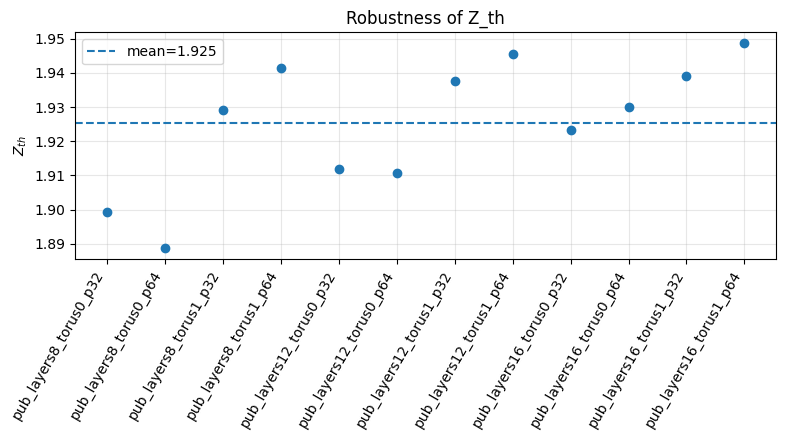

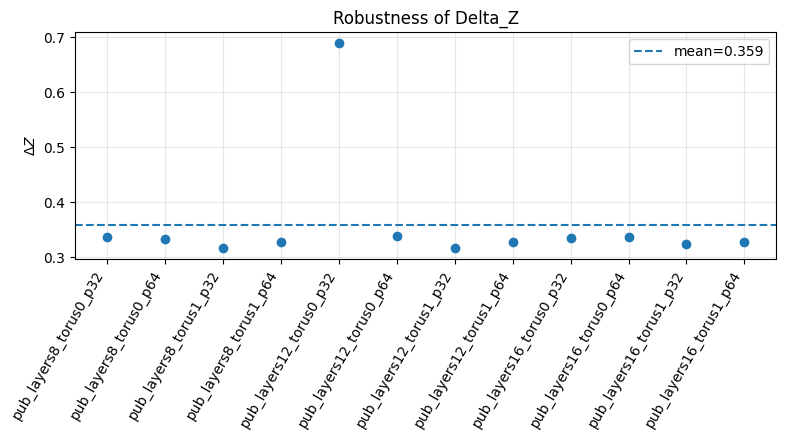

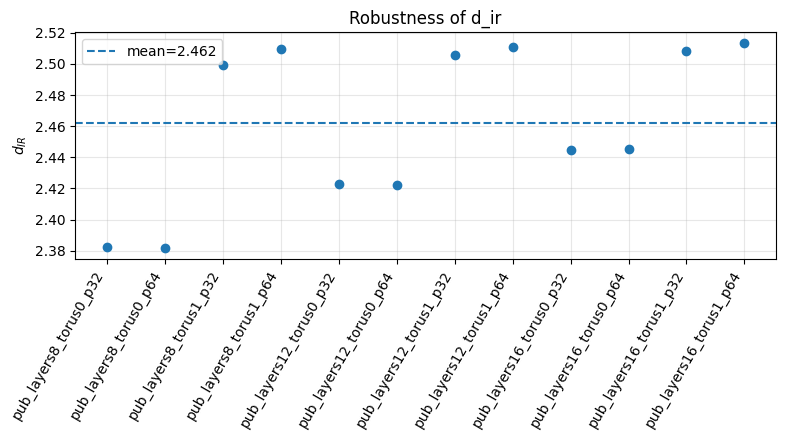

In [ ]:
# ============================================================
# 15. Figures consolidées
# ============================================================

if len(robustness_df):
    for col, label, fname in [("Z_th", "$Z_{th}$", "robustness_Z_th.png"), ("Delta_Z", "$\\Delta Z$", "robustness_Delta_Z.png"), ("d_ir", "$d_{IR}$", "robustness_d_ir.png")]:
        plt.figure(figsize=(8, 4.5))
        plt.errorbar(np.arange(len(robustness_df)), robustness_df[col], yerr=0, fmt="o")
        plt.axhline(float(robustness_df[col].mean()), linestyle="--", label=f"mean={float(robustness_df[col].mean()):.3f}")
        plt.xticks(np.arange(len(robustness_df)), robustness_df["tag"], rotation=60, ha="right")
        plt.ylabel(label); plt.title(f"Robustness of {col}")
        plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
        plt.savefig(os.path.join(CFG.out_dir, fname), dpi=160)
        plt.show()


In [ ]:
# ============================================================
# 16. Rapport reviewer-safe et export ZIP local + Drive
# Version robuste : reconstruction depuis Drive / disque
# ============================================================

import os, json, glob, zipfile, shutil
from pathlib import Path
from dataclasses import asdict, is_dataclass
from datetime import datetime

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 0. Vérifications minimales
# ------------------------------------------------------------

assert "CFG" in globals(), "CFG is missing. Relance la cellule de configuration ou le bootstrap."

LOCAL_OUTDIR = Path(getattr(CFG, "out_dir", "/content/cell4_test1K_kigami_outputs"))
DRIVE_OUTDIR = Path(getattr(CFG, "drive_out_dir", "/content/drive/MyDrive/DFGQ_Test1K/cell4_test1K_kigami_outputs"))

# Priorité au Drive si disponible
if DRIVE_OUTDIR.exists():
    SOURCE_DIR = DRIVE_OUTDIR
elif LOCAL_OUTDIR.exists():
    SOURCE_DIR = LOCAL_OUTDIR
else:
    raise RuntimeError("Aucun dossier de sortie local ou Drive trouvé.")

LOCAL_OUTDIR.mkdir(parents=True, exist_ok=True)
if getattr(CFG, "use_google_drive", False):
    DRIVE_OUTDIR.mkdir(parents=True, exist_ok=True)

print("SOURCE_DIR:", SOURCE_DIR)
print("LOCAL_OUTDIR:", LOCAL_OUTDIR)
print("DRIVE_OUTDIR:", DRIVE_OUTDIR if DRIVE_OUTDIR.exists() else "not available")


# ------------------------------------------------------------
# 1. Utilitaires autonomes
# ------------------------------------------------------------

def load_json_safe(path):
    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception as exc:
        return {"_load_error": str(exc), "_path": str(path)}

def save_json_safe(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def cfg_to_dict(cfg):
    if is_dataclass(cfg):
        return asdict(cfg)
    if hasattr(cfg, "__dict__"):
        return dict(cfg.__dict__)
    return {"repr": repr(cfg)}

def expected_publication_tags():
    return [
        f"pub_layers{layers}_torus{torus}_p{probes}"
        for layers in [8, 12, 16]
        for torus in [0, 1]
        for probes in [32, 64]
    ]

def expected_fast_tags():
    return [
        "base_repeat_p24",
        "torus_layers_true",
        "layers12_torus",
        "vertical_hi_1p5",
        "wider_Z_grid",
    ]

def mirror_file_to_drive(path):
    path = Path(path)
    if not getattr(CFG, "use_google_drive", False):
        return
    if not DRIVE_OUTDIR.exists():
        print("[drive-warning] Drive output dir not available:", DRIVE_OUTDIR)
        return
    try:
        shutil.copy2(path, DRIVE_OUTDIR / path.name)
    except Exception as exc:
        print(f"[drive-warning] could not mirror {path.name}: {exc}")


# ------------------------------------------------------------
# 2. Reconstruire les runs depuis les fichiers *_summary.json
# ------------------------------------------------------------

summary_files = sorted(SOURCE_DIR.glob("*_summary.json"))

variant_summaries = []
for p in summary_files:
    # Exclure d'éventuels fichiers de résumé globaux non-variantes si besoin
    if p.name.startswith("FINAL_"):
        continue
    data = load_json_safe(p)
    tag = data.get("tag", p.name.replace("_summary.json", ""))
    data["_summary_file"] = str(p)
    data["tag"] = tag
    variant_summaries.append(data)

summary_df = pd.DataFrame(variant_summaries) if variant_summaries else pd.DataFrame()

pub_tags = expected_publication_tags()
fast_tags = expected_fast_tags()

completed_pub = []
missing_pub = []

for tag in pub_tags:
    raw_complete = SOURCE_DIR / f"{tag}_raw.csv"
    agg_complete = SOURCE_DIR / f"{tag}_aggregated.csv"
    fit_complete = SOURCE_DIR / f"{tag}_fit_models.csv"
    summary_complete = SOURCE_DIR / f"{tag}_summary.json"

    if raw_complete.exists() and agg_complete.exists() and fit_complete.exists() and summary_complete.exists():
        completed_pub.append(tag)
    else:
        missing_pub.append(tag)

completed_fast = []
missing_fast = []

for tag in fast_tags:
    raw_complete = SOURCE_DIR / f"{tag}_raw.csv"
    agg_complete = SOURCE_DIR / f"{tag}_aggregated.csv"
    fit_complete = SOURCE_DIR / f"{tag}_fit_models.csv"
    summary_complete = SOURCE_DIR / f"{tag}_summary.json"

    if raw_complete.exists() and agg_complete.exists() and fit_complete.exists() and summary_complete.exists():
        completed_fast.append(tag)
    else:
        missing_fast.append(tag)


# ------------------------------------------------------------
# 3. Reconstruire une synthèse reviewer-safe depuis les summaries
# ------------------------------------------------------------

def numeric_col(df, col):
    if col not in df.columns:
        return pd.Series(dtype=float)
    return pd.to_numeric(df[col], errors="coerce")

if not summary_df.empty:
    summary_df["is_publication_variant"] = summary_df["tag"].isin(pub_tags)
    summary_df["is_fast_variant"] = summary_df["tag"].isin(fast_tags)

    for c in [
        "delta_aic_constant_vs_best_sigmoid",
        "delta_aic_linear_vs_best_sigmoid",
        "d_uv",
        "d_ir",
        "Z_th",
        "Delta_Z",
        "n_raw_rows",
    ]:
        if c in summary_df.columns:
            summary_df[c] = pd.to_numeric(summary_df[c], errors="coerce")

    pub_df = summary_df[summary_df["is_publication_variant"] == True].copy()
    fast_df = summary_df[summary_df["is_fast_variant"] == True].copy()

    def compact_stats(df):
        if df.empty:
            return {
                "n": 0,
                "fraction_sigmoid_vs_constant_delta_AIC_gt_10": None,
                "fraction_sigmoid_vs_linear_delta_AIC_gt_6": None,
                "Z_th_mean": None,
                "Z_th_std": None,
                "Delta_Z_mean": None,
                "Delta_Z_std": None,
                "d_uv_mean": None,
                "d_uv_std": None,
                "d_ir_mean": None,
                "d_ir_std": None,
            }

        return {
            "n": int(len(df)),
            "fraction_sigmoid_vs_constant_delta_AIC_gt_10": float(np.nanmean(df["delta_aic_constant_vs_best_sigmoid"] > 10)) if "delta_aic_constant_vs_best_sigmoid" in df else None,
            "fraction_sigmoid_vs_linear_delta_AIC_gt_6": float(np.nanmean(df["delta_aic_linear_vs_best_sigmoid"] > 6)) if "delta_aic_linear_vs_best_sigmoid" in df else None,
            "Z_th_mean": float(np.nanmean(df["Z_th"])) if "Z_th" in df else None,
            "Z_th_std": float(np.nanstd(df["Z_th"], ddof=1)) if "Z_th" in df and len(df) > 1 else 0.0,
            "Delta_Z_mean": float(np.nanmean(df["Delta_Z"])) if "Delta_Z" in df else None,
            "Delta_Z_std": float(np.nanstd(df["Delta_Z"], ddof=1)) if "Delta_Z" in df and len(df) > 1 else 0.0,
            "d_uv_mean": float(np.nanmean(df["d_uv"])) if "d_uv" in df else None,
            "d_uv_std": float(np.nanstd(df["d_uv"], ddof=1)) if "d_uv" in df and len(df) > 1 else 0.0,
            "d_ir_mean": float(np.nanmean(df["d_ir"])) if "d_ir" in df else None,
            "d_ir_std": float(np.nanstd(df["d_ir"], ddof=1)) if "d_ir" in df and len(df) > 1 else 0.0,
        }

    robustness_summary = {
        "all_summary_files_detected": int(len(summary_df)),
        "publication_completed_count": int(len(completed_pub)),
        "publication_expected_count": 12,
        "publication_missing_count": int(len(missing_pub)),
        "publication_completed_tags": completed_pub,
        "publication_missing_tags": missing_pub,
        "fast_completed_count": int(len(completed_fast)),
        "fast_expected_count": 5,
        "fast_missing_count": int(len(missing_fast)),
        "fast_completed_tags": completed_fast,
        "fast_missing_tags": missing_fast,
        "stats_all_detected": compact_stats(summary_df),
        "stats_publication_detected": compact_stats(pub_df),
        "stats_fast_detected": compact_stats(fast_df),
    }
else:
    robustness_summary = {
        "all_summary_files_detected": 0,
        "publication_completed_count": len(completed_pub),
        "publication_expected_count": 12,
        "publication_missing_count": len(missing_pub),
        "publication_completed_tags": completed_pub,
        "publication_missing_tags": missing_pub,
        "fast_completed_count": len(completed_fast),
        "fast_expected_count": 5,
        "fast_missing_count": len(missing_fast),
        "fast_completed_tags": completed_fast,
        "fast_missing_tags": missing_fast,
    }


# ------------------------------------------------------------
# 4. Autotests : reprendre existant si disponible, sinon reconstruire minimal
# ------------------------------------------------------------

autotest_candidates = [
    SOURCE_DIR / "AUTOTEST_STATUS.json",
    SOURCE_DIR / "TEST1K_AUTOTEST_STATUS.json",
]

AUTOTEST_STATUS_DISK = {}
for p in autotest_candidates:
    if p.exists():
        AUTOTEST_STATUS_DISK = load_json_safe(p)
        break

if "AUTOTEST_STATUS" in globals():
    autotests = AUTOTEST_STATUS
elif AUTOTEST_STATUS_DISK:
    autotests = AUTOTEST_STATUS_DISK
else:
    autotests = {
        "disk_reconstructed": True,
        "publication_completed_count": len(completed_pub),
        "publication_expected_count": 12,
        "publication_sweep_complete": len(completed_pub) == 12,
        "has_variant_summaries": len(variant_summaries) > 0,
    }


# ------------------------------------------------------------
# 5. Rapport principal
# ------------------------------------------------------------

report = {
    "title": "Test 1K — Kigami-weighted cell-4 spectral crossover",
    "generated_at": datetime.utcnow().isoformat() + "Z",
    "status": (
        "publication_sweep_complete"
        if len(completed_pub) == 12
        else "checkpointed_partial_publication_sweep"
    ),
    "configuration": cfg_to_dict(CFG),
    "autotests": autotests,
    "main_runs_from_memory_available": "runs" in globals(),
    "robustness_runs_from_memory_available": "robustness_runs" in globals(),
    "variant_summaries_detected": variant_summaries,
    "robustness_global_summary": robustness_summary,
    "drive_persistence": {
        "source_dir_used": str(SOURCE_DIR),
        "local_out_dir": str(LOCAL_OUTDIR),
        "drive_out_dir": str(DRIVE_OUTDIR),
        "resume_from_drive": getattr(CFG, "resume_from_drive", None),
        "checkpoint_after_each_Z": getattr(CFG, "checkpoint_after_each_Z", None),
        "force_rerun_completed": getattr(CFG, "force_rerun_completed", None),
    },
    "interpretation": {
        "safe_claim": (
            "The test upgrades the original cell-4 spectral crossover into a "
            "Dirichlet-energy-based numerical protocol by replacing vertical "
            "phenomenological weights with local resistance-conductance proxies."
        ),
        "not_claimed": (
            "This is not a proof of Einstein gravity, electromagnetic coupling, "
            "or a closed analytical Kigami derivation."
        ),
        "hill_note": (
            "The Hill/saturating-power competitor is included because a bounded "
            "power law in x=exp(Z) is equivalent to a logistic crossover in Z."
        ),
        "checkpoint_note": (
            "This report is reconstructed from disk/Drive exports and does not "
            "require in-memory variables such as runs or robustness_runs."
        ),
    },
}


# ------------------------------------------------------------
# 6. Sauvegardes CSV / JSON
# ------------------------------------------------------------

report_path = SOURCE_DIR / "TEST1K_REPORT.json"
manifest_path = SOURCE_DIR / "ZIP_MANIFEST.json"
run_index_json_path = SOURCE_DIR / "RUN_INDEX.json"
run_index_csv_path = SOURCE_DIR / "RUN_INDEX.csv"
summary_rebuilt_csv_path = SOURCE_DIR / "REBUILT_VARIANT_SUMMARIES.csv"
robustness_rebuilt_path = SOURCE_DIR / "REBUILT_ROBUSTNESS_SUMMARY.json"

save_json_safe(report, report_path)
save_json_safe(robustness_summary, robustness_rebuilt_path)

if not summary_df.empty:
    summary_df.to_csv(summary_rebuilt_csv_path, index=False)

run_index = {
    "generated_at": datetime.utcnow().isoformat() + "Z",
    "source_dir": str(SOURCE_DIR),
    "publication_completed": completed_pub,
    "publication_missing": missing_pub,
    "fast_completed": completed_fast,
    "fast_missing": missing_fast,
    "files": sorted([p.name for p in SOURCE_DIR.iterdir() if p.is_file()]),
}

save_json_safe(run_index, run_index_json_path)

run_index_rows = []
for p in sorted(SOURCE_DIR.iterdir()):
    if p.is_file():
        run_index_rows.append({
            "filename": p.name,
            "size_bytes": p.stat().st_size,
            "path": str(p),
        })

pd.DataFrame(run_index_rows).to_csv(run_index_csv_path, index=False)

manifest = {
    "generated_at": datetime.utcnow().isoformat() + "Z",
    "source_dir": str(SOURCE_DIR),
    "n_files": len(run_index_rows),
    "files": run_index_rows,
}
save_json_safe(manifest, manifest_path)


# ------------------------------------------------------------
# 7. Miroir local <-> Drive
# ------------------------------------------------------------

# Si source = Drive, copier les fichiers clés en local aussi
for p in [
    report_path,
    manifest_path,
    run_index_json_path,
    run_index_csv_path,
    robustness_rebuilt_path,
    summary_rebuilt_csv_path,
]:
    if p.exists():
        try:
            if SOURCE_DIR != LOCAL_OUTDIR:
                shutil.copy2(p, LOCAL_OUTDIR / p.name)
        except Exception as exc:
            print(f"[local-warning] could not copy {p.name}: {exc}")

        try:
            if getattr(CFG, "use_google_drive", False) and SOURCE_DIR != DRIVE_OUTDIR and DRIVE_OUTDIR.exists():
                shutil.copy2(p, DRIVE_OUTDIR / p.name)
        except Exception as exc:
            print(f"[drive-warning] could not copy {p.name}: {exc}")


# ------------------------------------------------------------
# 8. ZIP global checkpoint
# ------------------------------------------------------------

zip_path = SOURCE_DIR / "cell4_test1K_kigami_outputs_checkpoint.zip"

include_suffixes = {".csv", ".json", ".png", ".txt"}
exclude_names = {zip_path.name}

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    # Fichiers racine
    for p in sorted(SOURCE_DIR.iterdir()):
        if p.is_file() and p.name not in exclude_names and p.suffix.lower() in include_suffixes:
            zf.write(p, arcname=p.name)

    # Dossier FINAL_REFIT_ANALYSIS si présent
    analysis_dir = SOURCE_DIR / "FINAL_REFIT_ANALYSIS"
    if analysis_dir.exists():
        for p in sorted(analysis_dir.rglob("*")):
            if p.is_file():
                arcname = "FINAL_REFIT_ANALYSIS/" + str(p.relative_to(analysis_dir))
                zf.write(p, arcname=arcname)

print("ZIP written:", zip_path)
print("ZIP size:", zip_path.stat().st_size, "bytes")

# Copier le ZIP vers l’autre emplacement si nécessaire
if SOURCE_DIR == DRIVE_OUTDIR:
    try:
        shutil.copy2(zip_path, LOCAL_OUTDIR / zip_path.name)
        print("ZIP copied locally:", LOCAL_OUTDIR / zip_path.name)
    except Exception as exc:
        print("[local-warning] ZIP copy failed:", exc)
elif getattr(CFG, "use_google_drive", False) and DRIVE_OUTDIR.exists():
    try:
        shutil.copy2(zip_path, DRIVE_OUTDIR / zip_path.name)
        print("ZIP copied to Drive:", DRIVE_OUTDIR / zip_path.name)
    except Exception as exc:
        print("[drive-warning] ZIP copy failed:", exc)


# ------------------------------------------------------------
# 9. Affichage final
# ------------------------------------------------------------

print("\n================ TEST1K REPORT STATUS ================")
print("Status:", report["status"])
print("Publication completed:", len(completed_pub), "/ 12")
print("Publication missing:", missing_pub)
print("Fast completed:", len(completed_fast), "/ 5")
print("Fast missing:", missing_fast)

print("\nFiles written:")
for p in [
    report_path,
    robustness_rebuilt_path,
    manifest_path,
    run_index_json_path,
    run_index_csv_path,
    zip_path,
]:
    print("-", p.name, p.exists(), p.stat().st_size if p.exists() else None)

if not summary_df.empty:
    print("\nDetected summaries:")
    display(summary_df[[
        c for c in [
            "tag",
            "n_realizations",
            "conductance_rule",
            "best_aic_model",
            "best_sigmoid_like_model",
            "delta_aic_constant_vs_best_sigmoid",
            "delta_aic_linear_vs_best_sigmoid",
            "d_uv",
            "d_ir",
            "Z_th",
            "Delta_Z",
            "is_complete",
            "is_publication_variant",
            "is_fast_variant",
        ]
        if c in summary_df.columns
    ]])
else:
    print("No variant summaries detected.")

SOURCE_DIR: /content/drive/MyDrive/DFGQ_Test1K/cell4_test1K_kigami_outputs
LOCAL_OUTDIR: /content/cell4_test1K_kigami_outputs
DRIVE_OUTDIR: /content/drive/MyDrive/DFGQ_Test1K/cell4_test1K_kigami_outputs


/tmp/ipykernel_16271/3206152063.py:270: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "generated_at": datetime.utcnow().isoformat() + "Z",
/tmp/ipykernel_16271/3206152063.py:330: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "generated_at": datetime.utcnow().isoformat() + "Z",
/tmp/ipykernel_16271/3206152063.py:353: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "generated_at": datetime.utcnow().isoformat() + "Z",


ZIP written: /content/drive/MyDrive/DFGQ_Test1K/cell4_test1K_kigami_outputs/cell4_test1K_kigami_outputs_checkpoint.zip
ZIP size: 1478011 bytes
ZIP copied locally: /content/cell4_test1K_kigami_outputs/cell4_test1K_kigami_outputs_checkpoint.zip

================ TEST1K REPORT STATUS ================
Status: publication_sweep_complete
Publication completed: 12 / 12
Publication missing: []
Fast completed: 4 / 5
Fast missing: ['base_repeat_p24']

Files written:
- TEST1K_REPORT.json True 52735
- REBUILT_ROBUSTNESS_SUMMARY.json True 2248
- ZIP_MANIFEST.json True 27120
- RUN_INDEX.json True 6053
- RUN_INDEX.csv True 17747
- cell4_test1K_kigami_outputs_checkpoint.zip True 1478011

Detected summaries:


,tag,n_realizations,conductance_rule,best_aic_model,best_sigmoid_like_model,delta_aic_constant_vs_best_sigmoid,delta_aic_linear_vs_best_sigmoid,d_uv,d_ir,Z_th,Delta_Z,is_complete,is_publication_variant,is_fast_variant
0,base_kigami_p24,50.0,kigami_local,logistic,logistic,112.758193,79.670820,1.813519,2.380238,1.887266,0.331288,True,False,False
1,comparison_phenomenological,50.0,phenomenological,tanh,tanh,126.293214,92.369213,1.812541,2.407040,1.892243,0.676173,True,False,False
2,layers12_torus,50.0,kigami_local,logistic,logistic,124.299924,91.336456,1.813293,2.504648,1.928099,0.321805,True,False,True
3,main_kigami_local,50.0,kigami_local,logistic,logistic,116.640003,83.015144,1.812694,2.382872,1.887818,0.339138,True,False,False
4,negative_plane2d,50.0,phenomenological,constant,hill_saturating_power,-3.873694,-2.137517,1.801792,1.797650,-0.216323,0.050000,True,False,False
5,pub_layers12_torus0_p32,50.0,kigami_local,tanh,tanh,155.689222,115.411452,1.813080,2.422739,1.911728,0.690401,True,True,False
6,pub_layers12_torus0_p64,50.0,kigami_local,logistic,logistic,152.339770,112.479836,1.814516,2.422232,1.910621,0.339314,True,True,False
7,pub_layers12_torus1_p32,50.0,kigami_local,logistic,logistic,152.859833,114.002799,1.815581,2.505769,1.937635,0.317177,True,True,False
8,pub_layers12_torus1_p64,50.0,kigami_local,logistic,logistic,159.701860,120.009438,1.815108,2.510920,1.945467,0.328431,True,True,False
9,pub_layers16_torus0_p32,50.0,kigami_local,hill_saturating_power,hill_saturating_power,155.625024,115.769085,1.814519,2.444782,1.923359,0.336101,True,True,False


In [ ]:
# ============================================================
# CELLULE FINALE — Test1K final refit / robust estimators / Drive export
# ============================================================
# Objectif :
# - Ne PAS recalculer les graphes.
# - Lire les résultats déjà sauvegardés sur Drive.
# - Refaire les fits avec :
#     1) ds_mean
#     2) ds_median
#     3) ds_trimmed_mean
# - Comparer logistic / tanh / Hill saturating power / pure power / linear / constant.
# - Exporter les tableaux reviewer-safe vers Drive.
# ============================================================

import os, json, glob, math, zipfile, shutil, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ------------------------------------------------------------
# 0. Localisation des dossiers
# ------------------------------------------------------------

DEFAULT_LOCAL_OUTDIR = "/content/cell4_test1K_kigami_outputs"
DEFAULT_DRIVE_OUTDIR = "/content/drive/MyDrive/DFGQ_Test1K/cell4_test1K_kigami_outputs"

try:
    OUTDIR
except NameError:
    OUTDIR = DEFAULT_LOCAL_OUTDIR

try:
    DRIVE_OUTDIR
except NameError:
    DRIVE_OUTDIR = DEFAULT_DRIVE_OUTDIR

# Priorité au Drive si disponible.
if os.path.exists(DRIVE_OUTDIR):
    BASE_OUTDIR = DRIVE_OUTDIR
elif os.path.exists(OUTDIR):
    BASE_OUTDIR = OUTDIR
else:
    raise RuntimeError(
        "Aucun dossier de sortie trouvé. Vérifie le montage Drive ou le chemin OUTDIR."
    )

BASE_OUTDIR = Path(BASE_OUTDIR)
ANALYSIS_DIR = BASE_OUTDIR / "FINAL_REFIT_ANALYSIS"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

print("Base output dir:", BASE_OUTDIR)
print("Analysis output dir:", ANALYSIS_DIR)


# ------------------------------------------------------------
# 1. Fonctions de modèle
# ------------------------------------------------------------

def constant_profile(Z, c):
    Z = np.asarray(Z, dtype=float)
    return np.zeros_like(Z) + c

def linear_profile(Z, a, b):
    Z = np.asarray(Z, dtype=float)
    return a + b * Z

def tanh_profile(Z, d_uv, d_ir, Z_th, Delta_Z):
    Z = np.asarray(Z, dtype=float)
    Delta_Z = np.maximum(np.abs(Delta_Z), 1e-9)
    return d_uv + 0.5 * (d_ir - d_uv) * (1.0 + np.tanh((Z - Z_th) / Delta_Z))

def logistic_profile_harmonized(Z, d_uv, d_ir, Z_th, Delta_Z):
    """
    Version harmonisée avec tanh :
        0.5*(1+tanh((Z-Zth)/Delta))
      = 1/(1+exp(-2*(Z-Zth)/Delta))
    Ainsi Delta_Z est comparable à la largeur tanh.
    """
    Z = np.asarray(Z, dtype=float)
    Delta_Z = np.maximum(np.abs(Delta_Z), 1e-9)
    x = np.clip(-2.0 * (Z - Z_th) / Delta_Z, -700, 700)
    return d_uv + (d_ir - d_uv) / (1.0 + np.exp(x))

def hill_saturating_power_profile(Z, d_uv, d_ir, Z_th, p):
    """
    Puissance saturante en variable physique x=e^Z.
    En variable Z :
        x^p/(x^p+x_c^p) = 1/(1+exp[-p(Z-Zc)])
    Pour comparer à tanh/logistic harmonisée :
        p ≈ 2/Delta_Z
    """
    Z = np.asarray(Z, dtype=float)
    p = np.maximum(np.abs(p), 1e-9)
    x = np.clip(-p * (Z - Z_th), -700, 700)
    return d_uv + (d_ir - d_uv) / (1.0 + np.exp(x))

def pure_power_shifted_profile(Z, a, b, p):
    """
    Contrôle mathématique non borné :
        a + b * (Z-Zmin+eps)^p
    Le shift est défini dans la fonction de fit.
    """
    raise NotImplementedError("Uses closure with Zmin.")


# ------------------------------------------------------------
# 2. Outils fit / AIC / BIC
# ------------------------------------------------------------

def aic_bic_from_rss(rss, n, k):
    rss = float(max(rss, 1e-300))
    n = int(n)
    k = int(k)
    aic = n * np.log(rss / n) + 2 * k
    bic = n * np.log(rss / n) + k * np.log(n)
    return float(aic), float(bic)

def safe_curve_fit(func, Z, y, p0, bounds=(-np.inf, np.inf), maxfev=200000):
    try:
        p, _ = curve_fit(
            func,
            np.asarray(Z, dtype=float),
            np.asarray(y, dtype=float),
            p0=p0,
            bounds=bounds,
            maxfev=maxfev,
        )
        pred = func(np.asarray(Z, dtype=float), *p)
        rss = float(np.sum((np.asarray(y, dtype=float) - pred) ** 2))
        return p, pred, rss, None
    except Exception as e:
        return None, None, np.inf, str(e)

def initial_transition_guess(Z, y):
    Z = np.asarray(Z, dtype=float)
    y = np.asarray(y, dtype=float)
    order = np.argsort(Z)
    Zs = Z[order]
    ys = y[order]

    d_uv0 = float(np.nanmedian(ys[:max(2, min(4, len(ys)//4))]))
    d_ir0 = float(np.nanmedian(ys[-max(2, min(4, len(ys)//4)):]))
    if not np.isfinite(d_uv0):
        d_uv0 = float(np.nanmin(ys))
    if not np.isfinite(d_ir0):
        d_ir0 = float(np.nanmax(ys))

    dy = np.gradient(ys, Zs)
    if np.all(np.isfinite(dy)):
        Z_th0 = float(Zs[np.nanargmax(np.abs(dy))])
    else:
        Z_th0 = float(np.nanmedian(Zs))

    Delta0 = max(0.25, 0.15 * (float(np.nanmax(Zs)) - float(np.nanmin(Zs))))
    return d_uv0, d_ir0, Z_th0, Delta0

def fit_models_for_profile(df, y_col):
    d = df[["Z", y_col]].dropna().copy()
    d = d[np.isfinite(d["Z"]) & np.isfinite(d[y_col])]
    d = d.sort_values("Z")

    Z = d["Z"].to_numpy(dtype=float)
    y = d[y_col].to_numpy(dtype=float)

    if len(Z) < 6:
        return pd.DataFrame(), {}

    n = len(Z)
    zmin, zmax = float(np.min(Z)), float(np.max(Z))
    ymin, ymax = float(np.min(y)), float(np.max(y))
    yrange = max(ymax - ymin, 1e-6)

    d_uv0, d_ir0, Z_th0, Delta0 = initial_transition_guess(Z, y)

    rows = []
    preds = {}

    # Constant
    p = np.array([float(np.mean(y))])
    pred = constant_profile(Z, *p)
    rss = float(np.sum((y - pred) ** 2))
    aic, bic = aic_bic_from_rss(rss, n, 1)
    rows.append({
        "model": "constant", "rss": rss, "aic": aic, "bic": bic, "k": 1,
        "params": p.tolist(), "error": None,
        "d_uv": p[0], "d_ir": p[0], "Z_th": np.nan, "Delta_Z": np.nan,
        "hill_p": np.nan
    })
    preds["constant"] = pred

    # Linear
    try:
        p = np.polyfit(Z, y, deg=1)
        # np.polyfit returns slope, intercept
        pp = np.array([p[1], p[0]])
        pred = linear_profile(Z, *pp)
        rss = float(np.sum((y - pred) ** 2))
        aic, bic = aic_bic_from_rss(rss, n, 2)
        err = None
    except Exception as e:
        pp = [np.nan, np.nan]; pred = np.full_like(y, np.nan); rss = np.inf
        aic, bic, err = np.inf, np.inf, str(e)

    rows.append({
        "model": "linear", "rss": rss, "aic": aic, "bic": bic, "k": 2,
        "params": list(pp), "error": err,
        "d_uv": np.nan, "d_ir": np.nan, "Z_th": np.nan, "Delta_Z": np.nan,
        "hill_p": np.nan
    })
    preds["linear"] = pred

    # Tanh
    bounds_sigmoid = (
        [ymin - yrange, ymin - yrange, zmin - 2.0, 1e-4],
        [ymax + yrange, ymax + yrange, zmax + 2.0, 20.0],
    )
    p0 = [d_uv0, d_ir0, Z_th0, Delta0]
    p, pred, rss, err = safe_curve_fit(tanh_profile, Z, y, p0, bounds_sigmoid)
    k = 4
    aic, bic = aic_bic_from_rss(rss, n, k)
    rows.append({
        "model": "tanh", "rss": rss, "aic": aic, "bic": bic, "k": k,
        "params": None if p is None else p.tolist(), "error": err,
        "d_uv": np.nan if p is None else p[0],
        "d_ir": np.nan if p is None else p[1],
        "Z_th": np.nan if p is None else p[2],
        "Delta_Z": np.nan if p is None else abs(p[3]),
        "hill_p": np.nan
    })
    preds["tanh"] = pred

    # Logistic harmonisée
    p, pred, rss, err = safe_curve_fit(logistic_profile_harmonized, Z, y, p0, bounds_sigmoid)
    aic, bic = aic_bic_from_rss(rss, n, k)
    rows.append({
        "model": "logistic", "rss": rss, "aic": aic, "bic": bic, "k": k,
        "params": None if p is None else p.tolist(), "error": err,
        "d_uv": np.nan if p is None else p[0],
        "d_ir": np.nan if p is None else p[1],
        "Z_th": np.nan if p is None else p[2],
        "Delta_Z": np.nan if p is None else abs(p[3]),
        "hill_p": np.nan
    })
    preds["logistic"] = pred

    # Hill saturating power
    p0_hill = [d_uv0, d_ir0, Z_th0, max(2.0 / Delta0, 0.1)]
    bounds_hill = (
        [ymin - yrange, ymin - yrange, zmin - 2.0, 1e-4],
        [ymax + yrange, ymax + yrange, zmax + 2.0, 100.0],
    )
    p, pred, rss, err = safe_curve_fit(hill_saturating_power_profile, Z, y, p0_hill, bounds_hill)
    aic, bic = aic_bic_from_rss(rss, n, k)
    rows.append({
        "model": "hill_saturating_power", "rss": rss, "aic": aic, "bic": bic, "k": k,
        "params": None if p is None else p.tolist(), "error": err,
        "d_uv": np.nan if p is None else p[0],
        "d_ir": np.nan if p is None else p[1],
        "Z_th": np.nan if p is None else p[2],
        "Delta_Z": np.nan if p is None else 2.0 / abs(p[3]),
        "hill_p": np.nan if p is None else abs(p[3])
    })
    preds["hill_saturating_power"] = pred

    # Pure power shifted : non borné, contrôle mathématique
    Zshift = Z - zmin + 1e-6
    def pure_power_shifted_local(Zin, a, b, p):
        Zin = np.asarray(Zin, dtype=float)
        X = Zin - zmin + 1e-6
        X = np.maximum(X, 1e-12)
        return a + b * (X ** p)

    p0_pow = [d_uv0, (d_ir0 - d_uv0) / max((zmax-zmin), 1e-6), 1.0]
    bounds_pow = (
        [ymin - yrange, -10.0 * yrange, 0.0],
        [ymax + yrange,  10.0 * yrange, 8.0],
    )
    p, pred, rss, err = safe_curve_fit(pure_power_shifted_local, Z, y, p0_pow, bounds_pow)
    k_pow = 3
    aic, bic = aic_bic_from_rss(rss, n, k_pow)
    rows.append({
        "model": "pure_power_shifted", "rss": rss, "aic": aic, "bic": bic, "k": k_pow,
        "params": None if p is None else p.tolist(), "error": err,
        "d_uv": np.nan, "d_ir": np.nan, "Z_th": np.nan, "Delta_Z": np.nan,
        "hill_p": np.nan
    })
    preds["pure_power_shifted"] = pred

    fit_df = pd.DataFrame(rows)
    fit_df = fit_df.sort_values(["aic", "bic"]).reset_index(drop=True)
    fit_df["delta_aic"] = fit_df["aic"] - fit_df["aic"].min()
    fit_df["delta_bic"] = fit_df["bic"] - fit_df["bic"].min()

    return fit_df, {"Z": Z, "y": y, "preds": preds}


# ------------------------------------------------------------
# 3. Calcul ds_trimmed_mean à partir des raw.csv
# ------------------------------------------------------------

def trimmed_mean(values, proportion_to_cut=0.20):
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    x = np.sort(x)
    k = int(math.floor(proportion_to_cut * len(x)))
    if 2 * k >= len(x):
        return float(np.mean(x))
    return float(np.mean(x[k:len(x)-k]))

def add_trimmed_mean_from_raw(tag, agg):
    raw_path = BASE_OUTDIR / f"{tag}_raw.csv"
    partial_path = BASE_OUTDIR / f"{tag}_PARTIAL_raw.csv"

    if raw_path.exists():
        raw = pd.read_csv(raw_path)
    elif partial_path.exists():
        raw = pd.read_csv(partial_path)
    else:
        agg["ds_trimmed_mean"] = np.nan
        return agg

    value_candidates = [
        "ds_eff_mean", "ds_mean", "ds_eff_median", "ds_median"
    ]
    value_col = None
    for c in value_candidates:
        if c in raw.columns:
            value_col = c
            break

    if value_col is None or "Z" not in raw.columns:
        agg["ds_trimmed_mean"] = np.nan
        return agg

    trim = (
        raw.groupby("Z")[value_col]
        .apply(lambda s: trimmed_mean(s, proportion_to_cut=0.20))
        .reset_index()
        .rename(columns={value_col: "ds_trimmed_mean"})
    )

    out = agg.merge(trim, on="Z", how="left")
    return out


# ------------------------------------------------------------
# 4. Charger toutes les variantes complètes disponibles
# ------------------------------------------------------------

aggregated_paths = sorted(BASE_OUTDIR.glob("*_aggregated.csv"))

if not aggregated_paths:
    raise RuntimeError(f"Aucun fichier *_aggregated.csv trouvé dans {BASE_OUTDIR}")

expected_pub_tags = [
    f"pub_layers{layers}_torus{torus}_p{probes}"
    for layers in [8, 12, 16]
    for torus in [0, 1]
    for probes in [32, 64]
]

completed_tags = []
variant_frames = {}

for agg_path in aggregated_paths:
    tag = agg_path.name.replace("_aggregated.csv", "")
    summary_path = BASE_OUTDIR / f"{tag}_summary.json"

    is_complete = True
    summary = {}

    if summary_path.exists():
        try:
            with open(summary_path, "r", encoding="utf-8") as f:
                summary = json.load(f)
            is_complete = bool(summary.get("is_complete", True))
        except Exception:
            is_complete = True

    if not is_complete:
        continue

    agg = pd.read_csv(agg_path)
    if "Z" not in agg.columns:
        continue

    agg = add_trimmed_mean_from_raw(tag, agg)
    agg["tag"] = tag

    variant_frames[tag] = agg
    completed_tags.append(tag)

completed_pub_tags = [t for t in completed_tags if t in expected_pub_tags]
missing_pub_tags = [t for t in expected_pub_tags if t not in completed_pub_tags]

print("Completed variants found:", len(completed_tags))
print("Completed publication variants:", len(completed_pub_tags), "/ 12")
print("Missing publication variants:", missing_pub_tags)


# ------------------------------------------------------------
# 5. Refits par estimateur
# ------------------------------------------------------------

Y_COLS = ["ds_mean", "ds_median", "ds_trimmed_mean"]

all_fit_rows = []
best_rows = []

for tag, df in variant_frames.items():
    for y_col in Y_COLS:
        if y_col not in df.columns:
            continue
        if df[y_col].notna().sum() < 6:
            continue

        fit_df, pred_pack = fit_models_for_profile(df, y_col)
        if fit_df.empty:
            continue

        fit_df["tag"] = tag
        fit_df["y_col"] = y_col

        # Identifier meilleurs modèles
        sigmoid_like = fit_df[
            fit_df["model"].isin(["tanh", "logistic", "hill_saturating_power"])
        ].sort_values("aic")

        if len(sigmoid_like) > 0:
            best_sig = sigmoid_like.iloc[0].to_dict()
        else:
            best_sig = {}

        constant_aic = fit_df.loc[fit_df["model"] == "constant", "aic"]
        linear_aic = fit_df.loc[fit_df["model"] == "linear", "aic"]
        pure_power_aic = fit_df.loc[fit_df["model"] == "pure_power_shifted", "aic"]

        const_delta = (
            float(constant_aic.iloc[0] - best_sig.get("aic", np.nan))
            if len(constant_aic) else np.nan
        )
        lin_delta = (
            float(linear_aic.iloc[0] - best_sig.get("aic", np.nan))
            if len(linear_aic) else np.nan
        )
        pure_power_delta = (
            float(pure_power_aic.iloc[0] - best_sig.get("aic", np.nan))
            if len(pure_power_aic) else np.nan
        )

        # Biais mean/median UV si disponible
        uv_bias = np.nan
        if "ds_mean" in df.columns and "ds_median" in df.columns:
            dd = df.sort_values("Z").head(3)
            uv_bias = float(np.nanmean(dd["ds_mean"]) - np.nanmean(dd["ds_median"]))

        best_rows.append({
            "tag": tag,
            "is_publication_variant": tag in expected_pub_tags,
            "y_col": y_col,
            "best_aic_model": fit_df.iloc[0]["model"],
            "best_sigmoid_like_model": best_sig.get("model", None),
            "delta_aic_constant_vs_best_sigmoid": const_delta,
            "delta_aic_linear_vs_best_sigmoid": lin_delta,
            "delta_aic_pure_power_vs_best_sigmoid": pure_power_delta,
            "d_uv": best_sig.get("d_uv", np.nan),
            "d_ir": best_sig.get("d_ir", np.nan),
            "Z_th": best_sig.get("Z_th", np.nan),
            "Delta_Z": best_sig.get("Delta_Z", np.nan),
            "hill_p": best_sig.get("hill_p", np.nan),
            "uv_mean_minus_median_first3": uv_bias,
            "n_Z": int(df[y_col].notna().sum()),
        })

        all_fit_rows.append(fit_df)

        # Figure par tag uniquement pour ds_median et publication/main, pour ne pas saturer.
        if y_col == "ds_median" and (tag in expected_pub_tags or tag in ["main_kigami_local", "comparison_phenomenological", "negative_plane2d"]):
            Z = pred_pack["Z"]
            y = pred_pack["y"]
            preds = pred_pack["preds"]

            fig = plt.figure(figsize=(7, 4.5))
            plt.plot(Z, y, marker="o", linestyle="", label=f"{tag} / {y_col}")

            for model_name in ["constant", "linear", "tanh", "logistic", "hill_saturating_power", "pure_power_shifted"]:
                pred = preds.get(model_name)
                if pred is not None and np.all(np.isfinite(pred)):
                    plt.plot(Z, pred, linewidth=1.5, label=model_name)

            plt.xlabel("Z")
            plt.ylabel(y_col)
            plt.title(f"Final refit — {tag} — {y_col}")
            plt.legend(fontsize=8)
            plt.tight_layout()
            fig_path = ANALYSIS_DIR / f"FINAL_refit_{tag}_{y_col}.png"
            plt.savefig(fig_path, dpi=160)
            plt.close(fig)

if all_fit_rows:
    detailed_fits = pd.concat(all_fit_rows, ignore_index=True)
else:
    detailed_fits = pd.DataFrame()

best_df = pd.DataFrame(best_rows)

detailed_fits_path = ANALYSIS_DIR / "FINAL_refit_detailed_models_all_estimators.csv"
best_path = ANALYSIS_DIR / "FINAL_refit_best_sigmoid_by_estimator.csv"

detailed_fits.to_csv(detailed_fits_path, index=False)
best_df.to_csv(best_path, index=False)

print("Detailed fits exported:", detailed_fits_path)
print("Best summary exported:", best_path)


# ------------------------------------------------------------
# 6. Synthèses reviewer-safe
# ------------------------------------------------------------

summary_rows = []

for y_col in Y_COLS:
    sub = best_df[best_df["y_col"] == y_col].copy()
    pub = sub[sub["is_publication_variant"] == True].copy()

    for label, ss in [("all_completed", sub), ("publication_completed", pub)]:
        if len(ss) == 0:
            continue

        summary_rows.append({
            "group": label,
            "y_col": y_col,
            "n_variants": int(len(ss)),
            "n_publication_completed": int(len(pub)) if label == "publication_completed" else int(len(pub)),
            "fraction_sigmoid_vs_constant_delta_AIC_gt_10": float(np.mean(ss["delta_aic_constant_vs_best_sigmoid"] > 10)),
            "fraction_sigmoid_vs_linear_delta_AIC_gt_6": float(np.mean(ss["delta_aic_linear_vs_best_sigmoid"] > 6)),
            "fraction_sigmoid_vs_pure_power_delta_AIC_gt_6": float(np.mean(ss["delta_aic_pure_power_vs_best_sigmoid"] > 6)),
            "Z_th_mean": float(np.nanmean(ss["Z_th"])),
            "Z_th_std": float(np.nanstd(ss["Z_th"], ddof=1)) if len(ss) > 1 else 0.0,
            "Delta_Z_mean": float(np.nanmean(ss["Delta_Z"])),
            "Delta_Z_std": float(np.nanstd(ss["Delta_Z"], ddof=1)) if len(ss) > 1 else 0.0,
            "d_uv_mean": float(np.nanmean(ss["d_uv"])),
            "d_uv_std": float(np.nanstd(ss["d_uv"], ddof=1)) if len(ss) > 1 else 0.0,
            "d_ir_mean": float(np.nanmean(ss["d_ir"])),
            "d_ir_std": float(np.nanstd(ss["d_ir"], ddof=1)) if len(ss) > 1 else 0.0,
            "uv_mean_minus_median_first3_mean": float(np.nanmean(ss["uv_mean_minus_median_first3"])),
        })

summary_df = pd.DataFrame(summary_rows)
summary_path = ANALYSIS_DIR / "FINAL_refit_reviewer_safe_summary.csv"
summary_df.to_csv(summary_path, index=False)

status = {
    "base_outdir": str(BASE_OUTDIR),
    "analysis_dir": str(ANALYSIS_DIR),
    "n_completed_variants_total": int(len(completed_tags)),
    "completed_tags": completed_tags,
    "expected_publication_tags": expected_pub_tags,
    "completed_publication_tags": completed_pub_tags,
    "missing_publication_tags": missing_pub_tags,
    "n_completed_publication_variants": int(len(completed_pub_tags)),
    "n_missing_publication_variants": int(len(missing_pub_tags)),
    "recommended_primary_estimator": "ds_median",
    "secondary_estimator": "ds_trimmed_mean",
    "sensitivity_estimator": "ds_mean",
    "interpretation": (
        "Use ds_median as the primary reviewer-safe estimator because ds_mean "
        "can be biased downward in the UV window by low outliers. Keep ds_mean "
        "as a sensitivity control and ds_trimmed_mean as a robust intermediate estimator."
    ),
}

status_path = ANALYSIS_DIR / "FINAL_refit_status.json"
with open(status_path, "w", encoding="utf-8") as f:
    json.dump(status, f, indent=2)

print("Reviewer-safe summary exported:", summary_path)
print("Status exported:", status_path)


# ------------------------------------------------------------
# 7. Figures de synthèse publication, estimateur ds_median
# ------------------------------------------------------------

plot_df = best_df[
    (best_df["is_publication_variant"] == True) &
    (best_df["y_col"] == "ds_median")
].copy()

if len(plot_df) > 0:
    plot_df = plot_df.sort_values("tag")

    for metric in ["d_uv", "d_ir", "Z_th", "Delta_Z"]:
        fig = plt.figure(figsize=(9, 4.8))
        plt.plot(np.arange(len(plot_df)), plot_df[metric].to_numpy(), marker="o", linestyle="")
        plt.xticks(np.arange(len(plot_df)), plot_df["tag"].tolist(), rotation=70, ha="right")
        plt.ylabel(metric)
        plt.title(f"Publication variants — {metric} — ds_median")
        plt.tight_layout()
        fig_path = ANALYSIS_DIR / f"FINAL_publication_{metric}_ds_median.png"
        plt.savefig(fig_path, dpi=170)
        plt.close(fig)

    print("Publication summary figures written.")


# ------------------------------------------------------------
# 8. Export ZIP de l’analyse finale
# ------------------------------------------------------------

ZIP_ANALYSIS_PATH = BASE_OUTDIR / "cell4_test1K_FINAL_REFIT_ANALYSIS.zip"

with zipfile.ZipFile(ZIP_ANALYSIS_PATH, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for p in sorted(ANALYSIS_DIR.rglob("*")):
        if p.is_file():
            zf.write(p, arcname=str(p.relative_to(ANALYSIS_DIR)))

manifest = []
with zipfile.ZipFile(ZIP_ANALYSIS_PATH, "r") as zf:
    for info in zf.infolist():
        manifest.append({
            "filename": info.filename,
            "file_size": info.file_size,
            "compress_size": info.compress_size,
        })

manifest_path = ANALYSIS_DIR / "FINAL_refit_zip_manifest.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Final analysis ZIP:", ZIP_ANALYSIS_PATH)
print("ZIP size:", os.path.getsize(ZIP_ANALYSIS_PATH), "bytes")


# ------------------------------------------------------------
# 9. Affichage synthétique
# ------------------------------------------------------------

print("\n================ FINAL REFIT STATUS ================")
print(json.dumps(status, indent=2))

print("\n================ REVIEWER-SAFE SUMMARY ================")
display(summary_df)

print("\n================ BEST MODELS, ds_median ================")
display(
    best_df[best_df["y_col"] == "ds_median"]
    .sort_values(["is_publication_variant", "tag"], ascending=[False, True])
    [[
        "tag",
        "is_publication_variant",
        "best_sigmoid_like_model",
        "delta_aic_constant_vs_best_sigmoid",
        "delta_aic_linear_vs_best_sigmoid",
        "delta_aic_pure_power_vs_best_sigmoid",
        "d_uv",
        "d_ir",
        "Z_th",
        "Delta_Z",
        "uv_mean_minus_median_first3",
    ]]
)

Base output dir: /content/drive/MyDrive/DFGQ_Test1K/cell4_test1K_kigami_outputs
Analysis output dir: /content/drive/MyDrive/DFGQ_Test1K/cell4_test1K_kigami_outputs/FINAL_REFIT_ANALYSIS
Completed variants found: 20
Completed publication variants: 12 / 12
Missing publication variants: []
Detailed fits exported: /content/drive/MyDrive/DFGQ_Test1K/cell4_test1K_kigami_outputs/FINAL_REFIT_ANALYSIS/FINAL_refit_detailed_models_all_estimators.csv
Best summary exported: /content/drive/MyDrive/DFGQ_Test1K/cell4_test1K_kigami_outputs/FINAL_REFIT_ANALYSIS/FINAL_refit_best_sigmoid_by_estimator.csv
Reviewer-safe summary exported: /content/drive/MyDrive/DFGQ_Test1K/cell4_test1K_kigami_outputs/FINAL_REFIT_ANALYSIS/FINAL_refit_reviewer_safe_summary.csv
Status exported: /content/drive/MyDrive/DFGQ_Test1K/cell4_test1K_kigami_outputs/FINAL_REFIT_ANALYSIS/FINAL_refit_status.json
Publication summary figures written.
Final analysis ZIP: /content/drive/MyDrive/DFGQ_Test1K/cell4_test1K_kigami_outputs/cell4_test

,group,y_col,n_variants,n_publication_completed,fraction_sigmoid_vs_constant_delta_AIC_gt_10,fraction_sigmoid_vs_linear_delta_AIC_gt_6,fraction_sigmoid_vs_pure_power_delta_AIC_gt_6,Z_th_mean,Z_th_std,Delta_Z_mean,Delta_Z_std,d_uv_mean,d_uv_std,d_ir_mean,d_ir_std,uv_mean_minus_median_first3_mean
0,all_completed,ds_mean,20,12,0.95,0.95,0.95,1.809819,0.481671,0.632227,0.139387,1.813502,0.002975,2.423025,0.158150,-0.263732
1,publication_completed,ds_mean,12,12,1.00,1.00,1.00,1.925409,0.019132,0.661439,0.017560,1.814743,0.000742,2.462209,0.051585,-0.259908
2,all_completed,ds_median,20,12,0.95,0.95,0.95,1.690448,0.215484,1.073272,0.249858,2.064451,0.009831,2.604168,0.129548,-0.263732
3,publication_completed,ds_median,12,12,1.00,1.00,1.00,1.745972,0.077982,1.127522,0.051619,2.062595,0.003657,2.634093,0.043485,-0.259908
4,all_completed,ds_trimmed_mean,20,12,0.95,0.95,0.95,1.858784,0.274540,0.631968,0.143184,1.814196,0.003031,2.424189,0.159117,-0.263732
5,publication_completed,ds_trimmed_mean,12,12,1.00,1.00,1.00,1.928325,0.020774,0.663076,0.014877,1.815207,0.000595,2.463820,0.053164,-0.259908



================ BEST MODELS, ds_median ================


,tag,is_publication_variant,best_sigmoid_like_model,delta_aic_constant_vs_best_sigmoid,delta_aic_linear_vs_best_sigmoid,delta_aic_pure_power_vs_best_sigmoid,d_uv,d_ir,Z_th,Delta_Z,uv_mean_minus_median_first3
16,pub_layers12_torus0_p32,True,tanh,82.962041,35.962764,37.958042,2.058031,2.604979,1.696990,1.213084,-0.259185
19,pub_layers12_torus0_p64,True,logistic,81.918073,35.838907,37.838406,2.057556,2.603819,1.697842,1.181298,-0.258214
22,pub_layers12_torus1_p32,True,tanh,84.823103,40.825930,42.805809,2.068315,2.664420,1.798101,1.063762,-0.263452
25,pub_layers12_torus1_p64,True,hill_saturating_power,86.835988,40.686472,42.658877,2.061536,2.677014,1.809959,1.132055,-0.257202
28,pub_layers16_torus0_p32,True,logistic,84.794199,38.123504,40.118448,2.060837,2.625665,1.748896,1.183175,-0.259451
31,pub_layers16_torus0_p64,True,hill_saturating_power,83.558976,37.280124,39.264234,2.059470,2.626059,1.762119,1.176323,-0.258136
34,pub_layers16_torus1_p32,True,hill_saturating_power,84.626827,40.222466,42.207626,2.067517,2.668661,1.802466,1.090558,-0.261006
37,pub_layers16_torus1_p64,True,hill_saturating_power,86.074248,40.007236,41.950119,2.061252,2.684353,1.827308,1.139402,-0.256820
40,pub_layers8_torus0_p32,True,hill_saturating_power,78.836020,35.455295,37.410654,2.066072,2.563219,1.616487,1.091109,-0.264282
43,pub_layers8_torus0_p64,True,logistic,77.669974,34.398896,36.330724,2.060594,2.561767,1.596898,1.080614,-0.258151


# Lecture recommandée du résultat

Le résultat attendu n’est pas que la règle de résistance locale “prouve” Kigami au sens strict. Le statut correct est :

\[
\boxed{\text{Test spectral fondé sur une forme de Dirichlet effective.}}
\]

Le succès reviewer-safe minimal est :

1. le contrôle 2D reste compatible avec un profil plat ;
2. le multiplex à conductances Kigami-locales produit un \(d_s(Z)\) sigmoïdal ;
3. le modèle sigmoïde/logistique/Hill est préféré à constant, linéaire et puissance pure ;
4. les variantes de robustesse conservent \(Z_{\rm th}\), \(\Delta Z\), \(d_{\rm IR}\) dans une plage stable ;
5. le comparateur Hill montre que la “croissance de puissance saturante” n’est pas une alternative ignorée mais une autre écriture de la logistique en \(Z\).

Phrase intégrable :

> The Kigami-weighted extension of Test 1 replaces the phenomenological vertical weights by local resistance-conductance proxies \(c_{ij}^{(n)}\sim1/R_{ij}^{(n)}\), while preserving the same heat-trace extraction of \(d_s^{eff}(Z)\). The resulting protocol does not claim a full analytical derivation of the resistance form, but it upgrades the spectral crossover into a Dirichlet-energy-based numerical test. A Hill-type saturating power law is included as an explicit bounded-power competitor; in the logarithmic scale \(Z\), it is equivalent to a logistic crossover.
